Found 7 tuner simulations in data/20251126_1222_norm_r3.5_g0.02_f322.000_res24_decay0.0001


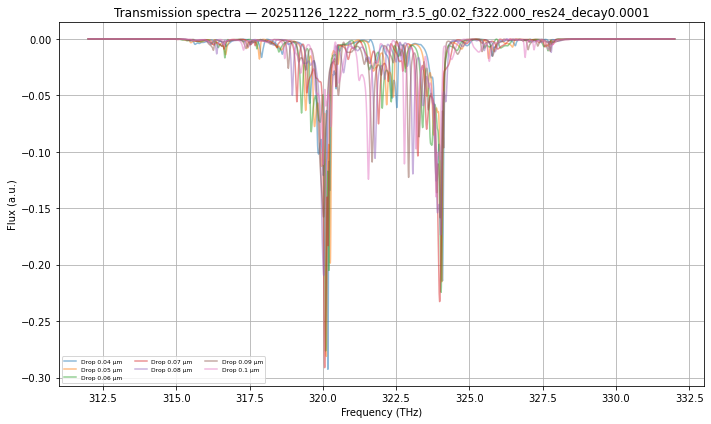

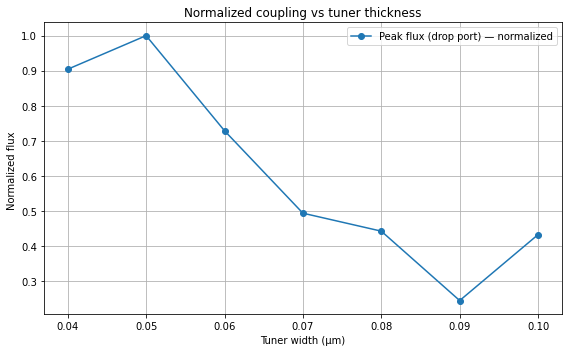

(array([0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ]),
 array([-0.10206457, -0.11288021, -0.08225544, -0.0557022 , -0.04991422,
        -0.02756472, -0.04880627]),
 array([-0.01789056, -0.02413716, -0.02938477, -0.03234811, -0.02827646,
        -0.0273832 , -0.02601627]))

In [ ]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt
import os


def load_tuner_sweep(base_folder, fmin, fmax):
    """
    Analyze and compare flux coupling for tuner sweep simulations.
    - Extracts peak flux values in given frequency range (THz)
    - Integrates tuner flux over the same range
    - Plots comparison of peak heights and integrated flux vs tuner thickness
    """

    if not os.path.exists(base_folder):
        raise FileNotFoundError(f"Folder '{base_folder}' not found.")

    subfolders = sorted([
        f for f in os.listdir(base_folder)
        if os.path.isdir(os.path.join(base_folder, f)) and f.startswith("tuner_")
    ])
    if not subfolders:
        raise RuntimeError(f"No tuner subfolders found in {base_folder}")

    print(f"Found {len(subfolders)} tuner simulations in {base_folder}")

    tuner_widths = []
    peak_heights = []
    integrated_flux = []

    plt.figure(figsize=(10, 6))
    for folder in subfolders:
        folder_path = os.path.join(base_folder, folder)
        try:
            freqs = np.load(os.path.join(folder_path, "freqs_thz.npy"))
            flux_drop = np.load(os.path.join(folder_path, "flux_drop.npy"))
            flux_tuner = np.load(os.path.join(folder_path, "flux_tuner.npy"))
        except FileNotFoundError:
            print(f" Missing data in {folder}, skipping...")
            continue

        # Extract tuner width (e.g. 'tuner_0.050um' -> 0.050)
        try:
            tuner_width = float(folder.split("_")[1].replace("um", ""))
        except Exception:
            tuner_width = np.nan

        # Limit to frequency window of interest
        mask = (freqs >= fmin) & (freqs <= fmax)
        freqs_win = freqs[mask]
        flux_tuner_win = flux_tuner[mask]
        flux_drop_win = flux_drop[mask]

        # Find peaks in drop-port spectrum (main resonance)
        peaks, _ = find_peaks(-flux_drop_win)
        if len(peaks) > 0:
            peak_idx = peaks[np.argmax(-flux_drop_win[peaks])]
            peak_val = flux_drop_win[peak_idx]
        else:
            peak_val = np.nan

        # Integrated flux into tuner (area under tuner curve)
        tuner_integral = np.trapz(flux_tuner_win, freqs_win)

        tuner_widths.append(tuner_width)
        peak_heights.append(peak_val)
        integrated_flux.append(tuner_integral)

        # Plot flux spectra for quick inspection
        #plt.plot(freqs, flux_tuner, '--', alpha=0.5, label=f"Tuner {tuner_width} µm")
        plt.plot(freqs, flux_drop, '-', alpha=0.5, label=f"Drop {tuner_width} µm")

    plt.xlabel("Frequency (THz)")
    plt.ylabel("Flux (a.u.)")
    plt.title(f"Transmission spectra — {os.path.basename(base_folder)}")
    plt.legend(fontsize=6, ncol=3)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Sort results by tuner thickness for clear plotting
    tuner_widths = np.array(tuner_widths)
    peak_heights = np.array(peak_heights)
    integrated_flux = np.array(integrated_flux)
    sort_idx = np.argsort(tuner_widths)
    tuner_widths = tuner_widths[sort_idx]
    peak_heights = peak_heights[sort_idx]
    integrated_flux = integrated_flux[sort_idx]

    # Normalize both series to [0,1] by dividing by max absolute value (ignoring NaNs)
    def _safe_normalize(arr):
        if np.all(np.isnan(arr)):
            return arr
        denom = np.nanmax(np.abs(arr))
        if denom == 0 or np.isnan(denom):
            return arr
        return arr / denom

    peak_norm = _safe_normalize(peak_heights)
    integrated_norm = _safe_normalize(integrated_flux)

    plt.figure(figsize=(8, 5))
    plt.plot(tuner_widths, np.abs(peak_norm), 'o-', label="Peak flux (drop port) — normalized")
    #plt.plot(tuner_widths, integrated_norm, 's-', label="Integrated flux (tuner) — normalized")
    plt.xlabel("Tuner width (µm)")
    plt.ylabel("Normalized flux ")
    plt.title("Normalized coupling vs tuner thickness")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return tuner_widths, peak_heights, integrated_flux


# Example usage
base_dir = "data"
base_folder = "20251126_1222_norm_r3.5_g0.02_f322.000_res24_decay0.0001_gt0.02"
run_dir = os.path.join(base_dir, base_folder)

load_tuner_sweep(run_dir, fmin=318, fmax=320)

Found 7 tuner simulations in data/20251126_1222_norm_r3.5_g0.02_f322.000_res24_decay0.0001_gt0.02


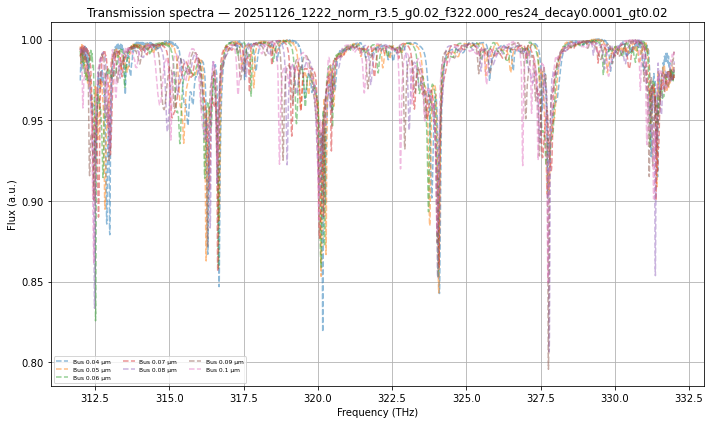

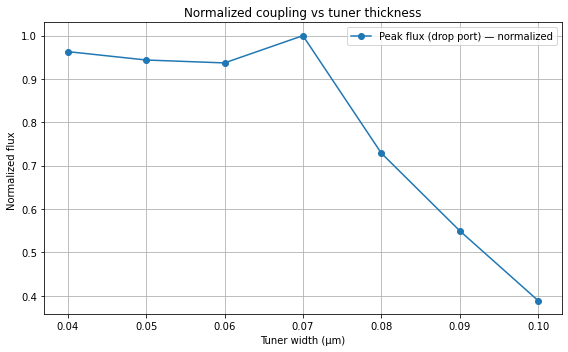

(array([0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ]),
 array([-0.03584747, -0.03512753, -0.03487679, -0.03721915, -0.02713254,
        -0.02046702, -0.01447103]),
 array([-0.00065442, -0.00082779, -0.0004881 , -0.00023441,  0.00017329,
         0.00022838,  0.0011276 ]))

In [83]:
def load_tuner_sweep(base_folder, fmin, fmax):
    """
    Analyze and compare flux coupling for tuner sweep simulations.
    - Extracts peak flux values in given frequency range (THz)
    - Integrates tuner flux over the same range
    - If norm_flux.npy and norm_freqs.npy exist in each subfolder, normalize fluxes before analysis.
    - Plots comparison of peak heights and integrated flux vs tuner thickness
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    from scipy.signal import find_peaks

    if not os.path.exists(base_folder):
        raise FileNotFoundError(f"Folder '{base_folder}' not found.")

    subfolders = sorted([
        f for f in os.listdir(base_folder)
        if os.path.isdir(os.path.join(base_folder, f)) and f.startswith("tuner_")
    ])
    if not subfolders:
        raise RuntimeError(f"No tuner subfolders found in {base_folder}")

    print(f"Found {len(subfolders)} tuner simulations in {base_folder}")

    tuner_widths = []
    peak_heights = []
    integrated_flux = []

    plt.figure(figsize=(10, 6))
    for folder in subfolders:
        folder_path = os.path.join(base_folder, folder)
        try:
            freqs = np.load(os.path.join(folder_path, "freqs_thz.npy"))
            flux_drop = np.load(os.path.join(folder_path, "flux_drop.npy"))
            flux_tuner = np.load(os.path.join(folder_path, "flux_tuner.npy"))
            flux_bus = np.load(os.path.join(folder_path, "flux_bus.npy"))
        except FileNotFoundError:
            print(f" Missing data in {folder}, skipping...")
            continue

        # Check for normalization files
        norm_flux_path = os.path.join(folder_path, "norm_flux.npy")
        norm_freqs_path = os.path.join(folder_path, "norm_freqs.npy")
        if os.path.exists(norm_flux_path) and os.path.exists(norm_freqs_path):
            norm_flux = np.load(norm_flux_path)
            norm_freqs = np.load(norm_freqs_path)
            # Interpolate normalization flux to match simulation frequencies
            norm_flux_interp = np.interp(freqs, norm_freqs, norm_flux)
            flux_drop = flux_drop / norm_flux_interp
            flux_tuner = flux_tuner / norm_flux_interp
            flux_bus = flux_bus / norm_flux_interp

        # Extract tuner width (e.g. 'tuner_0.050um' -> 0.050)
        try:
            tuner_width = float(folder.split("_")[1].replace("um", ""))
        except Exception:
            tuner_width = np.nan

        # Limit to frequency window of interest
        mask = (freqs >= fmin) & (freqs <= fmax)
        freqs_win = freqs[mask]
        flux_tuner_win = flux_tuner[mask]
        flux_drop_win = flux_drop[mask]
        flux_bus_win = flux_bus[mask]

        # Find peaks in drop-port spectrum (main resonance)
        peaks, _ = find_peaks(-flux_drop_win)
        if len(peaks) > 0:
            peak_idx = peaks[np.argmax(-flux_drop_win[peaks])]
            peak_val = flux_drop_win[peak_idx]
        else:
            peak_val = np.nan

        # Integrated flux into tuner (area under tuner curve)
        tuner_integral = np.trapz(flux_tuner_win, freqs_win)

        tuner_widths.append(tuner_width)
        peak_heights.append(peak_val)
        integrated_flux.append(tuner_integral)

        # Plot flux spectra for quick inspection
        #plt.plot(freqs, flux_drop, '-', alpha=0.5, label=f"Drop {tuner_width} µm")
        plt.plot(freqs, flux_bus, '--', alpha=0.5, label=f"Bus {tuner_width} µm")

    plt.xlabel("Frequency (THz)")
    plt.ylabel("Flux (a.u.)")
    plt.title(f"Transmission spectra — {os.path.basename(base_folder)}")
    plt.legend(fontsize=6, ncol=3)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Sort results by tuner thickness for clear plotting
    tuner_widths = np.array(tuner_widths)
    peak_heights = np.array(peak_heights)
    integrated_flux = np.array(integrated_flux)
    sort_idx = np.argsort(tuner_widths)
    tuner_widths = tuner_widths[sort_idx]
    peak_heights = peak_heights[sort_idx]
    integrated_flux = integrated_flux[sort_idx]

    # Normalize both series to [0,1] by dividing by max absolute value (ignoring NaNs)
    def _safe_normalize(arr):
        if np.all(np.isnan(arr)):
            return arr
        denom = np.nanmax(np.abs(arr))
        if denom == 0 or np.isnan(denom):
            return arr
        return arr / denom

    peak_norm = _safe_normalize(peak_heights)
    integrated_norm = _safe_normalize(integrated_flux)

    plt.figure(figsize=(8, 5))
    plt.plot(tuner_widths, np.abs(peak_norm), 'o-', label="Peak flux (drop port) — normalized")
    #plt.plot(tuner_widths, integrated_norm, 's-', label="Integrated flux (tuner) — normalized")
    plt.xlabel("Tuner width (µm)")
    plt.ylabel("Normalized flux ")
    plt.title("Normalized coupling vs tuner thickness")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return tuner_widths, peak_heights, integrated_flux


# Example usage
base_dir = "data"
base_folder = "20251126_1222_norm_r3.5_g0.02_f322.000_res24_decay0.0001_gt0.02"
run_dir = os.path.join(base_dir, base_folder)

load_tuner_sweep(run_dir, fmin=320, fmax=321)

Found 14 gap simulations in data/20251212_1708_norm_r3.5_g0.02_f318.000_res48_decay0.0005_tw0.08
Reference data normalized
Reference (ref_notuner) resonance: 314.714603 THz, Q=4812, R²=0.9868
tunergap_0.050um: gap=0.0500 µm | f_res=314.643435 ± 130.482 MHz, FWHM=61.787 ± 0.461 GHz, Q=5092 ± 38, R²=0.9907
tunergap_0.040um: gap=0.0400 µm | f_res=314.603325 ± 107.269 MHz, FWHM=56.569 ± 0.368 GHz, Q=5561 ± 36, R²=0.9924
tunergap_0.030um: gap=0.0300 µm | f_res=314.536672 ± 105.639 MHz, FWHM=62.894 ± 0.362 GHz, Q=5001 ± 29, R²=0.9932
tunergap_0.020um: gap=0.0200 µm | f_res=314.409480 ± 100.975 MHz, FWHM=52.157 ± 0.331 GHz, Q=6028 ± 38, R²=0.9912
tunergap_0.016um: gap=0.0160 µm | f_res=314.379851 ± 64.036 MHz, FWHM=53.549 ± 0.211 GHz, Q=5871 ± 23, R²=0.9966
tunergap_0.014um: gap=0.0140 µm | f_res=314.381943 ± 82.881 MHz, FWHM=57.024 ± 0.276 GHz, Q=5513 ± 27, R²=0.9949
tunergap_0.012um: gap=0.0120 µm | f_res=314.277371 ± 79.063 MHz, FWHM=64.875 ± 0.269 GHz, Q=4844 ± 20, R²=0.9962
tunergap_0.01

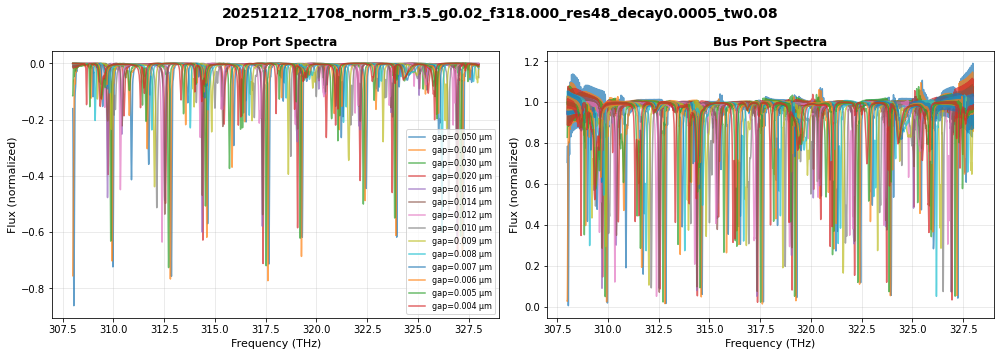

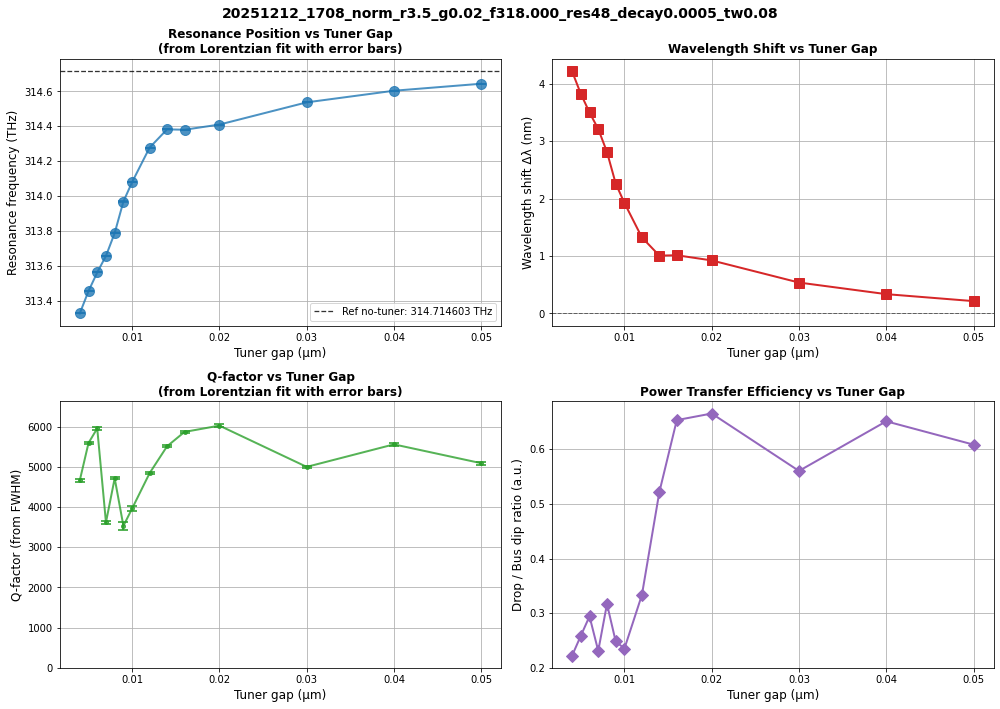


RESONANCE CHARACTERISTICS VS TUNER GAP (Lorentzian fit with uncertainties)
Gap (µm)     f_res (THz)          λ_shift (nm)   FWHM (GHz)         Q-factor           R²        
------------------------------------------------------------------------------------------------------------------------
0.0040       313.327231 ± 170.0 MHz +4.218         67.202 ± 0.583     4662 ± 40          0.9838    
0.0050       313.455417 ± 58.6 MHz +3.827         56.028 ± 0.194     5595 ± 19          0.9974    
0.0060       313.562220 ± 93.8 MHz +3.501         52.613 ± 0.308     5960 ± 35          0.9925    
0.0070       313.656787 ± 264.6 MHz +3.213         86.649 ± 0.966     3620 ± 40          0.9739    
0.0080       313.787953 ± 118.0 MHz +2.813         66.528 ± 0.404     4717 ± 29          0.9920    
0.0090       313.968533 ± 715.2 MHz +2.264         88.879 ± 2.630     3533 ± 105         0.8417    
0.0100       314.079975 ± 324.2 MHz +1.925         79.209 ± 1.156     3965 ± 58          0.9559    
0.0120 

In [41]:
def load_gap_sweep(base_folder, fmin, fmax):
    """
    Analyze resonance frequency shift vs tuner gap to disk.
    
    For a fixed tuner width, varies the gap between tuner and disk edge.
    Tracks how the resonance frequency shifts with tuner proximity.
    
    Metrics:
    - Resonance frequency from Lorentzian fit
    - Q-factor = f0 / FWHM from Lorentzian fit
    - Drop port coupling strength
    - Frequency shift relative to reference (no tuner)
    - Wavelength shift in nm
    
    Plots show correlation between gap and resonance position.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    from scipy.signal import find_peaks
    from scipy.optimize import curve_fit

    def lorentzian(f, f0, gamma, A, offset):
        """
        Lorentzian function for fitting resonance peaks.
        f0: center frequency
        gamma: half-width at half-maximum (HWHM)
        A: amplitude
        offset: baseline offset
        """
        return offset + A * (gamma**2) / ((f - f0)**2 + gamma**2)
    
    def fit_lorentzian_peak(freqs, flux, peak_idx, fit_window=0.3):
        """
        Fit a Lorentzian to a resonance peak.
        
        Returns dict with f0, fwhm, Q, fit_quality, fitted_curve
        """
        f_peak = freqs[peak_idx]
        flux_peak = flux[peak_idx]
        
        # Select data around peak for fitting
        mask = np.abs(freqs - f_peak) < fit_window
        f_fit = freqs[mask]
        flux_fit = flux[mask]
        
        if len(f_fit) < 5:
            return None
        
        # Initial guess
        f0_guess = f_peak
        gamma_guess = 0.01  # THz
        A_guess = flux_peak - np.min(flux_fit)
        offset_guess = np.min(flux_fit)
        
        p0 = [f0_guess, gamma_guess, A_guess, offset_guess]
        
        try:
            # Fit Lorentzian
            popt, pcov = curve_fit(lorentzian, f_fit, flux_fit, p0=p0, maxfev=5000)
            f0_fit, gamma_fit, A_fit, offset_fit = popt
            
            # Calculate FWHM and Q-factor
            fwhm = 2 * abs(gamma_fit)  # FWHM = 2 * HWHM
            Q = abs(f0_fit / fwhm) if fwhm > 0 else np.nan
            
            # Calculate R-squared for fit quality
            flux_fitted = lorentzian(f_fit, *popt)
            ss_res = np.sum((flux_fit - flux_fitted)**2)
            ss_tot = np.sum((flux_fit - np.mean(flux_fit))**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            # Calculate parameter uncertainties from covariance matrix
            perr = np.sqrt(np.diag(pcov))
            f0_err = perr[0]
            gamma_err = perr[1]
            
            # Propagate errors to derived quantities
            # FWHM = 2*gamma → σ_FWHM = 2*σ_gamma
            fwhm_err = 2 * gamma_err
            
            # Q = f0/FWHM → σ_Q = Q * sqrt((σ_f0/f0)² + (σ_FWHM/FWHM)²)
            if fwhm > 0 and f0_fit > 0:
                q_err = Q * np.sqrt((f0_err/f0_fit)**2 + (fwhm_err/fwhm)**2)
            else:
                q_err = np.nan
            
            # Generate full fitted curve for plotting
            fitted_curve = lorentzian(freqs, *popt)
            
            return {
                'f0': f0_fit,
                'f0_err': f0_err,
                'fwhm': fwhm,
                'fwhm_err': fwhm_err,
                'Q': Q,
                'Q_err': q_err,
                'gamma': gamma_fit,
                'amplitude': A_fit,
                'offset': offset_fit,
                'r_squared': r_squared,
                'fitted_curve': fitted_curve,
                'fit_params': popt,
                'fit_errors': perr
            }
        except Exception as e:
            print(f"  Warning: Lorentzian fit failed - {e}")
            return None

    if not os.path.exists(base_folder):
        raise FileNotFoundError(f"Folder '{base_folder}' not found.")

    # Look for gap sweep folders (e.g., "tunergap_0.010um", "tunergap_0.020um")
    subfolders = sorted([
        f for f in os.listdir(base_folder)
        if os.path.isdir(os.path.join(base_folder, f)) and f.startswith("tunergap_")
    ], reverse=True)  # Reverse order - start with largest gap first
    if not subfolders:
        raise RuntimeError(f"No gap subfolders found in {base_folder}")

    print(f"Found {len(subfolders)} gap simulations in {base_folder}")

    # Load reference simulation (no tuner)
    ref_folder = os.path.join(base_folder, "ref_notuner")
    ref0_freq = None

    if os.path.exists(ref_folder):
        try:
            ref_freqs = np.load(os.path.join(ref_folder, "freqs_thz.npy"))
            ref_drop = np.load(os.path.join(ref_folder, "flux_drop.npy"))

            # Check for normalization files in reference folder
            ref_norm_flux_path = os.path.join(ref_folder, "norm_flux.npy")
            ref_norm_freqs_path = os.path.join(ref_folder, "norm_freqs.npy")
            if os.path.exists(ref_norm_flux_path) and os.path.exists(ref_norm_freqs_path):
                ref_norm_flux = np.load(ref_norm_flux_path)
                ref_norm_freqs_meep = np.load(ref_norm_freqs_path)
                # Convert normalization frequencies from Meep units to THz
                C0_UM_PER_FS = 299.792458
                ref_norm_freqs = ref_norm_freqs_meep * C0_UM_PER_FS
                # Interpolate and normalize
                ref_norm_flux_interp = np.interp(ref_freqs, ref_norm_freqs, ref_norm_flux)
                ref_drop = ref_drop / ref_norm_flux_interp
                print("Reference data normalized")

            # Find strongest resonance peak in reference
            mask_ref = (ref_freqs >= fmin) & (ref_freqs <= fmax)
            ref_freqs_win = ref_freqs[mask_ref]
            ref_drop_win = ref_drop[mask_ref]

            pk, _ = find_peaks(np.abs(ref_drop_win), prominence=0.01)

            if len(pk) > 0:
                pk_idx = pk[np.argmax(np.abs(ref_drop_win[pk]))]
                # Fit reference peak with Lorentzian
                fit_ref = fit_lorentzian_peak(ref_freqs_win, np.abs(ref_drop_win), 
                                               pk_idx, fit_window=0.3)
                if fit_ref is not None:
                    ref0_freq = fit_ref['f0']
                    print(f"Reference (ref_notuner) resonance: {ref0_freq:.6f} THz, "
                          f"Q={fit_ref['Q']:.0f}, R²={fit_ref['r_squared']:.4f}")
                else:
                    ref0_freq = ref_freqs_win[pk_idx]
                    print(f"Reference (ref_notuner) resonance: {ref0_freq:.6f} THz (fit failed)")
            else:
                print("Reference sim found but no resonance detected.")
        except Exception as e:
            print(f"Reference simulation error: {e}")
    else:
        print("Reference simulation 'ref_notuner' not found.")

    # Storage for results
    gaps = []
    res_frequencies = []
    res_freq_errors = []
    peak_heights = []
    fwhm_values = []
    fwhm_errors = []
    q_factors = []
    q_errors = []
    coupling_ratios = []
    fit_quality = []
    fit_curves = []
    
    # Track last known resonance frequency for continuous tracking
    last_known_freq = ref0_freq  # Start with reference if available

    # Plot 1: Transmission spectra overlay
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig1.suptitle(f"{os.path.basename(base_folder)}", fontsize=14, fontweight='bold')

    for folder in subfolders:
        folder_path = os.path.join(base_folder, folder)
        try:
            freqs = np.load(os.path.join(folder_path, "freqs_thz.npy"))
            flux_drop = np.load(os.path.join(folder_path, "flux_drop.npy"))
            flux_bus = np.load(os.path.join(folder_path, "flux_bus.npy"))
        except FileNotFoundError:
            print(f" Missing data in {folder}, skipping...")
            continue

        # Check for normalization files
        norm_flux_path = os.path.join(folder_path, "norm_flux.npy")
        norm_freqs_path = os.path.join(folder_path, "norm_freqs.npy")
        if os.path.exists(norm_flux_path) and os.path.exists(norm_freqs_path):
            norm_flux = np.load(norm_flux_path)
            norm_freqs = np.load(norm_freqs_path)
            norm_flux_interp = np.interp(freqs, norm_freqs, norm_flux)
            flux_drop = flux_drop / norm_flux_interp
            flux_bus = flux_bus / norm_flux_interp

        # Extract gap value (e.g., 'tunergap_0.010um' -> 0.010)
        try:
            gap = float(folder.split("_")[1].replace("um", ""))
        except Exception:
            gap = np.nan

        # Limit to frequency window
        mask = (freqs >= fmin) & (freqs <= fmax)
        freqs_win = freqs[mask]
        flux_drop_win = flux_drop[mask]
        flux_bus_win = flux_bus[mask]

        # Find resonance peak in drop port (negative dip = peak in abs)
        peaks, properties = find_peaks(np.abs(flux_drop_win), 
                                       prominence=0.01, 
                                       width=1)
        
        # Bus-port dip (should be a minimum)
        bus_dips, bus_props = find_peaks(-np.abs(flux_bus_win), prominence=0.001, width=1)

        if len(bus_dips) > 0:
            bus_idx = bus_dips[np.argmin(np.abs(flux_bus_win[bus_dips]))]
            bus_dip_height = 1 - np.abs(flux_bus_win[bus_idx])
        else:
            bus_dip_height = np.nan
        
        if len(peaks) > 0:
            # Pick resonance closest to last known frequency (or strongest if no tracking yet)
            # Only consider peaks at lower frequencies than last known
            if last_known_freq is not None:
                # Find peaks with lower frequency than last known
                peak_freqs = freqs_win[peaks]
                lower_freq_mask = peak_freqs < last_known_freq
                
                if np.any(lower_freq_mask):
                    # Filter to only lower frequency peaks
                    valid_peaks = peaks[lower_freq_mask]
                    valid_peak_freqs = peak_freqs[lower_freq_mask]
                    # Find peak closest to last known frequency among lower frequencies
                    closest_idx = np.argmin(np.abs(valid_peak_freqs - last_known_freq))
                    peak_idx = valid_peaks[closest_idx]
                else:
                    # No lower frequency peaks found - fall back to closest peak overall
                    print(f"  Warning: No peaks found below {last_known_freq:.6f} THz, using closest peak")
                    closest_idx = np.argmin(np.abs(peak_freqs - last_known_freq))
                    peak_idx = peaks[closest_idx]
            else:
                # No tracking frequency yet - pick strongest resonance
                peak_idx = peaks[np.argmax(np.abs(flux_drop_win[peaks]))]
            peak_height = np.abs(flux_drop_win[peak_idx])
            
            # Fit Lorentzian to extract accurate f0, FWHM, and Q
            fit_result = fit_lorentzian_peak(freqs_win, np.abs(flux_drop_win), 
                                            peak_idx, fit_window=0.3)
            
            if fit_result is not None:
                res_freq = fit_result['f0']
                res_freq_err = fit_result['f0_err']
                fwhm = fit_result['fwhm']
                fwhm_err = fit_result['fwhm_err']
                q_factor = fit_result['Q']
                q_err = fit_result['Q_err']
                r_sq = fit_result['r_squared']
                fitted = fit_result['fitted_curve']
                
                # Update tracking frequency for next iteration
                last_known_freq = res_freq
                
                # Coupling ratio: how much of bus dip appears in drop
                coupling_ratio = peak_height / bus_dip_height if bus_dip_height > 0 else np.nan
                
                # Store results
                gaps.append(gap)
                res_frequencies.append(res_freq)
                res_freq_errors.append(res_freq_err)
                peak_heights.append(peak_height)
                fwhm_values.append(fwhm)
                fwhm_errors.append(fwhm_err)
                q_factors.append(q_factor)
                q_errors.append(q_err)
                coupling_ratios.append(coupling_ratio)
                fit_quality.append(r_sq)
                fit_curves.append(fitted)
                
                print(f"{folder}: gap={gap:.4f} µm | "
                      f"f_res={res_freq:.6f} ± {res_freq_err*1e6:.3f} MHz, "
                      f"FWHM={fwhm*1000:.3f} ± {fwhm_err*1000:.3f} GHz, "
                      f"Q={q_factor:.0f} ± {q_err:.0f}, R²={r_sq:.4f}")
            else:
                print(f"{folder}: gap={gap:.4f} µm | Peak found but fit failed")
                gaps.append(gap)
                res_frequencies.append(np.nan)
                res_freq_errors.append(np.nan)
                peak_heights.append(peak_height)
                fwhm_values.append(np.nan)
                fwhm_errors.append(np.nan)
                q_factors.append(np.nan)
                q_errors.append(np.nan)
                coupling_ratios.append(np.nan)
                fit_quality.append(np.nan)
                fit_curves.append(None)
        else:
            print(f"{folder}: No resonance found in range [{fmin}, {fmax}] THz")
            gaps.append(gap)
            res_frequencies.append(np.nan)
            res_freq_errors.append(np.nan)
            peak_heights.append(np.nan)
            fwhm_values.append(np.nan)
            fwhm_errors.append(np.nan)
            q_factors.append(np.nan)
            q_errors.append(np.nan)
            coupling_ratios.append(np.nan)
            fit_quality.append(np.nan)
            fit_curves.append(None)

        # Plot spectra
        ax1.plot(freqs, flux_drop, '-', alpha=0.7, linewidth=1.5, 
                label=f"gap={gap:.3f} µm")
        ax2.plot(freqs, flux_bus, '-', alpha=0.7, linewidth=1.5,
                label=f"gap={gap:.3f} µm")

    # Format spectra plots
    ax1.set_xlabel("Frequency (THz)", fontsize=11)
    ax1.set_ylabel("Flux (normalized)", fontsize=11)
    ax1.set_title("Drop Port Spectra", fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=8, ncol=1, loc='best')
    
    ax2.set_xlabel("Frequency (THz)", fontsize=11)
    ax2.set_ylabel("Flux (normalized)", fontsize=11)
    ax2.set_title("Bus Port Spectra", fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # Convert to arrays and sort by gap
    gaps = np.array(gaps)
    res_frequencies = np.array(res_frequencies)
    res_freq_errors = np.array(res_freq_errors)
    peak_heights = np.array(peak_heights)
    fwhm_values = np.array(fwhm_values)
    fwhm_errors = np.array(fwhm_errors)
    q_factors = np.array(q_factors)
    q_errors = np.array(q_errors)
    coupling_ratios = np.array(coupling_ratios)
    fit_quality = np.array(fit_quality)
    
    sort_idx = np.argsort(gaps)
    gaps = gaps[sort_idx]
    res_frequencies = res_frequencies[sort_idx]
    res_freq_errors = res_freq_errors[sort_idx]
    peak_heights = peak_heights[sort_idx]
    fwhm_values = fwhm_values[sort_idx]
    fwhm_errors = fwhm_errors[sort_idx]
    q_factors = q_factors[sort_idx]
    q_errors = q_errors[sort_idx]
    coupling_ratios = coupling_ratios[sort_idx]
    fit_quality = fit_quality[sort_idx]
    fit_curves_sorted = [fit_curves[i] for i in sort_idx]

    # Wavelength shift Δλ (nm)
    c_nm_thz = 299792.458  # speed of light for λ[nm] = c/f[THz]

    valid_mask = ~np.isnan(res_frequencies)

    if np.any(valid_mask):
        wavelength_ref = c_nm_thz / ref0_freq if ref0_freq is not None else c_nm_thz / res_frequencies[valid_mask][-1]
        wavelengths_nm = c_nm_thz / res_frequencies[valid_mask]
        lambda_shift_nm = wavelengths_nm - wavelength_ref
    else:
        wavelengths_nm = np.full_like(res_frequencies, np.nan)
        lambda_shift_nm = np.full_like(res_frequencies, np.nan)

    # Create full lambda_shift_nm array (including NaN positions)
    lambda_shift_nm_full = np.full_like(res_frequencies, np.nan)
    lambda_shift_nm_full[valid_mask] = lambda_shift_nm

    # Plot 2: Resonance characteristics vs gap
    fig2, ((ax3, ax4), (ax5, ax6)) = plt.subplots(2, 2, figsize=(14, 10))
    fig2.suptitle(f"{os.path.basename(base_folder)}", fontsize=14, fontweight='bold')
    
    # Resonance frequency vs gap
    valid_freq = ~np.isnan(res_frequencies)
    ax3.errorbar(gaps[valid_freq], res_frequencies[valid_freq], 
                 yerr=res_freq_errors[valid_freq],
                 fmt='o-', linewidth=2, markersize=10, capsize=5, capthick=2,
                 color='tab:blue', ecolor='tab:blue', alpha=0.8)
    
    if ref0_freq is not None:
        ax3.axhline(ref0_freq, color='black', linestyle='--', linewidth=1.3, alpha=0.8,
                    label=f"Ref no-tuner: {ref0_freq:.6f} THz")
        ax3.legend()

    ax3.set_xlabel("Tuner gap (µm)", fontsize=12)
    ax3.set_ylabel("Resonance frequency (THz)", fontsize=12)
    ax3.set_title("Resonance Position vs Tuner Gap\n(from Lorentzian fit with error bars)", 
                  fontsize=12, fontweight='bold')
    ax3.grid(True)
    
    # Wavelength shift Δλ (nm)
    ax4.plot(gaps[valid_mask], lambda_shift_nm, 's-', linewidth=2, markersize=10,
            color='tab:red')
    ax4.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax4.set_xlabel("Tuner gap (µm)", fontsize=12)
    ax4.set_ylabel("Wavelength shift Δλ (nm)", fontsize=12)
    ax4.set_title("Wavelength Shift vs Tuner Gap", fontsize=12, fontweight='bold')
    ax4.grid(True)
    
    # Q-factor vs gap
    valid_q = ~np.isnan(q_factors)
    ax5.errorbar(gaps[valid_q], q_factors[valid_q], 
                 yerr=q_errors[valid_q],
                 fmt='.-', linewidth=2, markersize=8, capsize=5, capthick=2,
                 color='tab:green', ecolor='tab:green', alpha=0.8)
    ax5.set_xlabel("Tuner gap (µm)", fontsize=12)
    ax5.set_ylabel("Q-factor (from FWHM)", fontsize=12)
    ax5.set_title("Q-factor vs Tuner Gap\n(from Lorentzian fit with error bars)", fontsize=12, fontweight='bold')
    ax5.grid(True)
    if np.any(valid_q):
        ax5.set_ylim([0, np.nanmax(q_factors[valid_q]) * 1.1])
    
    # Coupling efficiency
    valid_coupling = ~np.isnan(coupling_ratios)
    ax6.plot(gaps[valid_coupling], coupling_ratios[valid_coupling], 'D-', 
            linewidth=2, markersize=8, color='tab:purple')
    ax6.set_xlabel("Tuner gap (µm)", fontsize=12)
    ax6.set_ylabel("Drop / Bus dip ratio (a.u.)", fontsize=12)
    ax6.set_title("Power Transfer Efficiency vs Tuner Gap", fontsize=12, fontweight='bold')
    ax6.grid(True)
    
    plt.tight_layout()
    plt.show()

        # Print summary table and save to file
    print("\n" + "="*120)
    print("RESONANCE CHARACTERISTICS VS TUNER GAP (Lorentzian fit with uncertainties)")
    print("="*120)
    print(f"{'Gap (µm)':<12} {'f_res (THz)':<20} {'λ_shift (nm)':<14} "
          f"{'FWHM (GHz)':<18} {'Q-factor':<18} {'R²':<10}")
    print("-"*120)
    
    # Open output file - save as CSV for easy reading
    output_file = os.path.join(base_folder, "gap_sweep_summary.csv")
    with open(output_file, 'w') as f:
        # Write CSV header
        f.write("gap_um,f_res_THz,f_res_err_THz,lambda_shift_nm,fwhm_GHz,fwhm_err_GHz,Q_factor,Q_err,R_squared\n")
        
        for i in range(len(gaps)):
            # Print to console (formatted for humans)
            freq_str = f"{res_frequencies[i]:.6f} ± {res_freq_errors[i]*1e6:.1f} MHz" if not np.isnan(res_frequencies[i]) else "N/A"
            q_str = f"{q_factors[i]:.0f} ± {q_errors[i]:.0f}" if not np.isnan(q_factors[i]) else "N/A"
            shift_str = f"{lambda_shift_nm_full[i]:+.3f}" if not np.isnan(lambda_shift_nm_full[i]) else "N/A"
            fwhm_str = f"{fwhm_values[i]*1000:.3f} ± {fwhm_errors[i]*1000:.3f}" if not np.isnan(fwhm_values[i]) else "N/A"
            r2_str = f"{fit_quality[i]:.4f}" if not np.isnan(fit_quality[i]) else "N/A"
            
            line = f"{gaps[i]:<12.4f} {freq_str:<20} {shift_str:<14} {fwhm_str:<18} {q_str:<18} {r2_str:<10}"
            print(line)
            
            # Write to CSV file (raw numbers for easy reading)
            f.write(f"{gaps[i]:.6f},{res_frequencies[i]:.12f},{res_freq_errors[i]:.12f},"
                   f"{lambda_shift_nm_full[i]:.6f},{fwhm_values[i]*1000:.6f},{fwhm_errors[i]*1000:.6f},"
                   f"{q_factors[i]:.2f},{q_errors[i]:.2f},{fit_quality[i]:.6f}\n")
        
        # Write summary statistics as comments
        f.write("\n# SUMMARY STATISTICS\n")
        if np.any(valid_mask) and len(res_frequencies[valid_mask]) > 1:
            total_shift_freq = (res_frequencies[valid_mask][-1] - 
                               res_frequencies[valid_mask][0]) * 1000  # GHz
            total_shift_wl = lambda_shift_nm[-1] - lambda_shift_nm[0]  # nm
            gap_range = gaps[valid_mask][-1] - gaps[valid_mask][0]
            tuning_rate_freq = total_shift_freq / gap_range if gap_range > 0 else 0
            tuning_rate_wl = total_shift_wl / gap_range if gap_range > 0 else 0
            
            f.write(f"# Total frequency shift: {abs(total_shift_freq):.6f} GHz\n")
            f.write(f"# Total wavelength shift: {abs(total_shift_wl):.6f} nm\n")
            f.write(f"# Gap range: {gap_range:.6f} um\n")
            f.write(f"# Tuning sensitivity (freq): {abs(tuning_rate_freq):.6f} GHz/um\n")
            f.write(f"# Tuning sensitivity (wavelength): {abs(tuning_rate_wl):.6f} nm/um\n")
            
            if np.any(valid_q):
                q_mean = np.nanmean(q_factors[valid_q])
                q_std = np.nanstd(q_factors[valid_q])
                q_err_mean = np.nanmean(q_errors[valid_q])
                f.write(f"# Average Q-factor: {q_mean:.2f}\n")
                f.write(f"# Q-factor std dev: {q_std:.2f}\n")
                f.write(f"# Average fit uncertainty: {q_err_mean:.2f}\n")
    
    print(f"\nSummary data saved to: {output_file}")
    
    print("\n" + "="*120)
    print("SUMMARY:")
    if np.any(valid_mask) and len(res_frequencies[valid_mask]) > 1:
        total_shift_freq = (res_frequencies[valid_mask][-1] - 
                           res_frequencies[valid_mask][0]) * 1000  # GHz
        total_shift_wl = lambda_shift_nm[-1] - lambda_shift_nm[0]  # nm
        gap_range = gaps[valid_mask][-1] - gaps[valid_mask][0]
        tuning_rate_freq = total_shift_freq / gap_range if gap_range > 0 else 0
        tuning_rate_wl = total_shift_wl / gap_range if gap_range > 0 else 0
        
        print(f"  Total frequency shift: {abs(total_shift_freq):.2f} GHz")
        print(f"  Total wavelength shift: {abs(total_shift_wl):.3f} nm")
        print(f"  Gap range: {gap_range:.4f} µm")
        print(f"  Tuning sensitivity: {abs(tuning_rate_freq):.1f} GHz/µm ({abs(tuning_rate_wl):.2f} nm/µm)")
        
        if np.any(valid_q):
            q_mean = np.nanmean(q_factors[valid_q])
            q_std = np.nanstd(q_factors[valid_q])
            q_err_mean = np.nanmean(q_errors[valid_q])
            print(f"  Average Q-factor: {q_mean:.0f} ± {q_std:.0f} (std dev)")
            print(f"  Average fit uncertainty: ±{q_err_mean:.0f}")
    print("="*120)

    return {
        'gaps': gaps,
        'res_frequencies': res_frequencies,
        'res_freq_errors': res_freq_errors,
        'lambda_shift_nm': lambda_shift_nm_full,
        'fwhm_thz': fwhm_values,
        'fwhm_errors': fwhm_errors,
        'q_factors': q_factors,
        'q_errors': q_errors,
        'coupling_ratios': coupling_ratios,
        'fit_quality': fit_quality,
        'peak_heights': peak_heights,
        'fit_curves': fit_curves_sorted
    }


# Example usage
if __name__ == "__main__":
    import os
    base_dir = "data"
    #base_folder = "20251202_1404_norm_r3.5_g0.02_f322.000_res48_decay0.0005_tw0.09"
    base_folder = "20251212_1708_norm_r3.5_g0.02_f318.000_res48_decay0.0005_tw0.08" 
    run_dir = os.path.join(base_dir, base_folder)
    
    # Search for resonances in specified range
    results = load_gap_sweep(run_dir, fmin=312.98, fmax=314.8)
    
    # Access results
    print(f"\nGaps tested: {results['gaps']}")
    print(f"Resonance frequencies: {results['res_frequencies']}")
    print(f"Wavelength shifts: {results['lambda_shift_nm']} nm")
    print(f"Q-factors: {results['q_factors']}")

# comparison to disk flux analysis

Found 14 gap simulations in data/20251212_1708_norm_r3.5_g0.02_f318.000_res48_decay0.0005_tw0.08
Reference simulation error: [Errno 2] No such file or directory: 'data/20251212_1708_norm_r3.5_g0.02_f318.000_res48_decay0.0005_tw0.08/ref_notuner/flux_disk.npy'
tunergap_0.050um: gap=0.0500 µm | f_res=314.643508 ± 113.969 MHz, FWHM=62.189 ± 0.403 GHz, Q=5059 ± 33, Intensity=50.6858, R²=0.9930
tunergap_0.040um: gap=0.0400 µm | f_res=314.603652 ± 93.146 MHz, FWHM=56.895 ± 0.320 GHz, Q=5530 ± 31, Intensity=55.7684, R²=0.9943
tunergap_0.030um: gap=0.0300 µm | f_res=314.537140 ± 94.792 MHz, FWHM=65.641 ± 0.328 GHz, Q=4792 ± 24, Intensity=41.0663, R²=0.9949
tunergap_0.020um: gap=0.0200 µm | f_res=314.410177 ± 99.846 MHz, FWHM=51.837 ± 0.327 GHz, Q=6065 ± 38, Intensity=56.7372, R²=0.9913
tunergap_0.016um: gap=0.0160 µm | f_res=314.380825 ± 62.167 MHz, FWHM=53.448 ± 0.205 GHz, Q=5882 ± 23, Intensity=46.7118, R²=0.9968
tunergap_0.014um: gap=0.0140 µm | f_res=314.382978 ± 83.135 MHz, FWHM=57.880 ± 0

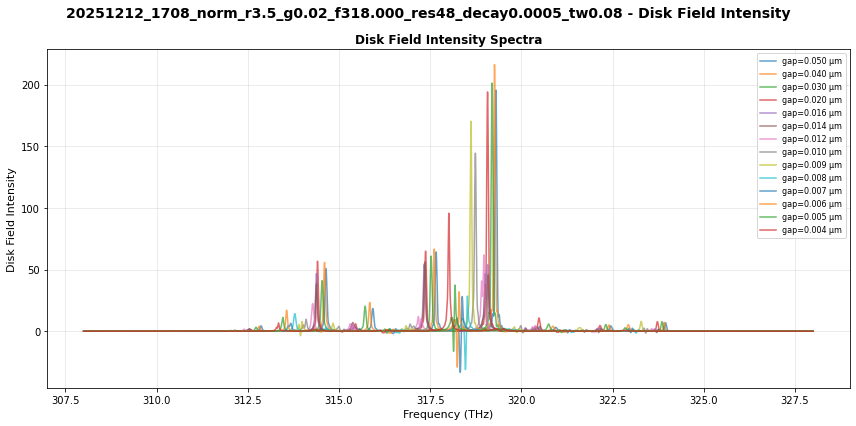

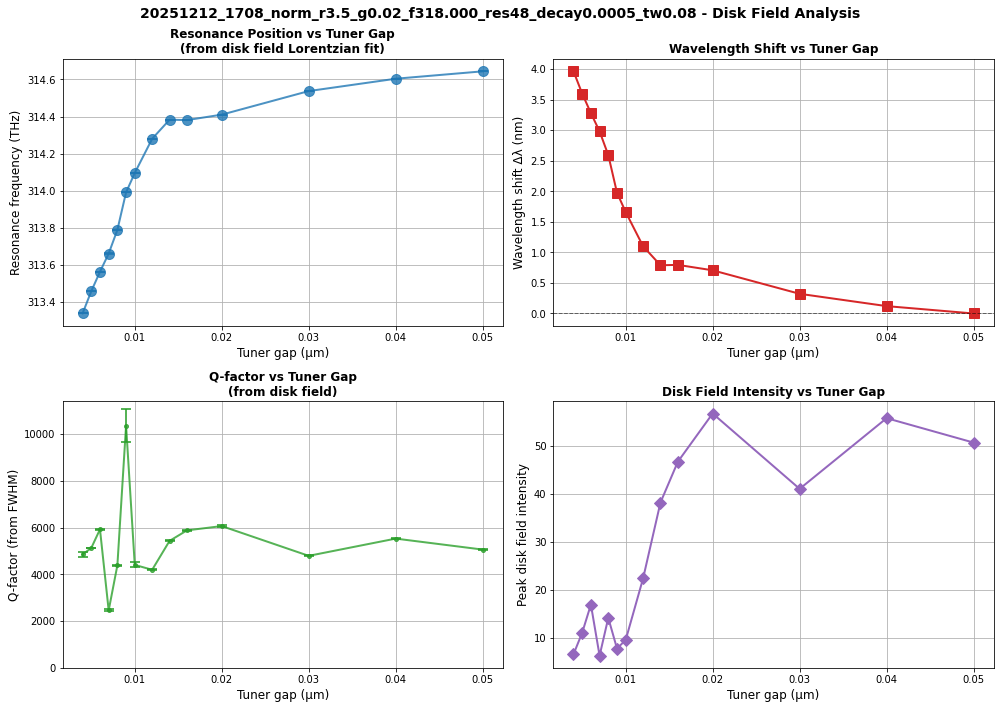


DISK FIELD RESONANCE CHARACTERISTICS VS TUNER GAP
Gap (µm)     f_res (THz)          λ_shift (nm)   FWHM (GHz)         Q-factor           Intensity    R²        
------------------------------------------------------------------------------------------------------------------------
0.0040       313.339345 ± 348.0 MHz +3.966         64.586 ± 1.185     4851 ± 89          6.6584       0.9314    
0.0050       313.458861 ± 50.8 MHz +3.601         61.129 ± 0.171     5128 ± 14          11.1402      0.9983    
0.0060       313.563835 ± 85.4 MHz +3.281         52.917 ± 0.281     5926 ± 31          17.0006      0.9938    
0.0070       313.661733 ± 582.8 MHz +2.982         127.681 ± 2.443    2457 ± 47          6.3669       0.9299    
0.0080       313.789329 ± 74.7 MHz +2.594         71.565 ± 0.260     4385 ± 16          14.2318      0.9971    
0.0090       313.991488 ± 674.3 MHz +1.979         30.293 ± 2.072     10365 ± 709        7.8611       0.4898    
0.0100       314.095862 ± 515.8 MHz +1.661

In [107]:
def load_gap_sweep_disk_field(base_folder, fmin, fmax):
    """
    Analyze resonance frequency shift vs tuner gap using disk field intensity.
    
    Similar to load_gap_sweep() but uses flux_disk.npy instead of flux_drop.
    This measures the field intensity directly in the disk resonator.
    
    Metrics:
    - Resonance frequency from Lorentzian fit (on disk field peaks)
    - Q-factor = f0 / FWHM from Lorentzian fit
    - Peak field intensity in disk
    - Frequency shift relative to reference (no tuner)
    - Wavelength shift in nm
    
    Plots show correlation between gap and resonance position.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    from scipy.signal import find_peaks
    from scipy.optimize import curve_fit

    def lorentzian(f, f0, gamma, A, offset):
        """
        Lorentzian function for fitting resonance peaks.
        f0: center frequency
        gamma: half-width at half-maximum (HWHM)
        A: amplitude
        offset: baseline offset
        """
        return offset + A * (gamma**2) / ((f - f0)**2 + gamma**2)
    
    def fit_lorentzian_peak(freqs, flux, peak_idx, fit_window=0.3):
        """
        Fit a Lorentzian to a resonance peak.
        
        Returns dict with f0, fwhm, Q, fit_quality, fitted_curve
        """
        f_peak = freqs[peak_idx]
        flux_peak = flux[peak_idx]
        
        # Select data around peak for fitting
        mask = np.abs(freqs - f_peak) < fit_window
        f_fit = freqs[mask]
        flux_fit = flux[mask]
        
        if len(f_fit) < 5:
            return None
        
        # Initial guess
        f0_guess = f_peak
        gamma_guess = 0.01  # THz
        A_guess = flux_peak - np.min(flux_fit)
        offset_guess = np.min(flux_fit)
        
        p0 = [f0_guess, gamma_guess, A_guess, offset_guess]
        
        try:
            # Fit Lorentzian
            popt, pcov = curve_fit(lorentzian, f_fit, flux_fit, p0=p0, maxfev=5000)
            f0_fit, gamma_fit, A_fit, offset_fit = popt
            
            # Calculate FWHM and Q-factor
            fwhm = 2 * abs(gamma_fit)  # FWHM = 2 * HWHM
            Q = abs(f0_fit / fwhm) if fwhm > 0 else np.nan
            
            # Calculate R-squared for fit quality
            flux_fitted = lorentzian(f_fit, *popt)
            ss_res = np.sum((flux_fit - flux_fitted)**2)
            ss_tot = np.sum((flux_fit - np.mean(flux_fit))**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            # Calculate parameter uncertainties from covariance matrix
            perr = np.sqrt(np.diag(pcov))
            f0_err = perr[0]
            gamma_err = perr[1]
            
            # Propagate errors to derived quantities
            fwhm_err = 2 * gamma_err
            
            if fwhm > 0 and f0_fit > 0:
                q_err = Q * np.sqrt((f0_err/f0_fit)**2 + (fwhm_err/fwhm)**2)
            else:
                q_err = np.nan
            
            # Generate full fitted curve for plotting
            fitted_curve = lorentzian(freqs, *popt)
            
            return {
                'f0': f0_fit,
                'f0_err': f0_err,
                'fwhm': fwhm,
                'fwhm_err': fwhm_err,
                'Q': Q,
                'Q_err': q_err,
                'gamma': gamma_fit,
                'amplitude': A_fit,
                'offset': offset_fit,
                'r_squared': r_squared,
                'fitted_curve': fitted_curve,
                'fit_params': popt,
                'fit_errors': perr
            }
        except Exception as e:
            print(f"  Warning: Lorentzian fit failed - {e}")
            return None

    if not os.path.exists(base_folder):
        raise FileNotFoundError(f"Folder '{base_folder}' not found.")

    # Look for gap sweep folders (e.g., "tunergap_0.010um", "tunergap_0.020um")
    subfolders = sorted([
        f for f in os.listdir(base_folder)
        if os.path.isdir(os.path.join(base_folder, f)) and f.startswith("tunergap_")
    ], reverse=True)  # Reverse order - start with largest gap first
    
    if not subfolders:
        raise RuntimeError(f"No gap subfolders found in {base_folder}")

    print(f"Found {len(subfolders)} gap simulations in {base_folder}")

    # Load reference simulation (no tuner)
    ref_folder = os.path.join(base_folder, "ref_notuner")
    ref0_freq = None

    if os.path.exists(ref_folder):
        try:
            ref_freqs = np.load(os.path.join(ref_folder, "freqs_thz.npy"))
            ref_disk = np.load(os.path.join(ref_folder, "flux_disk.npy"))

            # Find strongest resonance peak in reference
            mask_ref = (ref_freqs >= fmin) & (ref_freqs <= fmax)
            ref_freqs_win = ref_freqs[mask_ref]
            ref_disk_win = ref_disk[mask_ref]

            pk, _ = find_peaks(ref_disk_win, prominence=0.01)

            if len(pk) > 0:
                pk_idx = pk[np.argmax(ref_disk_win[pk])]
                # Fit reference peak with Lorentzian
                fit_ref = fit_lorentzian_peak(ref_freqs_win, ref_disk_win, 
                                               pk_idx, fit_window=0.3)
                if fit_ref is not None:
                    ref0_freq = fit_ref['f0']
                    print(f"Reference (ref_notuner) resonance: {ref0_freq:.6f} THz, "
                          f"Q={fit_ref['Q']:.0f}, R²={fit_ref['r_squared']:.4f}")
                else:
                    ref0_freq = ref_freqs_win[pk_idx]
                    print(f"Reference (ref_notuner) resonance: {ref0_freq:.6f} THz (fit failed)")
            else:
                print("Reference sim found but no resonance detected.")
        except Exception as e:
            print(f"Reference simulation error: {e}")
    else:
        print("Reference simulation 'ref_notuner' not found.")

    # Storage for results
    gaps = []
    res_frequencies = []
    res_freq_errors = []
    peak_intensities = []
    fwhm_values = []
    fwhm_errors = []
    q_factors = []
    q_errors = []
    fit_quality = []
    fit_curves = []

    # Plot 1: Disk field intensity spectra overlay
    fig1, ax1 = plt.subplots(1, 1, figsize=(12, 6))
    fig1.suptitle(f"{os.path.basename(base_folder)} - Disk Field Intensity", 
                  fontsize=14, fontweight='bold')

    for folder in subfolders:
        folder_path = os.path.join(base_folder, folder)
        try:
            freqs = np.load(os.path.join(folder_path, "freqs_thz.npy"))
            disk_intensity = np.load(os.path.join(folder_path, "flux_disk.npy"))
        except FileNotFoundError:
            print(f" Missing data in {folder}, skipping...")
            continue

        # Extract gap value (e.g., 'tunergap_0.010um' -> 0.010)
        try:
            gap = float(folder.split("_")[1].replace("um", ""))
        except Exception:
            gap = np.nan

        # Limit to frequency window
        mask = (freqs >= fmin) & (freqs <= fmax)
        freqs_win = freqs[mask]
        disk_win = disk_intensity[mask]

        # Find resonance peaks in disk field intensity
        peaks, properties = find_peaks(disk_win, prominence=0.01, width=1)
        
        if len(peaks) > 0:
            # Pick strongest resonance in the frequency window
            peak_idx = peaks[np.argmax(disk_win[peaks])]
            
            peak_intensity = disk_win[peak_idx]
            
            # Fit Lorentzian to extract accurate f0, FWHM, and Q
            fit_result = fit_lorentzian_peak(freqs_win, disk_win, 
                                            peak_idx, fit_window=0.3)
            
            if fit_result is not None:
                res_freq = fit_result['f0']
                res_freq_err = fit_result['f0_err']
                fwhm = fit_result['fwhm']
                fwhm_err = fit_result['fwhm_err']
                q_factor = fit_result['Q']
                q_err = fit_result['Q_err']
                r_sq = fit_result['r_squared']
                fitted = fit_result['fitted_curve']
                
                # Store results
                gaps.append(gap)
                res_frequencies.append(res_freq)
                res_freq_errors.append(res_freq_err)
                peak_intensities.append(peak_intensity)
                fwhm_values.append(fwhm)
                fwhm_errors.append(fwhm_err)
                q_factors.append(q_factor)
                q_errors.append(q_err)
                fit_quality.append(r_sq)
                fit_curves.append(fitted)
                
                print(f"{folder}: gap={gap:.4f} µm | "
                      f"f_res={res_freq:.6f} ± {res_freq_err*1e6:.3f} MHz, "
                      f"FWHM={fwhm*1000:.3f} ± {fwhm_err*1000:.3f} GHz, "
                      f"Q={q_factor:.0f} ± {q_err:.0f}, "
                      f"Intensity={peak_intensity:.4f}, R²={r_sq:.4f}")
            else:
                print(f"{folder}: gap={gap:.4f} µm | Peak found but fit failed")
                gaps.append(gap)
                res_frequencies.append(np.nan)
                res_freq_errors.append(np.nan)
                peak_intensities.append(peak_intensity)
                fwhm_values.append(np.nan)
                fwhm_errors.append(np.nan)
                q_factors.append(np.nan)
                q_errors.append(np.nan)
                fit_quality.append(np.nan)
                fit_curves.append(None)
        else:
            print(f"{folder}: No resonance found in range [{fmin}, {fmax}] THz")
            gaps.append(gap)
            res_frequencies.append(np.nan)
            res_freq_errors.append(np.nan)
            peak_intensities.append(np.nan)
            fwhm_values.append(np.nan)
            fwhm_errors.append(np.nan)
            q_factors.append(np.nan)
            q_errors.append(np.nan)
            fit_quality.append(np.nan)
            fit_curves.append(None)

        # Plot spectra
        ax1.plot(freqs, disk_intensity, '-', alpha=0.7, linewidth=1.5, 
                label=f"gap={gap:.3f} µm")

    # Format spectra plot
    ax1.set_xlabel("Frequency (THz)", fontsize=11)
    ax1.set_ylabel("Disk Field Intensity", fontsize=11)
    ax1.set_title("Disk Field Intensity Spectra", fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=8, ncol=1, loc='best')
    
    plt.tight_layout()
    plt.show()

    # Convert to arrays and sort by gap
    gaps = np.array(gaps)
    res_frequencies = np.array(res_frequencies)
    res_freq_errors = np.array(res_freq_errors)
    peak_intensities = np.array(peak_intensities)
    fwhm_values = np.array(fwhm_values)
    fwhm_errors = np.array(fwhm_errors)
    q_factors = np.array(q_factors)
    q_errors = np.array(q_errors)
    fit_quality = np.array(fit_quality)
    
    sort_idx = np.argsort(gaps)
    gaps = gaps[sort_idx]
    res_frequencies = res_frequencies[sort_idx]
    res_freq_errors = res_freq_errors[sort_idx]
    peak_intensities = peak_intensities[sort_idx]
    fwhm_values = fwhm_values[sort_idx]
    fwhm_errors = fwhm_errors[sort_idx]
    q_factors = q_factors[sort_idx]
    q_errors = q_errors[sort_idx]
    fit_quality = fit_quality[sort_idx]
    fit_curves_sorted = [fit_curves[i] for i in sort_idx]

    # Wavelength shift Δλ (nm)
    c_nm_thz = 299792.458  # speed of light for λ[nm] = c/f[THz]

    valid_mask = ~np.isnan(res_frequencies)

    if np.any(valid_mask):
        wavelength_ref = c_nm_thz / ref0_freq if ref0_freq is not None else c_nm_thz / res_frequencies[valid_mask][-1]
        wavelengths_nm = c_nm_thz / res_frequencies[valid_mask]
        lambda_shift_nm = wavelengths_nm - wavelength_ref
    else:
        wavelengths_nm = np.full_like(res_frequencies, np.nan)
        lambda_shift_nm = np.full_like(res_frequencies, np.nan)

    # Create full lambda_shift_nm array (including NaN positions)
    lambda_shift_nm_full = np.full_like(res_frequencies, np.nan)
    lambda_shift_nm_full[valid_mask] = lambda_shift_nm

    # Plot 2: Resonance characteristics vs gap
    fig2, ((ax3, ax4), (ax5, ax6)) = plt.subplots(2, 2, figsize=(14, 10))
    fig2.suptitle(f"{os.path.basename(base_folder)} - Disk Field Analysis", 
                  fontsize=14, fontweight='bold')
    
    # Resonance frequency vs gap
    valid_freq = ~np.isnan(res_frequencies)
    ax3.errorbar(gaps[valid_freq], res_frequencies[valid_freq], 
                 yerr=res_freq_errors[valid_freq],
                 fmt='o-', linewidth=2, markersize=10, capsize=5, capthick=2,
                 color='tab:blue', ecolor='tab:blue', alpha=0.8)
    
    if ref0_freq is not None:
        ax3.axhline(ref0_freq, color='black', linestyle='--', linewidth=1.3, alpha=0.8,
                    label=f"Ref no-tuner: {ref0_freq:.6f} THz")
        ax3.legend()

    ax3.set_xlabel("Tuner gap (µm)", fontsize=12)
    ax3.set_ylabel("Resonance frequency (THz)", fontsize=12)
    ax3.set_title("Resonance Position vs Tuner Gap\n(from disk field Lorentzian fit)", 
                  fontsize=12, fontweight='bold')
    ax3.grid(True)
    
    # Wavelength shift Δλ (nm)
    ax4.plot(gaps[valid_mask], lambda_shift_nm, 's-', linewidth=2, markersize=10,
            color='tab:red')
    ax4.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax4.set_xlabel("Tuner gap (µm)", fontsize=12)
    ax4.set_ylabel("Wavelength shift Δλ (nm)", fontsize=12)
    ax4.set_title("Wavelength Shift vs Tuner Gap", fontsize=12, fontweight='bold')
    ax4.grid(True)
    
    # Q-factor vs gap
    valid_q = ~np.isnan(q_factors)
    ax5.errorbar(gaps[valid_q], q_factors[valid_q], 
                 yerr=q_errors[valid_q],
                 fmt='.-', linewidth=2, markersize=8, capsize=5, capthick=2,
                 color='tab:green', ecolor='tab:green', alpha=0.8)
    ax5.set_xlabel("Tuner gap (µm)", fontsize=12)
    ax5.set_ylabel("Q-factor (from FWHM)", fontsize=12)
    ax5.set_title("Q-factor vs Tuner Gap\n(from disk field)", fontsize=12, fontweight='bold')
    ax5.grid(True)
    if np.any(valid_q):
        ax5.set_ylim([0, np.nanmax(q_factors[valid_q]) * 1.1])
    
    # Peak intensity
    valid_intensity = ~np.isnan(peak_intensities)
    ax6.plot(gaps[valid_intensity], peak_intensities[valid_intensity], 'D-', 
            linewidth=2, markersize=8, color='tab:purple')
    ax6.set_xlabel("Tuner gap (µm)", fontsize=12)
    ax6.set_ylabel("Peak disk field intensity", fontsize=12)
    ax6.set_title("Disk Field Intensity vs Tuner Gap", fontsize=12, fontweight='bold')
    ax6.grid(True)
    
    plt.tight_layout()
    plt.show()

    # Print summary table
    print("\n" + "="*120)
    print("DISK FIELD RESONANCE CHARACTERISTICS VS TUNER GAP")
    print("="*120)
    print(f"{'Gap (µm)':<12} {'f_res (THz)':<20} {'λ_shift (nm)':<14} "
          f"{'FWHM (GHz)':<18} {'Q-factor':<18} {'Intensity':<12} {'R²':<10}")
    print("-"*120)
    
    for i in range(len(gaps)):
        freq_str = f"{res_frequencies[i]:.6f} ± {res_freq_errors[i]*1e6:.1f} MHz" if not np.isnan(res_frequencies[i]) else "N/A"
        q_str = f"{q_factors[i]:.0f} ± {q_errors[i]:.0f}" if not np.isnan(q_factors[i]) else "N/A"
        shift_str = f"{lambda_shift_nm_full[i]:+.3f}" if not np.isnan(lambda_shift_nm_full[i]) else "N/A"
        fwhm_str = f"{fwhm_values[i]*1000:.3f} ± {fwhm_errors[i]*1000:.3f}" if not np.isnan(fwhm_values[i]) else "N/A"
        intensity_str = f"{peak_intensities[i]:.4f}" if not np.isnan(peak_intensities[i]) else "N/A"
        r2_str = f"{fit_quality[i]:.4f}" if not np.isnan(fit_quality[i]) else "N/A"
        
        line = f"{gaps[i]:<12.4f} {freq_str:<20} {shift_str:<14} {fwhm_str:<18} {q_str:<18} {intensity_str:<12} {r2_str:<10}"
        print(line)
    
    print("="*120)

    return {
        'gaps': gaps,
        'res_frequencies': res_frequencies,
        'res_freq_errors': res_freq_errors,
        'lambda_shift_nm': lambda_shift_nm_full,
        'fwhm_thz': fwhm_values,
        'fwhm_errors': fwhm_errors,
        'q_factors': q_factors,
        'q_errors': q_errors,
        'peak_intensities': peak_intensities,
        'fit_quality': fit_quality,
        'fit_curves': fit_curves_sorted
    }

# Example usage
if __name__ == "__main__":
    import os
    base_dir = "data"
    base_folder = "20251212_1708_norm_r3.5_g0.02_f318.000_res48_decay0.0005_tw0.08" 
    run_dir = os.path.join(base_dir, base_folder)
    
    # Search for resonances in disk field intensity
    results = load_gap_sweep_disk_field(run_dir, fmin=312.98, fmax=314.8)
    
    # Access results
    print(f"\nGaps tested: {results['gaps']}")
    print(f"Resonance frequencies: {results['res_frequencies']}")
    print(f"Wavelength shifts: {results['lambda_shift_nm']} nm")
    print(f"Q-factors: {results['q_factors']}")
    print(f"Peak intensities: {results['peak_intensities']}")

Data normalized

Found peak at index 2073
Peak frequency (raw): 314.382213 THz
Peak height: 12.1580

LORENTZIAN FIT RESULTS
Center frequency f0:  314.382361 THz
FWHM:                 57.855 GHz (0.057855 THz)
Q-factor:             5434
R² (fit quality):     0.99525


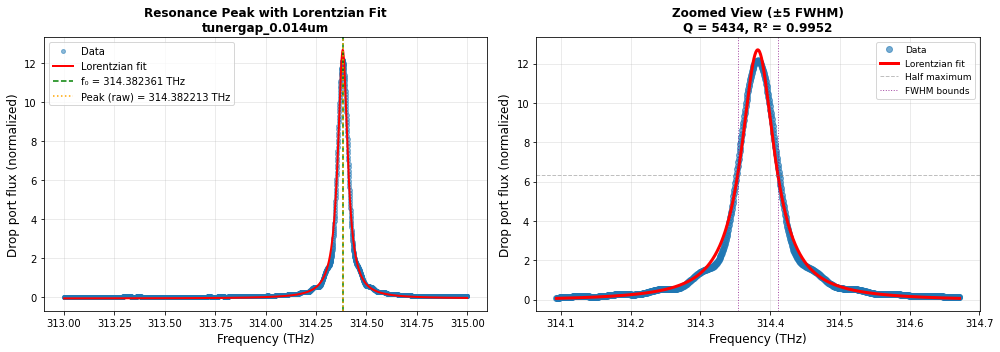


Plot complete!


In [104]:
"""
Visualize Lorentzian fit for a single resonance peak.
This plots the data and the fitted curve to verify fit quality.
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import os

# Lorentzian function
def lorentzian(f, f0, gamma, A, offset):
    """
    f0: center frequency (resonance)
    gamma: HWHM (half-width at half-maximum)
    A: amplitude
    offset: baseline
    """
    return offset + A * (gamma**2) / ((f - f0)**2 + gamma**2)

# Fit function
def fit_lorentzian_peak(freqs, flux, peak_idx, fit_window=0.5):
    """Fit Lorentzian around peak"""
    f_peak = freqs[peak_idx]
    
    # Select window around peak
    mask = np.abs(freqs - f_peak) < fit_window
    f_fit = freqs[mask]
    flux_fit = flux[mask]
    
    if len(f_fit) < 5:
        print("Not enough points for fitting")
        return None
    
    # Initial guess
    f0_guess = f_peak
    gamma_guess = 0.01  # THz
    A_guess = flux_fit[np.argmax(flux_fit)] - np.min(flux_fit)
    offset_guess = np.min(flux_fit)
    
    p0 = [f0_guess, gamma_guess, A_guess, offset_guess]
    
    try:
        # Fit
        popt, pcov = curve_fit(lorentzian, f_fit, flux_fit, p0=p0, maxfev=5000)
        f0_fit, gamma_fit, A_fit, offset_fit = popt
        
        # Calculate metrics
        fwhm = 2 * abs(gamma_fit)
        Q = abs(f0_fit / fwhm) if fwhm > 0 else np.nan
        
        # R-squared
        flux_fitted = lorentzian(f_fit, *popt)
        ss_res = np.sum((flux_fit - flux_fitted)**2)
        ss_tot = np.sum((flux_fit - np.mean(flux_fit))**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
        return {
            'f0': f0_fit,
            'fwhm': fwhm,
            'Q': Q,
            'r_squared': r_squared,
            'popt': popt,
            'f_fit': f_fit,
            'flux_fit': flux_fit
        }
    except Exception as e:
        print(f"Fit failed: {e}")
        return None

# =============================================================================
# CONFIGURATION - EDIT THESE PATHS
# =============================================================================
base_dir = "data"
base_folder = "20251212_1708_norm_r3.5_g0.02_f318.000_res48_decay0.0005_tw0.08"
gap_folder = "tunergap_0.014um"  # Pick one gap folder to visualize

# Frequency range to search for peak
fmin = 313.0  # THz
fmax = 315.0  # THz

# =============================================================================
# LOAD DATA
# =============================================================================
folder_path = os.path.join(base_dir, base_folder, gap_folder)

freqs = np.load(os.path.join(folder_path, "freqs_thz.npy"))
flux_drop = np.load(os.path.join(folder_path, "flux_disk.npy"))

# Check for normalization
norm_flux_path = os.path.join(folder_path, "norm_flux.npy")
norm_freqs_path = os.path.join(folder_path, "norm_freqs.npy")
if os.path.exists(norm_flux_path) and os.path.exists(norm_freqs_path):
    norm_flux = np.load(norm_flux_path)
    norm_freqs = np.load(norm_freqs_path)
    norm_flux_interp = np.interp(freqs, norm_freqs, norm_flux)
    flux_drop = flux_drop / norm_flux_interp
    print("Data normalized")
else:
    print("Using raw data (no normalization)")

# =============================================================================
# FIND PEAK AND FIT
# =============================================================================
# Limit to frequency window
mask = (freqs >= fmin) & (freqs <= fmax)
freqs_win = freqs[mask]
flux_win = np.abs(flux_drop[mask])  # Use abs for negative dips

# Find peaks
peaks, _ = find_peaks(flux_win, prominence=0.01, width=1)

if len(peaks) == 0:
    print("No peaks found in range!")
    exit()

# Pick strongest peak
peak_idx = peaks[np.argmax(flux_win[peaks])]
print(f"\nFound peak at index {peak_idx}")
print(f"Peak frequency (raw): {freqs_win[peak_idx]:.6f} THz")
print(f"Peak height: {flux_win[peak_idx]:.4f}")

# Fit Lorentzian
fit_result = fit_lorentzian_peak(freqs_win, flux_win, peak_idx, fit_window=0.3)

if fit_result is None:
    print("Fitting failed!")
    exit()

# Print fit results
print(f"\n{'='*60}")
print(f"LORENTZIAN FIT RESULTS")
print(f"{'='*60}")
print(f"Center frequency f0:  {fit_result['f0']:.6f} THz")
print(f"FWHM:                 {fit_result['fwhm']*1000:.3f} GHz ({fit_result['fwhm']:.6f} THz)")
print(f"Q-factor:             {fit_result['Q']:.0f}")
print(f"R² (fit quality):     {fit_result['r_squared']:.5f}")
print(f"{'='*60}")

# Generate fitted curve for full frequency range
fitted_full = lorentzian(freqs_win, *fit_result['popt'])

# =============================================================================
# PLOT
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Full spectrum with fit
ax1.plot(freqs_win, flux_win, 'o', alpha=0.5, markersize=4, label='Data')
ax1.plot(freqs_win, fitted_full, 'r-', linewidth=2, label='Lorentzian fit')
ax1.axvline(fit_result['f0'], color='green', linestyle='--', linewidth=1.5, 
            label=f"f₀ = {fit_result['f0']:.6f} THz")
ax1.axvline(freqs_win[peak_idx], color='orange', linestyle=':', linewidth=1.5, 
            label=f"Peak (raw) = {freqs_win[peak_idx]:.6f} THz")
ax1.set_xlabel("Frequency (THz)", fontsize=12)
ax1.set_ylabel("Drop port flux (normalized)", fontsize=12)
ax1.set_title(f"Resonance Peak with Lorentzian Fit\n{gap_folder}", fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Zoomed around peak
zoom_range = fit_result['fwhm'] * 5  # Show ±5 FWHM
f_center = fit_result['f0']
zoom_mask = np.abs(freqs_win - f_center) < zoom_range

ax2.plot(freqs_win[zoom_mask], flux_win[zoom_mask], 'o', alpha=0.6, 
         markersize=6, label='Data')
ax2.plot(freqs_win[zoom_mask], fitted_full[zoom_mask], 'r-', linewidth=3, 
         label='Lorentzian fit')

# Mark FWHM
half_max = fit_result['popt'][3] + fit_result['popt'][2] / 2  # offset + A/2
ax2.axhline(half_max, color='gray', linestyle='--', linewidth=1, alpha=0.5, 
            label='Half maximum')
ax2.axvline(f_center - fit_result['fwhm']/2, color='purple', linestyle=':', 
            linewidth=1, alpha=0.7)
ax2.axvline(f_center + fit_result['fwhm']/2, color='purple', linestyle=':', 
            linewidth=1, alpha=0.7, label='FWHM bounds')

ax2.set_xlabel("Frequency (THz)", fontsize=12)
ax2.set_ylabel("Drop port flux (normalized)", fontsize=12)
ax2.set_title(f"Zoomed View (±5 FWHM)\nQ = {fit_result['Q']:.0f}, R² = {fit_result['r_squared']:.4f}", 
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPlot complete!")

EXPONENTIAL DECAY FIT

f_ref = 324.010000 ± 39.9 MHz
Δf_max = 1511.934 ± 0.293 GHz
λ_decay = 0.0100 ± 0.0000 µm
R² = 0.98011
χ²_reduced = 250020.311


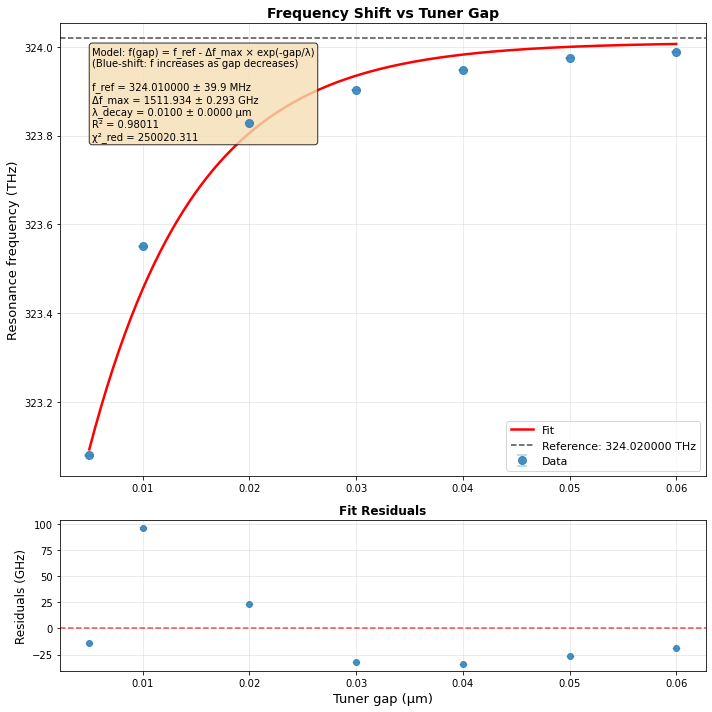


POWER LAW FIT (for comparison)

f_ref = 324.030000 ± 94.5 MHz
A = 0.002055 ± 0.000005
n = 1.159 ± 0.000
R² = 0.99530
χ²_reduced = 31006.486

MODEL COMPARISON
Exponential R² = 0.98011
Power Law R²   = 0.99530

Best model: Power Law


In [ ]:
"""
Fit the resonance frequency response to tuner gap distance.
Physical model: Exponential decay of evanescent field coupling.
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def exponential_decay(gap, f_ref, delta_f_max, lambda_decay):
    """
    Exponential approach to reference frequency as gap increases.
    
    f(gap) = f_ref - delta_f_max * exp(-gap / lambda_decay)
    
    For blue-shift: delta_f_max > 0 (frequency increases as gap decreases)
    
    Parameters:
    -----------
    f_ref : float
        Reference frequency at infinite gap (THz)
    delta_f_max : float
        Maximum frequency shift magnitude at gap=0 (THz, positive for blue-shift)
    lambda_decay : float
        Characteristic decay length (µm)
    """
    return f_ref - delta_f_max * np.exp(-gap / lambda_decay)

def power_law_decay(gap, f_ref, A, n):
    """
    Power law approach to reference (alternative).
    
    f(gap) = f_ref - A / gap^n
    
    For blue-shift: A > 0
    """
    return f_ref - A / (gap ** n)

def fit_gap_response(gaps, frequencies, freq_errors=None, ref_freq=None, model='exponential'):
    """
    Fit the frequency response to tuner gap.
    
    Parameters:
    -----------
    gaps : array
        Gap values (µm)
    frequencies : array
        Resonance frequencies (THz)
    freq_errors : array, optional
        Frequency uncertainties (THz)
    ref_freq : float, optional
        Known reference frequency (no tuner)
    model : str
        'exponential' or 'power_law'
    
    Returns:
    --------
    dict with fit parameters, errors, and quality metrics
    """
    # Remove NaN values
    valid = ~np.isnan(frequencies) & ~np.isnan(gaps)
    gaps_fit = gaps[valid]
    freqs_fit = frequencies[valid]
    
    if freq_errors is not None:
        errors_fit = freq_errors[valid]
        # Use errors as weights (inverse variance)
        sigma = errors_fit
        absolute_sigma = True
    else:
        sigma = None
        absolute_sigma = False
    
    if len(gaps_fit) < 3:
        print("Not enough valid data points for fitting")
        return None
    
    # Sort by gap
    sort_idx = np.argsort(gaps_fit)
    gaps_fit = gaps_fit[sort_idx]
    freqs_fit = freqs_fit[sort_idx]
    if sigma is not None:
        sigma = sigma[sort_idx]
    
    if model == 'exponential':
        # Initial guess for exponential
        if ref_freq is not None:
            f_ref_guess = ref_freq
        else:
            f_ref_guess = freqs_fit[-1]  # Use largest gap as estimate
        
        # For blue-shift: f increases as gap decreases
        delta_f_guess = f_ref_guess - freqs_fit[0]  # Positive for blue-shift
        lambda_guess = np.mean(gaps_fit)  # Characteristic length
        
        p0 = [f_ref_guess, delta_f_guess, lambda_guess]
        
        # Set bounds to ensure physical parameters
        # delta_f_max should be positive for blue-shift
        bounds = ([f_ref_guess - 0.01, 0, 0.001],      # Lower bounds
                  [f_ref_guess + 0.01, np.inf, 10.0])   # Upper bounds
        
        try:
            popt, pcov = curve_fit(exponential_decay, gaps_fit, freqs_fit, 
                                  p0=p0, sigma=sigma, absolute_sigma=absolute_sigma,
                                  bounds=bounds, maxfev=10000)
            
            f_ref_fit, delta_f_fit, lambda_fit = popt
            perr = np.sqrt(np.diag(pcov))
            
            # Generate fitted curve
            gap_fine = np.linspace(gaps_fit[0], gaps_fit[-1], 200)
            freq_fitted = exponential_decay(gap_fine, *popt)
            
            # Calculate R-squared
            freqs_pred = exponential_decay(gaps_fit, *popt)
            ss_res = np.sum((freqs_fit - freqs_pred)**2)
            ss_tot = np.sum((freqs_fit - np.mean(freqs_fit))**2)
            r_squared = 1 - (ss_res / ss_tot)
            
            # Calculate reduced chi-squared if errors provided
            if sigma is not None:
                chi_squared = np.sum(((freqs_fit - freqs_pred) / sigma)**2)
                dof = len(freqs_fit) - len(popt)
                reduced_chi_squared = chi_squared / dof if dof > 0 else np.nan
            else:
                reduced_chi_squared = np.nan
            
            return {
                'model': 'exponential',
                'f_ref': f_ref_fit,
                'f_ref_err': perr[0],
                'delta_f_max': delta_f_fit,
                'delta_f_max_err': perr[1],
                'lambda_decay': lambda_fit,
                'lambda_decay_err': perr[2],
                'r_squared': r_squared,
                'reduced_chi_squared': reduced_chi_squared,
                'popt': popt,
                'perr': perr,
                'gap_fine': gap_fine,
                'freq_fitted': freq_fitted,
                'gaps_data': gaps_fit,
                'freqs_data': freqs_fit,
                'freqs_errors': sigma
            }
            
        except Exception as e:
            print(f"Exponential fit failed: {e}")
            return None
            
    elif model == 'power_law':
        # Initial guess for power law
        if ref_freq is not None:
            f_ref_guess = ref_freq
        else:
            f_ref_guess = freqs_fit[-1]
        
        # For blue-shift: A should be positive
        A_guess = (f_ref_guess - freqs_fit[0]) * gaps_fit[0]**2
        n_guess = 2.0
        
        p0 = [f_ref_guess, A_guess, n_guess]
        bounds = ([f_ref_guess - 0.01, 0, 0.5],         # A > 0 for blue-shift
                  [f_ref_guess + 0.01, np.inf, 5.0])
        
        try:
            popt, pcov = curve_fit(power_law_decay, gaps_fit, freqs_fit,
                                  p0=p0, sigma=sigma, absolute_sigma=absolute_sigma,
                                  bounds=bounds, maxfev=10000)
            
            perr = np.sqrt(np.diag(pcov))
            
            gap_fine = np.linspace(gaps_fit[0], gaps_fit[-1], 200)
            freq_fitted = power_law_decay(gap_fine, *popt)
            
            freqs_pred = power_law_decay(gaps_fit, *popt)
            ss_res = np.sum((freqs_fit - freqs_pred)**2)
            ss_tot = np.sum((freqs_fit - np.mean(freqs_fit))**2)
            r_squared = 1 - (ss_res / ss_tot)
            
            if sigma is not None:
                chi_squared = np.sum(((freqs_fit - freqs_pred) / sigma)**2)
                dof = len(freqs_fit) - len(popt)
                reduced_chi_squared = chi_squared / dof if dof > 0 else np.nan
            else:
                reduced_chi_squared = np.nan
            
            return {
                'model': 'power_law',
                'f_ref': popt[0],
                'f_ref_err': perr[0],
                'A': popt[1],
                'A_err': perr[1],
                'n': popt[2],
                'n_err': perr[2],
                'r_squared': r_squared,
                'reduced_chi_squared': reduced_chi_squared,
                'popt': popt,
                'perr': perr,
                'gap_fine': gap_fine,
                'freq_fitted': freq_fitted,
                'gaps_data': gaps_fit,
                'freqs_data': freqs_fit,
                'freqs_errors': sigma
            }
            
        except Exception as e:
            print(f"Power law fit failed: {e}")
            return None


def plot_gap_response_fit(fit_result, ref_freq=None, save_path=None):
    """
    Plot the fitted gap response with data and residuals.
    """
    if fit_result is None:
        print("No fit result to plot")
        return
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), 
                                    gridspec_kw={'height_ratios': [3, 1]})
    
    # Main plot
    if fit_result['freqs_errors'] is not None:
        ax1.errorbar(fit_result['gaps_data'], fit_result['freqs_data'],
                    yerr=fit_result['freqs_errors'],
                    fmt='o', markersize=8, capsize=5, capthick=2,
                    color='tab:blue', ecolor='lightblue', 
                    label='Data', alpha=0.8, zorder=3)
    else:
        ax1.plot(fit_result['gaps_data'], fit_result['freqs_data'], 
                'o', markersize=8, color='tab:blue', label='Data', zorder=3)
    
    ax1.plot(fit_result['gap_fine'], fit_result['freq_fitted'], 
            'r-', linewidth=2.5, label='Fit', zorder=2)
    
    if ref_freq is not None:
        ax1.axhline(ref_freq, color='black', linestyle='--', linewidth=1.5,
                   alpha=0.7, label=f'Reference: {ref_freq:.6f} THz', zorder=1)
    
    ax1.set_ylabel('Resonance frequency (THz)', fontsize=13)
    ax1.set_title('Frequency Shift vs Tuner Gap', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11)
    
    # Add fit parameters text9933
    if fit_result['model'] == 'exponential':
        text = (f"Model: f(gap) = f_ref - Δf_max × exp(-gap/λ)\n"
                f"(Blue-shift: f increases as gap decreases)\n\n"
                f"f_ref = {fit_result['f_ref']:.6f} ± {fit_result['f_ref_err']*1e6:.1f} MHz\n"
                f"Δf_max = {fit_result['delta_f_max']*1000:.3f} ± {fit_result['delta_f_max_err']*1000:.3f} GHz\n"
                f"λ_decay = {fit_result['lambda_decay']:.4f} ± {fit_result['lambda_decay_err']:.4f} µm\n"
                f"R² = {fit_result['r_squared']:.5f}")
        if not np.isnan(fit_result['reduced_chi_squared']):
            text += f"\nχ²_red = {fit_result['reduced_chi_squared']:.3f}"
    else:
        text = (f"Model: f(gap) = f_ref - A/gap^n\n"
                f"(Blue-shift: f increases as gap decreases)\n\n"
                f"f_ref = {fit_result['f_ref']:.6f} ± {fit_result['f_ref_err']*1e6:.1f} MHz\n"
                f"A = {fit_result['A']:.6f} ± {fit_result['A_err']:.6f}\n"
                f"n = {fit_result['n']:.3f} ± {fit_result['n_err']:.3f}\n"
                f"R² = {fit_result['r_squared']:.5f}")
        if not np.isnan(fit_result['reduced_chi_squared']):
            text += f"\nχ²_red = {fit_result['reduced_chi_squared']:.3f}"
    
    ax1.text(0.05, 0.95, text, transform=ax1.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', 
            facecolor='wheat', alpha=0.8))
    
    # Residuals plot
    freqs_pred = exponential_decay(fit_result['gaps_data'], *fit_result['popt']) \
                 if fit_result['model'] == 'exponential' \
                 else power_law_decay(fit_result['gaps_data'], *fit_result['popt'])
    
    residuals = (fit_result['freqs_data'] - freqs_pred) * 1000  # Convert to GHz
    
    if fit_result['freqs_errors'] is not None:
        ax2.errorbar(fit_result['gaps_data'], residuals,
                    yerr=fit_result['freqs_errors'] * 1000,
                    fmt='o', markersize=6, capsize=4, color='tab:blue',
                    ecolor='lightblue', alpha=0.8)
    else:
        ax2.plot(fit_result['gaps_data'], residuals, 'o', 
                markersize=6, color='tab:blue')
    
    ax2.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax2.set_xlabel('Tuner gap (µm)', fontsize=13)
    ax2.set_ylabel('Residuals (GHz)', fontsize=12)
    ax2.set_title('Fit Residuals', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    
    plt.show()


# Example usage with your gap sweep results
if __name__ == "__main__":
    # Assuming you have results from load_gap_sweep()
    # results = load_gap_sweep(...)
    
    # Example data (replace with your actual data)
    # Example data (replace with your actual data)
    gaps = np.array([0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06])  # µm
    frequencies = np.array([323.079275, 323.550283, 323.828661, 323.902334, 323.948399, 323.973658, 323.987914])  # THz
    freq_errors = np.array([0.0001216, 0.0010515, 0.0000549, 0.0000779, 0.0000605, 0.0000587, 0.0000544])  # THz uncertainties
    ref_freq = 324.02  # Reference frequency (no tuner)
    
    # Try exponential fit
    print("="*70)
    print("EXPONENTIAL DECAY FIT")
    print("="*70)
    fit_exp = fit_gap_response(gaps, frequencies, freq_errors, 
                               ref_freq=ref_freq, model='exponential')
    
    if fit_exp:
        print(f"\nf_ref = {fit_exp['f_ref']:.6f} ± {fit_exp['f_ref_err']*1e6:.1f} MHz")
        print(f"Δf_max = {fit_exp['delta_f_max']*1000:.3f} ± {fit_exp['delta_f_max_err']*1000:.3f} GHz")
        print(f"λ_decay = {fit_exp['lambda_decay']:.4f} ± {fit_exp['lambda_decay_err']:.4f} µm")
        print(f"R² = {fit_exp['r_squared']:.5f}")
        if not np.isnan(fit_exp['reduced_chi_squared']):
            print(f"χ²_reduced = {fit_exp['reduced_chi_squared']:.3f}")
        
        plot_gap_response_fit(fit_exp, ref_freq=ref_freq)
    
    # Try power law fit for comparison
    print("\n" + "="*70)
    print("POWER LAW FIT (for comparison)")
    print("="*70)
    fit_pow = fit_gap_response(gaps, frequencies, freq_errors,
                               ref_freq=ref_freq, model='power_law')
    
    if fit_pow:
        print(f"\nf_ref = {fit_pow['f_ref']:.6f} ± {fit_pow['f_ref_err']*1e6:.1f} MHz")
        print(f"A = {fit_pow['A']:.6f} ± {fit_pow['A_err']:.6f}")
        print(f"n = {fit_pow['n']:.3f} ± {fit_pow['n_err']:.3f}")
        print(f"R² = {fit_pow['r_squared']:.5f}")
        if not np.isnan(fit_pow['reduced_chi_squared']):
            print(f"χ²_reduced = {fit_pow['reduced_chi_squared']:.3f}")
        
        # Uncomment to plot power law fit
        # plot_gap_response_fit(fit_pow, ref_freq=ref_freq)
    
    # Compare models
    if fit_exp and fit_pow:
        print("\n" + "="*70)
        print("MODEL COMPARISON")
        print("="*70)
        print(f"Exponential R² = {fit_exp['r_squared']:.5f}")
        print(f"Power Law R²   = {fit_pow['r_squared']:.5f}")
        print(f"\nBest model: {'Exponential' if fit_exp['r_squared'] > fit_pow['r_squared'] else 'Power Law'}")

# 2d Colormap

Looking for these files:
  gap_sweep_0.04.csv
  gap_sweep_0.05.csv
  gap_sweep_0.06.csv
  gap_sweep_0.07.csv
  gap_sweep_0.08.csv
  gap_sweep_0.09.csv
  gap_sweep_0.10.csv
✓ Loaded gap_sweep_0.04.csv: 14 points
✓ Loaded gap_sweep_0.05.csv: 14 points
✓ Loaded gap_sweep_0.06.csv: 14 points
✓ Loaded gap_sweep_0.07.csv: 14 points
✓ Loaded gap_sweep_0.08.csv: 14 points
✓ Loaded gap_sweep_0.09.csv: 14 points
✓ Loaded gap_sweep_0.10.csv: 14 points

✓ Successfully loaded 7 width files
  Widths: [0.04, 0.05, 0.060000000000000005, 0.07, 0.08000000000000002, 0.09000000000000001, 0.1]

Wavelength ranges:
  Full: 952.766 - 957.750 nm
  Zoom: 953.258 - 957.750 nm

Plot saved to: /home/jonah/Desktop/meep/Tunable-Disk-Resonator-Meep-/colormap/tuner_sweep_2d_wavelength.png


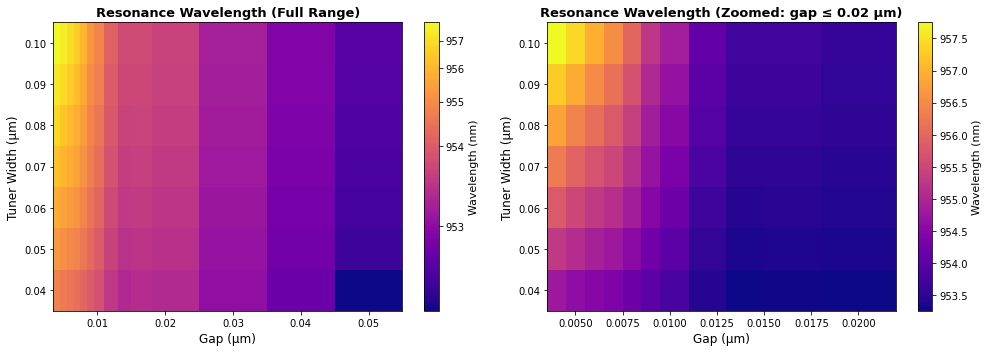


FULL RANGE STATISTICS
Wavelength range: 952.766 - 957.750 nm
Frequency range: 313.0176 - 314.6548 THz
Data shape: 7 widths × 14 gaps

ZOOMED RANGE STATISTICS (gap ≤ 0.02 μm)
Wavelength range: 953.258 - 957.750 nm
Number of gaps shown: 11 / 14
Gap range: 0.0040 - 0.0200 μm


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm, LogNorm, TwoSlopeNorm
import os

# Configuration
data_dir = "/home/jonah/Desktop/meep/Tunable-Disk-Resonator-Meep-/colormap"
widths = np.arange(0.04, 0.101, 0.01)  # 0.04 to 0.10
csv_pattern = "gap_sweep_{width:.2f}.csv"
zoom_gap_max = 0.02  # Maximum gap for zoomed view (µm)

# Debug: Print what files we're looking for
print("Looking for these files:")
for width in widths:
    filename = csv_pattern.format(width=width)
    print(f"  {filename}")

if not os.path.exists(data_dir):
    print(f"Error: Directory {data_dir} does not exist!")
    exit()

# Load all data using numpy
data_dict = {}
for width in widths:
    filename = csv_pattern.format(width=width)
    filepath = os.path.join(data_dir, filename)
    try:
        data = np.genfromtxt(filepath, delimiter=',', names=True, comments='#')
        data_dict[width] = data
        print(f"✓ Loaded {filename}: {len(data)} points")
    except (FileNotFoundError, IOError):
        print(f"✗ Warning: {filepath} not found, skipping")

if not data_dict:
    print("No data files found! Check your data_dir and file naming pattern.")
    print(f"Looking in: {data_dir}")
    print(f"Pattern: {csv_pattern}")
    
    # List what files actually exist
    print(f"\nFiles actually in directory:")
    for f in sorted(os.listdir(data_dir)):
        if f.startswith("gap_sweep"):
            print(f"  {f}")
    exit()

# Extract gaps (assuming all files have same gap values)
first_key = list(data_dict.keys())[0]
gaps = data_dict[first_key]['gap_um']
n_gaps = len(gaps)
n_widths = len(data_dict)

print(f"\n✓ Successfully loaded {n_widths} width files")
print(f"  Widths: {sorted(data_dict.keys())}")

# Build 2D arrays
width_array = np.array(sorted(data_dict.keys()))
gap_array = gaps
freq_matrix = np.zeros((n_widths, n_gaps))

for i, width in enumerate(width_array):
    freq_matrix[i, :] = data_dict[width]['f_res_THz']

# Convert frequencies to wavelengths
c_nm_thz = 299792.458  # speed of light: λ[nm] = c[nm·THz] / f[THz]
wavelength_matrix = c_nm_thz / freq_matrix  # nm

# Create mask for zoomed view
zoom_mask = gap_array <= zoom_gap_max
gap_array_zoom = gap_array[zoom_mask]
wavelength_matrix_zoom = wavelength_matrix[:, zoom_mask]

# =============================================================================
# CUSTOMIZE COLORMAP NORMALIZATION
# =============================================================================
# Find wavelength range
vmin = wavelength_matrix.min()
vmax = wavelength_matrix.max()
vmin_zoom = wavelength_matrix_zoom.min()
vmax_zoom = wavelength_matrix_zoom.max()

print(f"\nWavelength ranges:")
print(f"  Full: {vmin:.3f} - {vmax:.3f} nm")
print(f"  Zoom: {vmin_zoom:.3f} - {vmax_zoom:.3f} nm")

# OPTION 1: PowerNorm - emphasize lower values with gamma < 1
# gamma < 1: more colors for lower values
# gamma > 1: more colors for higher values
# Try gamma = 0.3 to 0.7 for emphasis on lower wavelengths
norm_full = PowerNorm(gamma=0.4, vmin=vmin, vmax=vmax)
norm_zoom = PowerNorm(gamma=1, vmin=vmin_zoom, vmax=vmax_zoom)

# OPTION 2: TwoSlopeNorm - split colormap at specific value
# Useful if you want to emphasize a specific wavelength range
# midpoint = 930.0  # nm - adjust to your region of interest
# norm_full = TwoSlopeNorm(vmin=vmin, vcenter=midpoint, vmax=vmax)
# norm_zoom = TwoSlopeNorm(vmin=vmin_zoom, vcenter=midpoint, vmax=vmax_zoom)

# =============================================================================
# PLOT: FULL AND ZOOMED WAVELENGTH SIDE-BY-SIDE
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Absolute wavelength (full range) with custom normalization
im1 = ax1.pcolormesh(gap_array, width_array, wavelength_matrix, 
                      cmap='plasma', norm=norm_full, shading='auto')
ax1.set_xlabel('Gap (μm)', fontsize=12)
ax1.set_ylabel('Tuner Width (μm)', fontsize=12)
ax1.set_title('Resonance Wavelength (Full Range)', 
              fontsize=13, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('Wavelength (nm)', fontsize=11)

# Plot 2: Absolute wavelength (zoomed) with custom normalization
im2 = ax2.pcolormesh(gap_array_zoom, width_array, wavelength_matrix_zoom, 
                      cmap='plasma', norm=norm_zoom, shading='auto')
ax2.set_xlabel('Gap (μm)', fontsize=12)
ax2.set_ylabel('Tuner Width (μm)', fontsize=12)
ax2.set_title(f'Resonance Wavelength (Zoomed: gap ≤ {zoom_gap_max} μm)', 
              fontsize=13, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('Wavelength (nm)', fontsize=11)

plt.tight_layout()

# Save plot
output_path = os.path.join(data_dir, 'tuner_sweep_2d_wavelength.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\nPlot saved to: {output_path}")
plt.show()

# =============================================================================
# PRINT STATISTICS
# =============================================================================
print(f"\n{'='*70}")
print("FULL RANGE STATISTICS")
print(f"{'='*70}")
print(f"Wavelength range: {wavelength_matrix.min():.3f} - {wavelength_matrix.max():.3f} nm")
print(f"Frequency range: {freq_matrix.min():.4f} - {freq_matrix.max():.4f} THz")
print(f"Data shape: {n_widths} widths × {n_gaps} gaps")

print(f"\n{'='*70}")
print(f"ZOOMED RANGE STATISTICS (gap ≤ {zoom_gap_max} μm)")
print(f"{'='*70}")
print(f"Wavelength range: {wavelength_matrix_zoom.min():.3f} - {wavelength_matrix_zoom.max():.3f} nm")
print(f"Number of gaps shown: {len(gap_array_zoom)} / {n_gaps}")
print(f"Gap range: {gap_array_zoom.min():.4f} - {gap_array_zoom.max():.4f} μm")
print(f"{'='*70}")

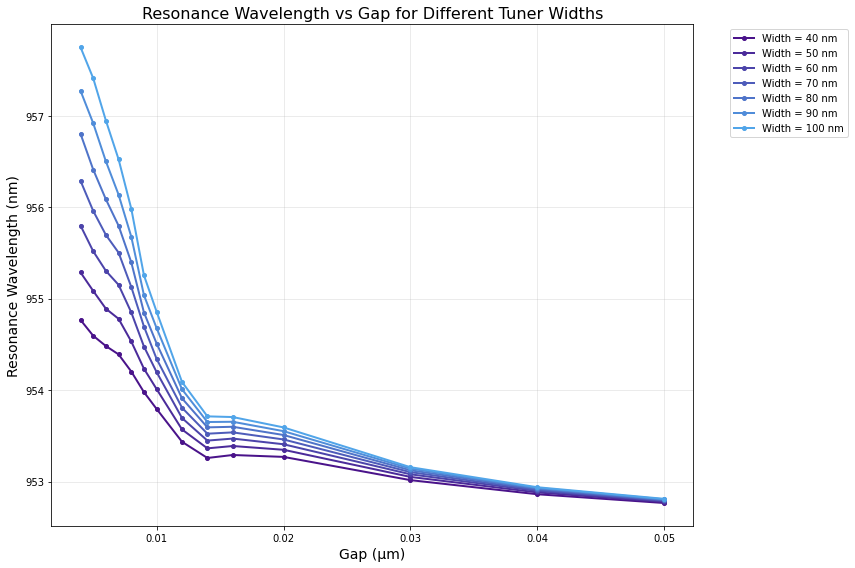

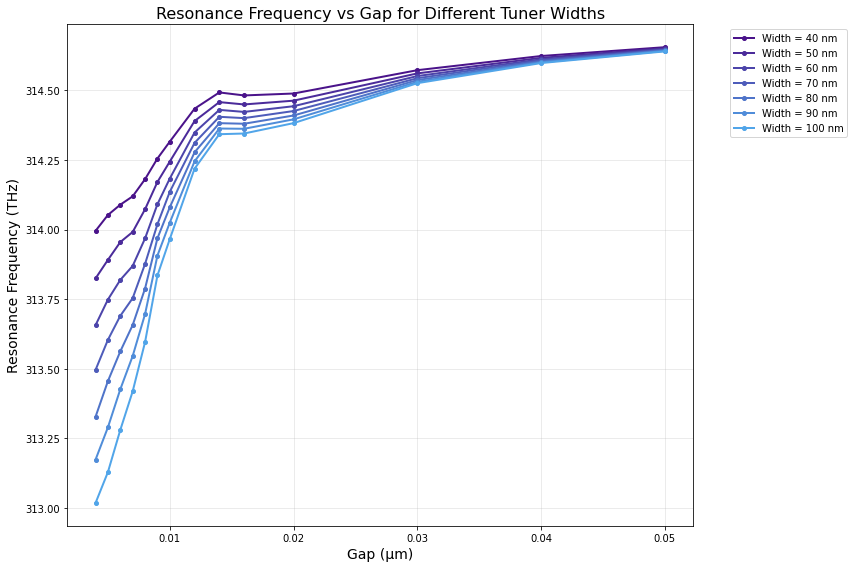

In [35]:


# Assuming you already have data_dict loaded from the previous cells
# Extract the data
width_array = np.array(sorted(data_dict.keys()))
first_key = list(data_dict.keys())[0]
gap_array = data_dict[first_key]['gap_um']
n_widths = len(data_dict)
n_gaps = len(gap_array)

# Create frequency matrix
freq_matrix = np.zeros((n_widths, n_gaps))
for i, width in enumerate(width_array):
    freq_matrix[i, :] = data_dict[width]['f_res_THz']

# Convert to wavelength
c_nm_thz = 299792.458  # nm*THz
wavelength_matrix = c_nm_thz / freq_matrix  # nm

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))


from matplotlib.colors import Normalize
import matplotlib.colors as mcolors

# Create a single-color gradient (dark to light blue)
color_start = mcolors.to_rgb("#4A138A")    # Dark purple
color_end = mcolors.to_rgb("#51A5E9")      # Very light blue

# Create custom colormap
from matplotlib.colors import LinearSegmentedColormap
colors_list = [color_start, color_end]
n_bins = 256
cmap_custom = LinearSegmentedColormap.from_list('blue_gradient', colors_list, N=n_bins)

# Plot each width as a separate curve
colors = [cmap_custom(i / (n_widths - 1)) for i in range(n_widths)]
for i, width in enumerate(width_array):
    ax.plot(gap_array, wavelength_matrix[i, :], 
            marker='o', markersize=4, linewidth=2,
            color=colors[i], label=f'Width = {width*1000:.0f} nm')

ax.set_xlabel('Gap (μm)', fontsize=14)
ax.set_ylabel('Resonance Wavelength (nm)', fontsize=14)
ax.set_title('Resonance Wavelength vs Gap for Different Tuner Widths', fontsize=16)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: Plot with frequency instead of wavelength
fig, ax = plt.subplots(figsize=(12, 8))
for i, width in enumerate(width_array):
    ax.plot(gap_array, freq_matrix[i, :], 
            marker='o', markersize=4, linewidth=2,
            color=colors[i], label=f'Width = {width*1000:.0f} nm')

ax.set_xlabel('Gap (μm)', fontsize=14)
ax.set_ylabel('Resonance Frequency (THz)', fontsize=14)
ax.set_title('Resonance Frequency vs Gap for Different Tuner Widths', fontsize=16)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# single spectrum 

Peak positions in drop port flux (THz):
[309.0207 309.7941 311.6655 313.5555 313.6609 314.6629 316.3016 316.6463
 318.2177 318.3677 319.6251 321.3204 322.8625 323.0278 324.6872 325.9499
 326.0786 327.6107]


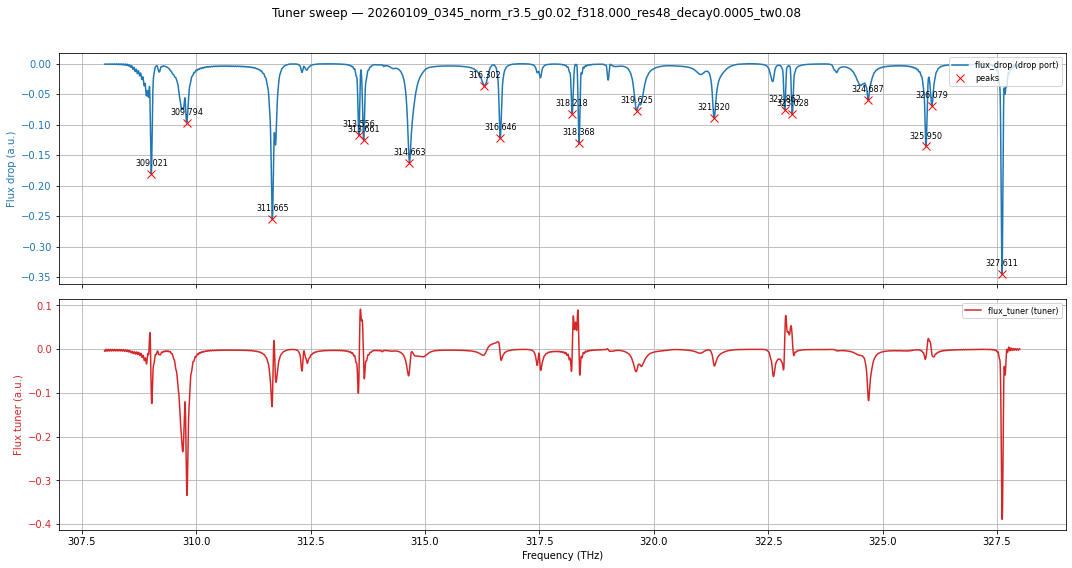

In [ ]:
# Quick peak finder for drop port flux, with normalization
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt
import os

base_folder = "20251212_1708_norm_r3.5_g0.02_f318.000_res48_decay0.0005_tw0.08"
run_dir = os.path.join(base_dir, base_folder, "tunergap_0.050um")
#run_dir = os.path.join(base_dir, base_folder)

freqs = np.load(os.path.join(run_dir, "freqs_thz.npy"))
flux_bus = np.load(os.path.join(run_dir, "flux_bus.npy"))
flux_drop = np.load(os.path.join(run_dir, "flux_drop.npy"))
flux_tuner = np.load(os.path.join(run_dir, "flux_tuner.npy"))

# --- Normalize fluxes if normalization data exists ---
norm_flux_path = os.path.join(run_dir, "norm_flux.npy")
norm_freqs_path = os.path.join(run_dir, "norm_freqs.npy")
if os.path.exists(norm_flux_path) and os.path.exists(norm_freqs_path):
    norm_flux = np.load(norm_flux_path)
    norm_freqs = np.load(norm_freqs_path)
    norm_flux_interp = np.interp(freqs, norm_freqs, norm_flux)
    flux_drop = flux_drop / norm_flux_interp
    flux_tuner = flux_tuner / norm_flux_interp

# Find peaks (absolute) in drop port flux
peaks, _ = find_peaks(np.abs(flux_drop), prominence=0.03)
peak_freqs = freqs[peaks]

print("Peak positions in drop port flux (THz):")
print(np.round(peak_freqs, 4))

# define plotting colors (ensure they exist before use)
color1 = 'tab:blue'
color2 = 'tab:red'

# stacked plots with a shared x-axis (two separate y-axes, no overlap)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(15, 8))

# top: drop port
ax1.plot(freqs, flux_drop, color=color1, ls='-', label='flux_drop (drop port)')
ax1.plot(peak_freqs, flux_drop[peaks], 'rx', ms=8, label='peaks')
for x, y in zip(peak_freqs, flux_drop[peaks]):
    ax1.annotate(f"{x:.3f}", (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)
ax1.set_ylabel("Flux drop (a.u.)", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True)

# bottom: tuner
ax2.plot(freqs, flux_tuner, color=color2, ls='-', label='flux_tuner (tuner)')
ax2.set_ylabel("Flux tuner (a.u.)", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_xlabel("Frequency (THz)")
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True)

fig.suptitle(f"Tuner sweep — {os.path.basename(base_folder)}")
plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave room for the suptitle
plt.show()

# 2d vs 3d comparison


Loading 2D simulation from: data/20251209_2309_norm_r3.5_g0.02_f322.000_res48_decay0.0005_tw0.05/tunergap_0.005um
  → Applied normalization
  → Loaded 30000 frequency points
  → Frequency range: 312.000 - 332.000 THz

Loading 3D simulation from: data/20260106_1722_3d_norm_r3.5_g0.02_f318.000_res48_decay0.01_tw0.05/tunergap_0.005um
  → Applied normalization
  → Loaded 20000 frequency points
  → Frequency range: 308.000 - 328.000 THz

Filtering to frequency range: 308.000 - 328.000 THz

Normalizing spectra to max peak = 1...
  2D max peak: 0.4238 → normalized to 1.0
  3D max peak: 0.1641 → normalized to 1.0

PEAK DETECTION

2D Simulation:
  Found 15 peaks at:
    Peak 0: 312.024001 THz (normalized height: 0.5726)
    Peak 1: 312.100003 THz (normalized height: 0.7341)
    Peak 2: 313.890730 THz (normalized height: 1.0000)
    Peak 3: 315.065436 THz (normalized height: 0.2851)
    Peak 4: 316.778826 THz (normalized height: 0.4781)
    Peak 5: 316.868829 THz (normalized height: 0.5945)
   

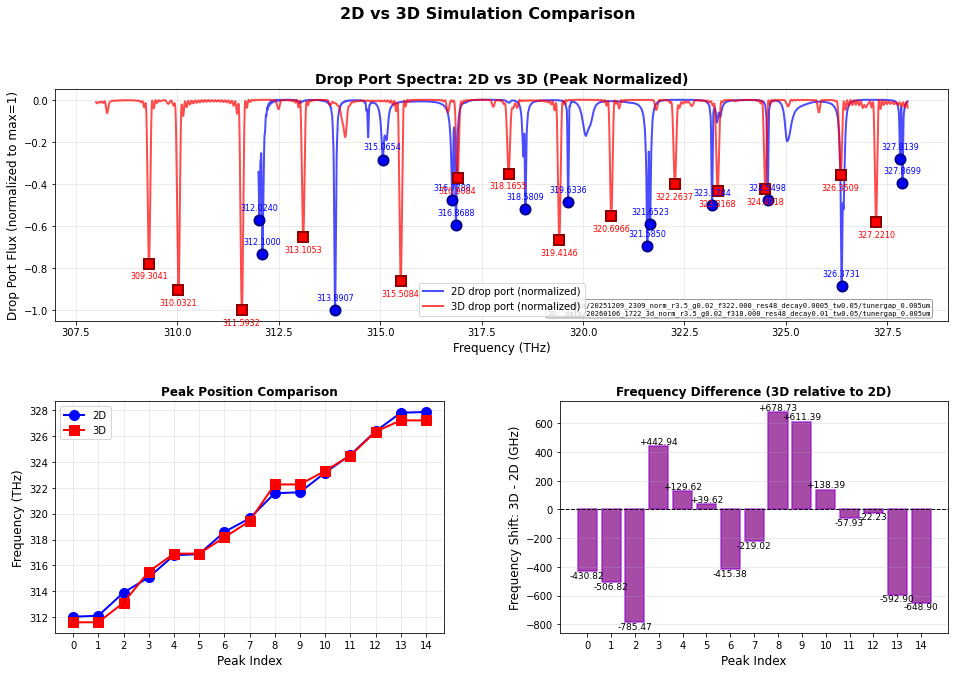


SUMMARY STATISTICS
Mean frequency shift (3D - 2D): -109.25 ± 443.14 GHz
Max frequency shift: 785.47 GHz

2D peaks: [312.0240008  312.10000333 313.89072969 315.06543551 316.77882596
 316.86882896 318.58088603 319.63358779 321.58498617 321.65232174
 323.17837261 324.54975166 326.37314577 327.81386046 327.86986233]
3D peaks: [309.3040652  310.03210161 311.59317966 313.10525526 315.50837542
 316.90844542 318.16550828 319.41457073 320.69663483 322.26371319
 323.31676584 324.49182459 326.35091755 327.22096105]
Number of matched peak pairs: 15


In [31]:
"""
Compare 2D vs 3D simulation results.
- Load flux spectra from two different simulation folders
- Plot spectra overlay with normalized peak heights
- Find and compare resonance peak positions
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import os

def compare_2d_3d_simulations(path_2d, path_3d, fmin=None, fmax=None, 
                               prominence=0.01, normalize=True):
    """
    Compare resonance spectra between 2D and 3D simulations.
    
    Parameters:
    -----------
    path_2d : str
        Path to 2D simulation data folder
    path_3d : str
        Path to 3D simulation data folder
    fmin, fmax : float, optional
        Frequency range to analyze (THz)
    prominence : float
        Peak detection prominence threshold
    normalize : bool
        Whether to apply normalization if available
    
    Returns:
    --------
    dict with comparison results
    """
    
    # Helper function to load and normalize data
    def load_simulation_data(path, label):
        print(f"\nLoading {label} simulation from: {path}")
        
        if not os.path.exists(path):
            raise FileNotFoundError(f"Path not found: {path}")
        
        # Load flux data
        freqs = np.load(os.path.join(path, "freqs_thz.npy"))
        flux_drop = np.load(os.path.join(path, "flux_drop.npy"))
        flux_bus = np.load(os.path.join(path, "flux_bus.npy"))
        
        # Check for normalization files
        if normalize:
            norm_flux_path = os.path.join(path, "norm_flux.npy")
            norm_freqs_path = os.path.join(path, "norm_freqs.npy")
            
            if os.path.exists(norm_flux_path) and os.path.exists(norm_freqs_path):
                norm_flux = np.load(norm_flux_path)
                norm_freqs = np.load(norm_freqs_path)
                norm_flux_interp = np.interp(freqs, norm_freqs, norm_flux)
                flux_drop = flux_drop / norm_flux_interp
                flux_bus = flux_bus / norm_flux_interp
                print(f"  → Applied normalization")
            else:
                print(f"  → No normalization files found")
        
        print(f"  → Loaded {len(freqs)} frequency points")
        print(f"  → Frequency range: {freqs.min():.3f} - {freqs.max():.3f} THz")
        
        return freqs, flux_drop, flux_bus
    
    # Load both simulations
    freqs_2d, flux_drop_2d, flux_bus_2d = load_simulation_data(path_2d, "2D")
    freqs_3d, flux_drop_3d, flux_bus_3d = load_simulation_data(path_3d, "3D")
    
    # Apply frequency range filter if specified
    if fmin is not None or fmax is not None:
        if fmin is None:
            fmin = min(freqs_2d.min(), freqs_3d.min())
        if fmax is None:
            fmax = max(freqs_2d.max(), freqs_3d.max())
        
        print(f"\nFiltering to frequency range: {fmin:.3f} - {fmax:.3f} THz")
        
        mask_2d = (freqs_2d >= fmin) & (freqs_2d <= fmax)
        freqs_2d = freqs_2d[mask_2d]
        flux_drop_2d = flux_drop_2d[mask_2d]
        flux_bus_2d = flux_bus_2d[mask_2d]
        
        mask_3d = (freqs_3d >= fmin) & (freqs_3d <= fmax)
        freqs_3d = freqs_3d[mask_3d]
        flux_drop_3d = flux_drop_3d[mask_3d]
        flux_bus_3d = flux_bus_3d[mask_3d]
    
    # Normalize spectra to max peak = 1 for visualization
    print("\nNormalizing spectra to max peak = 1...")
    flux_drop_2d_abs = np.abs(flux_drop_2d)
    flux_drop_3d_abs = np.abs(flux_drop_3d)
    
    max_2d = np.max(flux_drop_2d_abs)
    max_3d = np.max(flux_drop_3d_abs)
    
    flux_drop_2d_norm = flux_drop_2d / max_2d
    flux_drop_3d_norm = flux_drop_3d / max_3d
    
    print(f"  2D max peak: {max_2d:.4f} → normalized to 1.0")
    print(f"  3D max peak: {max_3d:.4f} → normalized to 1.0")
    
    # Find peaks in normalized drop port spectra
    print(f"\n{'='*70}")
    print("PEAK DETECTION")
    print(f"{'='*70}")
    
    peaks_2d, props_2d = find_peaks(np.abs(flux_drop_2d_norm), 
                                     prominence=prominence, width=1)
    peak_freqs_2d = freqs_2d[peaks_2d]
    peak_heights_2d = np.abs(flux_drop_2d_norm[peaks_2d])
    
    peaks_3d, props_3d = find_peaks(np.abs(flux_drop_3d_norm), 
                                     prominence=prominence, width=1)
    peak_freqs_3d = freqs_3d[peaks_3d]
    peak_heights_3d = np.abs(flux_drop_3d_norm[peaks_3d])
    
    print(f"\n2D Simulation:")
    print(f"  Found {len(peaks_2d)} peaks at:")
    for i, (f, h) in enumerate(zip(peak_freqs_2d, peak_heights_2d)):
        print(f"    Peak {i}: {f:.6f} THz (normalized height: {h:.4f})")
    
    print(f"\n3D Simulation:")
    print(f"  Found {len(peaks_3d)} peaks at:")
    for i, (f, h) in enumerate(zip(peak_freqs_3d, peak_heights_3d)):
        print(f"    Peak {i}: {f:.6f} THz (normalized height: {h:.4f})")
    
    # Match peaks between 2D and 3D (closest frequency matching)
    print(f"\n{'='*70}")
    print("PEAK MATCHING (2D → 3D)")
    print(f"{'='*70}")
    
    matched_pairs = []
    for i, f_2d in enumerate(peak_freqs_2d):
        if len(peak_freqs_3d) > 0:
            # Find closest 3D peak
            idx_closest = np.argmin(np.abs(peak_freqs_3d - f_2d))
            f_3d = peak_freqs_3d[idx_closest]
            freq_diff = (f_3d - f_2d) * 1000  # GHz
            freq_diff_pct = (freq_diff / f_2d) * 100 / 1000  # percent
            
            matched_pairs.append({
                '2d_idx': i,
                '3d_idx': idx_closest,
                'freq_2d': f_2d,
                'freq_3d': f_3d,
                'freq_diff_ghz': freq_diff,
                'freq_diff_pct': freq_diff_pct
            })
            
            print(f"Peak {i}: 2D={f_2d:.6f} THz → 3D={f_3d:.6f} THz "
                  f"(Δf={freq_diff:+.2f} GHz, {freq_diff_pct:+.3f}%)")
    
    # Create comparison plots
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)
    
    ax1 = fig.add_subplot(gs[0, :])  # Top: spectra overlay
    ax2 = fig.add_subplot(gs[1, 0])  # Bottom left: peak positions
    ax3 = fig.add_subplot(gs[1, 1])  # Bottom right: frequency differences
    
    # Plot 1: Spectra overlay (normalized)
    ax1.plot(freqs_2d, flux_drop_2d_norm, 'b-', linewidth=2, alpha=0.7, 
            label='2D drop port (normalized)')
    ax1.plot(freqs_3d, flux_drop_3d_norm, 'r-', linewidth=2, alpha=0.7, 
            label='3D drop port (normalized)')
    
    # Mark peaks
    ax1.plot(peak_freqs_2d, flux_drop_2d_norm[peaks_2d], 'bo', markersize=10, 
            markeredgecolor='darkblue', markeredgewidth=2)
    ax1.plot(peak_freqs_3d, flux_drop_3d_norm[peaks_3d], 'rs', markersize=10, 
            markeredgecolor='darkred', markeredgewidth=2)
    
    # Annotate peaks
    for i, f in enumerate(peak_freqs_2d):
        ax1.annotate(f"{f:.4f}", (f, flux_drop_2d_norm[peaks_2d[i]]), 
                    textcoords="offset points", xytext=(0, 10), 
                    ha='center', fontsize=8, color='blue')
    for i, f in enumerate(peak_freqs_3d):
        ax1.annotate(f"{f:.4f}", (f, flux_drop_3d_norm[peaks_3d[i]]), 
                    textcoords="offset points", xytext=(0, -15), 
                    ha='center', fontsize=8, color='red')
    
    ax1.set_xlabel("Frequency (THz)", fontsize=12)
    ax1.set_ylabel("Drop Port Flux (normalized to max=1)", fontsize=12)
    ax1.set_title("Drop Port Spectra: 2D vs 3D (Peak Normalized)", fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Add file paths as small text in bottom right corner of main plot
    path_text = (f"2D: {os.path.relpath(path_2d)}\n"
                f"3D: {os.path.relpath(path_3d)}")
    ax1.text(0.98, 0.02, path_text, transform=ax1.transAxes, 
            fontsize=7, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'),
            family='monospace')
    
    # Plot 2: Peak position comparison
    if matched_pairs:
        peak_indices = np.arange(len(matched_pairs))
        freqs_2d_matched = [p['freq_2d'] for p in matched_pairs]
        freqs_3d_matched = [p['freq_3d'] for p in matched_pairs]
        
        ax2.plot(peak_indices, freqs_2d_matched, 'bo-', linewidth=2, 
                markersize=10, label='2D')
        ax2.plot(peak_indices, freqs_3d_matched, 'rs-', linewidth=2, 
                markersize=10, label='3D')
        
        # Add connecting lines to show shifts
        for idx, (f2d, f3d) in zip(peak_indices, zip(freqs_2d_matched, freqs_3d_matched)):
            ax2.plot([idx, idx], [f2d, f3d], 'k--', alpha=0.3, linewidth=1)
        
        ax2.set_xlabel("Peak Index", fontsize=12)
        ax2.set_ylabel("Frequency (THz)", fontsize=12)
        ax2.set_title("Peak Position Comparison", fontsize=12, fontweight='bold')
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)
        ax2.set_xticks(peak_indices)
    
    # Plot 3: Frequency difference 2D → 3D
    if matched_pairs:
        freq_diffs = [p['freq_diff_ghz'] for p in matched_pairs]
        
        ax3.bar(peak_indices, freq_diffs, color='purple', alpha=0.7, 
               edgecolor='darkviolet', linewidth=1.5)
        ax3.axhline(0, color='black', linestyle='--', linewidth=1)
        
        # Add value labels
        for i, diff in enumerate(freq_diffs):
            ax3.text(i, diff, f"{diff:+.2f}", ha='center', 
                    va='bottom' if diff > 0 else 'top', fontsize=9)
        
        ax3.set_xlabel("Peak Index", fontsize=12)
        ax3.set_ylabel("Frequency Shift: 3D - 2D (GHz)", fontsize=12)
        ax3.set_title("Frequency Difference (3D relative to 2D)", 
                     fontsize=12, fontweight='bold')
        ax3.grid(True, alpha=0.3, axis='y')
        ax3.set_xticks(peak_indices)
    
    plt.suptitle("2D vs 3D Simulation Comparison", 
                fontsize=16, fontweight='bold', y=0.995)
    plt.show()
    
    # Print summary statistics
    if matched_pairs:
        print(f"\n{'='*70}")
        print("SUMMARY STATISTICS")
        print(f"{'='*70}")
        freq_diffs = [p['freq_diff_ghz'] for p in matched_pairs]
        print(f"Mean frequency shift (3D - 2D): {np.mean(freq_diffs):.2f} ± {np.std(freq_diffs):.2f} GHz")
        print(f"Max frequency shift: {np.max(np.abs(freq_diffs)):.2f} GHz")
        print(f"{'='*70}")
    
    return {
        'freqs_2d': freqs_2d,
        'freqs_3d': freqs_3d,
        'flux_drop_2d_norm': flux_drop_2d_norm,
        'flux_drop_3d_norm': flux_drop_3d_norm,
        'flux_bus_2d': flux_bus_2d,
        'flux_bus_3d': flux_bus_3d,
        'peak_freqs_2d': peak_freqs_2d,
        'peak_freqs_3d': peak_freqs_3d,
        'matched_pairs': matched_pairs
    }


# ============================================================================
# EXAMPLE USAGE
# ============================================================================
if __name__ == "__main__":
    base_dir = "data"
    
    # Specify paths to 2D and 3D simulation data
    path_2d = os.path.join(base_dir, "20251209_2309_norm_r3.5_g0.02_f322.000_res48_decay0.0005_tw0.05", "tunergap_0.005um")
    path_3d = os.path.join(base_dir, "20260106_1722_3d_norm_r3.5_g0.02_f318.000_res48_decay0.01_tw0.05", "tunergap_0.005um")
    
    # Run comparison
    results = compare_2d_3d_simulations(
        path_2d=path_2d,
        path_3d=path_3d,
        fmin=308.0,  # Optional: limit frequency range
        fmax=328.0,
        prominence=0.2,  # Adjust peak detection sensitivity
        normalize=True
    )
    
    # Access results
    print(f"\n2D peaks: {results['peak_freqs_2d']}")
    print(f"3D peaks: {results['peak_freqs_3d']}")
    print(f"Number of matched peak pairs: {len(results['matched_pairs'])}")

# tuner arc test 

Found 16 theta simulations in data/20260109_2011_norm_r3.5_g0.02_f318.000_res48_decay0.0005_tw0.08
Reference simulation 'ref_notuner' not found.
theta_10_24pi: arc_span=0.8333×π | f_res=313.155704 ± 85.127 MHz, FWHM=92.139 ± 0.334 GHz, Q=3399 ± 12, R²=0.9977
theta_11_48pi: arc_span=0.4583×π | f_res=313.842385 ± 99.374 MHz, FWHM=46.076 ± 0.320 GHz, Q=6811 ± 47, R²=0.9895
theta_13_48pi: arc_span=0.5417×π | f_res=313.655403 ± 861.989 MHz, FWHM=55.494 ± 2.853 GHz, Q=5652 ± 291, R²=0.6321
theta_15_48pi: arc_span=0.6250×π | f_res=313.486281 ± 78.644 MHz, FWHM=85.227 ± 0.286 GHz, Q=3678 ± 12, R²=0.9976
theta_17_48pi: arc_span=0.7083×π | f_res=313.243960 ± 84.117 MHz, FWHM=68.544 ± 0.294 GHz, Q=4570 ± 20, R²=0.9963
theta_19_48pi: arc_span=0.7917×π | f_res=313.173778 ± 270.643 MHz, FWHM=92.810 ± 1.063 GHz, Q=3374 ± 39, R²=0.9775
theta_21_48pi: arc_span=0.8750×π | f_res=313.041430 ± 217.274 MHz, FWHM=88.277 ± 0.856 GHz, Q=3546 ± 34, R²=0.9885
theta_3_24pi: arc_span=0.2500×π | f_res=314.177580 ± 

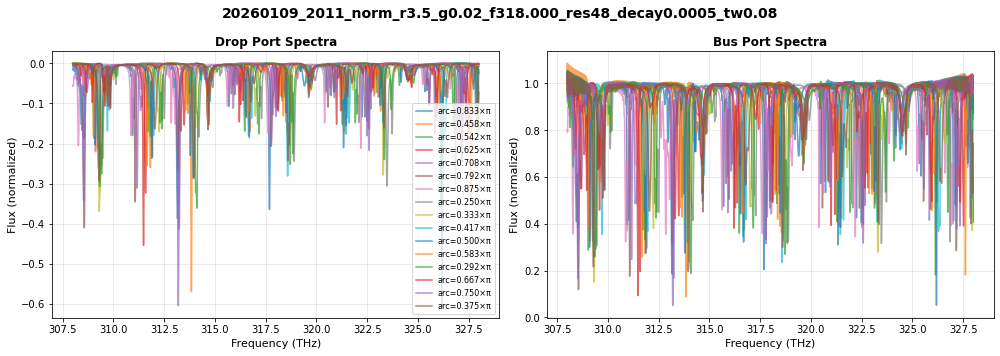


⚠ Warning: Filtered out 2 points with R² < 0.9


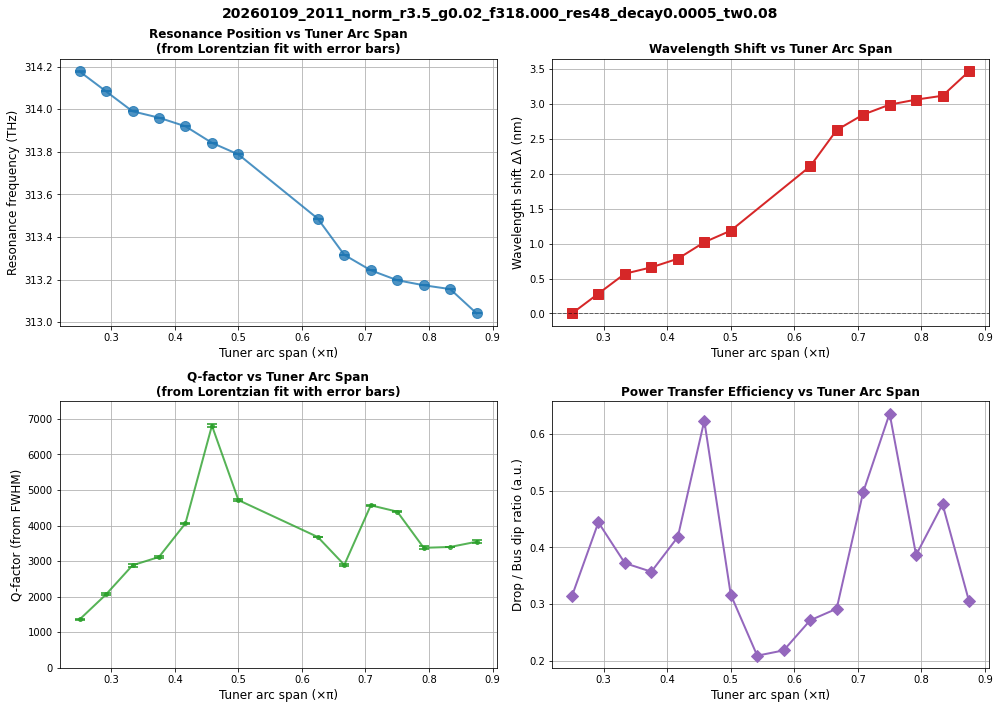


RESONANCE CHARACTERISTICS VS TUNER ARC SPAN (Lorentzian fit with uncertainties)
Arc span (×π)   f_res (THz)          λ_shift (nm)   FWHM (GHz)         Q-factor           R²        
------------------------------------------------------------------------------------------------------------------------
0.2500          314.177580 ± 677.2 MHz +0.000         231.263 ± 4.153    1359 ± 24          0.9469    
0.2917          314.084076 ± 442.1 MHz +0.284         152.240 ± 2.015    2063 ± 27          0.9661    
0.3333          313.990452 ± 474.4 MHz +0.569         108.913 ± 1.865    2883 ± 49          0.9419    
0.3750          313.960440 ± 271.5 MHz +0.660         100.735 ± 1.039    3117 ± 32          0.9779    
0.4167          313.920053 ± 104.8 MHz +0.783         77.250 ± 0.371     4064 ± 20          0.9950    
0.4583          313.842385 ± 99.4 MHz +1.019         46.076 ± 0.320     6811 ± 47          0.9895    
0.5000          313.787953 ± 118.0 MHz +1.185         66.528 ± 0.404     4717 ± 

In [91]:
def load_gap_sweep(base_folder, fmin, fmax):
    """
    Analyze resonance frequency shift vs tuner arc angle.
    
    For a fixed tuner width and gap, varies the arc angle of the tuner.
    Tracks how the resonance frequency shifts with tuner arc coverage.
    
    Modified to handle tuner arc angle variations (theta_X_24pi folders).
    Arc spans from -θ to +θ, so total arc = 2θ (expressed as multiple of π).
    
    Metrics:
    - Resonance frequency from Lorentzian fit
    - Q-factor = f0 / FWHM from Lorentzian fit
    - Drop port coupling strength
    - Frequency shift relative to reference (no tuner)
    - Wavelength shift in nm
    
    Only includes points with Lorentzian fit R² ≥ 0.9.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    from scipy.signal import find_peaks
    from scipy.optimize import curve_fit

    def lorentzian(f, f0, gamma, A, offset):
        """
        Lorentzian function for fitting resonance peaks.
        f0: center frequency
        gamma: half-width at half-maximum (HWHM)
        A: amplitude
        offset: baseline offset
        """
        return offset + A * (gamma**2) / ((f - f0)**2 + gamma**2)
    
    def fit_lorentzian_peak(freqs, flux, peak_idx, fit_window=0.3):
        """
        Fit a Lorentzian to a resonance peak.
        
        Returns dict with f0, fwhm, Q, fit_quality, fitted_curve
        """
        f_peak = freqs[peak_idx]
        flux_peak = flux[peak_idx]
        
        # Select data around peak for fitting
        mask = np.abs(freqs - f_peak) < fit_window
        f_fit = freqs[mask]
        flux_fit = flux[mask]
        
        if len(f_fit) < 5:
            return None
        
        # Initial guess
        f0_guess = f_peak
        gamma_guess = 0.01  # THz
        A_guess = flux_peak - np.min(flux_fit)
        offset_guess = np.min(flux_fit)
        
        p0 = [f0_guess, gamma_guess, A_guess, offset_guess]
        
        try:
            # Fit Lorentzian
            popt, pcov = curve_fit(lorentzian, f_fit, flux_fit, p0=p0, maxfev=5000)
            f0_fit, gamma_fit, A_fit, offset_fit = popt
            
            # Calculate FWHM and Q-factor
            fwhm = 2 * abs(gamma_fit)  # FWHM = 2 * HWHM
            Q = abs(f0_fit / fwhm) if fwhm > 0 else np.nan
            
            # Calculate R-squared for fit quality
            flux_fitted = lorentzian(f_fit, *popt)
            ss_res = np.sum((flux_fit - flux_fitted)**2)
            ss_tot = np.sum((flux_fit - np.mean(flux_fit))**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            # Calculate parameter uncertainties from covariance matrix
            perr = np.sqrt(np.diag(pcov))
            f0_err = perr[0]
            gamma_err = perr[1]
            
            # Propagate errors to derived quantities
            fwhm_err = 2 * gamma_err
            
            if fwhm > 0 and f0_fit > 0:
                q_err = Q * np.sqrt((f0_err/f0_fit)**2 + (fwhm_err/fwhm)**2)
            else:
                q_err = np.nan
            
            # Generate full fitted curve for plotting
            fitted_curve = lorentzian(freqs, *popt)
            
            return {
                'f0': f0_fit,
                'f0_err': f0_err,
                'fwhm': fwhm,
                'fwhm_err': fwhm_err,
                'Q': Q,
                'Q_err': q_err,
                'gamma': gamma_fit,
                'amplitude': A_fit,
                'offset': offset_fit,
                'r_squared': r_squared,
                'fitted_curve': fitted_curve,
                'fit_params': popt,
                'fit_errors': perr
            }
        except Exception as e:
            print(f"  Warning: Lorentzian fit failed - {e}")
            return None

    if not os.path.exists(base_folder):
        raise FileNotFoundError(f"Folder '{base_folder}' not found.")

    # Look for theta sweep folders (e.g., "theta_5_24pi", "theta_7_24pi")
    subfolders = sorted([
        f for f in os.listdir(base_folder)
        if os.path.isdir(os.path.join(base_folder, f)) and f.startswith("theta_")
    ])
    
    if not subfolders:
        raise RuntimeError(f"No theta subfolders found in {base_folder}")

    print(f"Found {len(subfolders)} theta simulations in {base_folder}")

    # Load reference simulation (no tuner)
    ref_folder = os.path.join(base_folder, "ref_notuner")
    ref0_freq = None

    if os.path.exists(ref_folder):
        try:
            ref_freqs = np.load(os.path.join(ref_folder, "freqs_thz.npy"))
            ref_drop = np.load(os.path.join(ref_folder, "flux_drop.npy"))

            # Check for normalization files in reference folder
            ref_norm_flux_path = os.path.join(ref_folder, "norm_flux.npy")
            ref_norm_freqs_path = os.path.join(ref_folder, "norm_freqs.npy")
            if os.path.exists(ref_norm_flux_path) and os.path.exists(ref_norm_freqs_path):
                ref_norm_flux = np.load(ref_norm_flux_path)
                ref_norm_freqs_meep = np.load(ref_norm_freqs_path)
                # Convert normalization frequencies from Meep units to THz
                C0_UM_PER_FS = 299.792458
                ref_norm_freqs = ref_norm_freqs_meep * C0_UM_PER_FS
                # Interpolate and normalize
                ref_norm_flux_interp = np.interp(ref_freqs, ref_norm_freqs, ref_norm_flux)
                ref_drop = ref_drop / ref_norm_flux_interp
                print("Reference data normalized")

            # Find strongest resonance peak in reference
            mask_ref = (ref_freqs >= fmin) & (ref_freqs <= fmax)
            ref_freqs_win = ref_freqs[mask_ref]
            ref_drop_win = ref_drop[mask_ref]

            pk, _ = find_peaks(np.abs(ref_drop_win), prominence=0.01)

            if len(pk) > 0:
                pk_idx = pk[np.argmax(np.abs(ref_drop_win[pk]))]
                # Fit reference peak with Lorentzian
                fit_ref = fit_lorentzian_peak(ref_freqs_win, np.abs(ref_drop_win), 
                                               pk_idx, fit_window=0.3)
                if fit_ref is not None:
                    ref0_freq = fit_ref['f0']
                    print(f"Reference (ref_notuner) resonance: {ref0_freq:.6f} THz, "
                          f"Q={fit_ref['Q']:.0f}, R²={fit_ref['r_squared']:.4f}")
                else:
                    ref0_freq = ref_freqs_win[pk_idx]
                    print(f"Reference (ref_notuner) resonance: {ref0_freq:.6f} THz (fit failed)")
            else:
                print("Reference sim found but no resonance detected.")
        except Exception as e:
            print(f"Reference simulation error: {e}")
    else:
        print("Reference simulation 'ref_notuner' not found.")

    # Storage for results
    theta_values = []  # Store arc span as multiple of π
    res_frequencies = []
    res_freq_errors = []
    peak_heights = []
    fwhm_values = []
    fwhm_errors = []
    q_factors = []
    q_errors = []
    coupling_ratios = []
    fit_quality = []
    fit_curves = []

    # Plot 1: Transmission spectra overlay
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig1.suptitle(f"{os.path.basename(base_folder)}", fontsize=14, fontweight='bold')

    for folder in subfolders:
        folder_path = os.path.join(base_folder, folder)
        try:
            freqs = np.load(os.path.join(folder_path, "freqs_thz.npy"))
            flux_drop = np.load(os.path.join(folder_path, "flux_drop.npy"))
            flux_bus = np.load(os.path.join(folder_path, "flux_bus.npy"))
        except FileNotFoundError:
            print(f" Missing data in {folder}, skipping...")
            continue

        # Check for normalization files
        norm_flux_path = os.path.join(folder_path, "norm_flux.npy")
        norm_freqs_path = os.path.join(folder_path, "norm_freqs.npy")
        if os.path.exists(norm_flux_path) and os.path.exists(norm_freqs_path):
            norm_flux = np.load(norm_flux_path)
            norm_freqs = np.load(norm_freqs_path)
            norm_flux_interp = np.interp(freqs, norm_freqs, norm_flux)
            flux_drop = flux_drop / norm_flux_interp
            flux_bus = flux_bus / norm_flux_interp

        # Extract theta value (e.g., 'theta_5_24pi' -> θ=5π/24)
        # Arc spans from -θ to +θ, so total arc = 2θ
        try:
            parts = folder.split("_")
            numerator = float(parts[1])
            # Extract denominator from string like "24pi" or "48pi"
            denominator_str = parts[2].replace("pi", "")
            denominator = float(denominator_str)
            theta_fraction = numerator / denominator  # This is θ/π
            # Total arc angle is from -θ to +θ, so total span = 2θ
            # Express as multiple of π
            arc_span_pi = 2 * theta_fraction  # Arc spans 2θ as multiple of π
        except Exception as e:
            print(f"Warning: Could not parse theta from {folder}: {e}")
            theta_fraction = np.nan
            arc_span_pi = np.nan

        # Limit to frequency window
        mask = (freqs >= fmin) & (freqs <= fmax)
        freqs_win = freqs[mask]
        flux_drop_win = flux_drop[mask]
        flux_bus_win = flux_bus[mask]

        # Find resonance peak in drop port (negative dip = peak in abs)
        peaks, properties = find_peaks(np.abs(flux_drop_win), 
                                       prominence=0.01, 
                                       width=1)
        
        # Bus-port dip (should be a minimum)
        bus_dips, bus_props = find_peaks(-np.abs(flux_bus_win), prominence=0.001, width=1)

        if len(bus_dips) > 0:
            bus_idx = bus_dips[np.argmin(np.abs(flux_bus_win[bus_dips]))]
            bus_dip_height = 1 - np.abs(flux_bus_win[bus_idx])
        else:
            bus_dip_height = np.nan
        
        if len(peaks) > 0:
            # Pick strongest resonance in the frequency window (biggest peak)
            peak_idx = peaks[np.argmax(np.abs(flux_drop_win[peaks]))]
            
            peak_height = np.abs(flux_drop_win[peak_idx])
            
            # Fit Lorentzian to extract accurate f0, FWHM, and Q
            fit_result = fit_lorentzian_peak(freqs_win, np.abs(flux_drop_win), 
                                            peak_idx, fit_window=0.3)
            
            if fit_result is not None:
                res_freq = fit_result['f0']
                res_freq_err = fit_result['f0_err']
                fwhm = fit_result['fwhm']
                fwhm_err = fit_result['fwhm_err']
                q_factor = fit_result['Q']
                q_err = fit_result['Q_err']
                r_sq = fit_result['r_squared']
                fitted = fit_result['fitted_curve']
                
                # Coupling ratio: how much of bus dip appears in drop
                coupling_ratio = peak_height / bus_dip_height if bus_dip_height > 0 else np.nan
                
                # Store results
                theta_values.append(arc_span_pi)
                res_frequencies.append(res_freq)
                res_freq_errors.append(res_freq_err)
                peak_heights.append(peak_height)
                fwhm_values.append(fwhm)
                fwhm_errors.append(fwhm_err)
                q_factors.append(q_factor)
                q_errors.append(q_err)
                coupling_ratios.append(coupling_ratio)
                fit_quality.append(r_sq)
                fit_curves.append(fitted)
                
                print(f"{folder}: arc_span={arc_span_pi:.4f}×π | "
                      f"f_res={res_freq:.6f} ± {res_freq_err*1e6:.3f} MHz, "
                      f"FWHM={fwhm*1000:.3f} ± {fwhm_err*1000:.3f} GHz, "
                      f"Q={q_factor:.0f} ± {q_err:.0f}, R²={r_sq:.4f}")
            else:
                print(f"{folder}: arc_span={arc_span_pi:.4f}×π | Peak found but fit failed")
                theta_values.append(arc_span_pi)
                res_frequencies.append(np.nan)
                res_freq_errors.append(np.nan)
                peak_heights.append(peak_height)
                fwhm_values.append(np.nan)
                fwhm_errors.append(np.nan)
                q_factors.append(np.nan)
                q_errors.append(np.nan)
                coupling_ratios.append(np.nan)
                fit_quality.append(np.nan)
                fit_curves.append(None)
        else:
            print(f"{folder}: No resonance found in range [{fmin}, {fmax}] THz")
            theta_values.append(arc_span_pi)
            res_frequencies.append(np.nan)
            res_freq_errors.append(np.nan)
            peak_heights.append(np.nan)
            fwhm_values.append(np.nan)
            fwhm_errors.append(np.nan)
            q_factors.append(np.nan)
            q_errors.append(np.nan)
            coupling_ratios.append(np.nan)
            fit_quality.append(np.nan)
            fit_curves.append(None)

        # Plot spectra
        ax1.plot(freqs, flux_drop, '-', alpha=0.7, linewidth=1.5, 
                label=f"arc={arc_span_pi:.3f}×π")
        ax2.plot(freqs, flux_bus, '-', alpha=0.7, linewidth=1.5,
                label=f"arc={arc_span_pi:.3f}×π")

    # Format spectra plots
    ax1.set_xlabel("Frequency (THz)", fontsize=11)
    ax1.set_ylabel("Flux (normalized)", fontsize=11)
    ax1.set_title("Drop Port Spectra", fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=8, ncol=1, loc='best')
    
    ax2.set_xlabel("Frequency (THz)", fontsize=11)
    ax2.set_ylabel("Flux (normalized)", fontsize=11)
    ax2.set_title("Bus Port Spectra", fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # Convert to arrays and sort by arc span
    theta_values = np.array(theta_values)
    res_frequencies = np.array(res_frequencies)
    res_freq_errors = np.array(res_freq_errors)
    peak_heights = np.array(peak_heights)
    fwhm_values = np.array(fwhm_values)
    fwhm_errors = np.array(fwhm_errors)
    q_factors = np.array(q_factors)
    q_errors = np.array(q_errors)
    coupling_ratios = np.array(coupling_ratios)
    fit_quality = np.array(fit_quality)
    
    # Filter out poor fits (R² < 0.9)
    good_fit_mask = fit_quality >= 0.9
    n_filtered = np.sum(~good_fit_mask & ~np.isnan(fit_quality))
    if n_filtered > 0:
        print(f"\n⚠ Warning: Filtered out {n_filtered} points with R² < 0.9")
    
    # Apply mask - set poor fits to NaN
    res_frequencies[~good_fit_mask] = np.nan
    res_freq_errors[~good_fit_mask] = np.nan
    fwhm_values[~good_fit_mask] = np.nan
    fwhm_errors[~good_fit_mask] = np.nan
    q_factors[~good_fit_mask] = np.nan
    q_errors[~good_fit_mask] = np.nan
    
    sort_idx = np.argsort(theta_values)
    theta_values = theta_values[sort_idx]
    res_frequencies = res_frequencies[sort_idx]
    res_freq_errors = res_freq_errors[sort_idx]
    peak_heights = peak_heights[sort_idx]
    fwhm_values = fwhm_values[sort_idx]
    fwhm_errors = fwhm_errors[sort_idx]
    q_factors = q_factors[sort_idx]
    q_errors = q_errors[sort_idx]
    coupling_ratios = coupling_ratios[sort_idx]
    fit_quality = fit_quality[sort_idx]
    fit_curves_sorted = [fit_curves[i] for i in sort_idx]

    # Wavelength shift Δλ (nm)
    c_nm_thz = 299792.458  # speed of light for λ[nm] = c/f[THz]

    valid_mask = ~np.isnan(res_frequencies)

    if np.any(valid_mask):
        wavelength_ref = c_nm_thz / ref0_freq if ref0_freq is not None else c_nm_thz / res_frequencies[valid_mask][0]
        wavelengths_nm = c_nm_thz / res_frequencies[valid_mask]
        lambda_shift_nm = wavelengths_nm - wavelength_ref
    else:
        wavelengths_nm = np.full_like(res_frequencies, np.nan)
        lambda_shift_nm = np.full_like(res_frequencies, np.nan)

    # Create full lambda_shift_nm array (including NaN positions)
    lambda_shift_nm_full = np.full_like(res_frequencies, np.nan)
    lambda_shift_nm_full[valid_mask] = lambda_shift_nm

    # Plot 2: Resonance characteristics vs arc span
    fig2, ((ax3, ax4), (ax5, ax6)) = plt.subplots(2, 2, figsize=(14, 10))
    fig2.suptitle(f"{os.path.basename(base_folder)}", fontsize=14, fontweight='bold')
    
    # Resonance frequency vs arc span
    valid_freq = ~np.isnan(res_frequencies)
    ax3.errorbar(theta_values[valid_freq], res_frequencies[valid_freq], 
                 yerr=res_freq_errors[valid_freq],
                 fmt='o-', linewidth=2, markersize=10, capsize=5, capthick=2,
                 color='tab:blue', ecolor='tab:blue', alpha=0.8)
    
    if ref0_freq is not None:
        ax3.axhline(ref0_freq, color='black', linestyle='--', linewidth=1.3, alpha=0.8,
                    label=f"Ref no-tuner: {ref0_freq:.6f} THz")
        ax3.legend()

    ax3.set_xlabel("Tuner arc span (×π)", fontsize=12)
    ax3.set_ylabel("Resonance frequency (THz)", fontsize=12)
    ax3.set_title("Resonance Position vs Tuner Arc Span\n(from Lorentzian fit with error bars)", 
                  fontsize=12, fontweight='bold')
    ax3.grid(True)
    
    # Wavelength shift Δλ (nm)
    ax4.plot(theta_values[valid_mask], lambda_shift_nm, 's-', linewidth=2, markersize=10,
            color='tab:red')
    ax4.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax4.set_xlabel("Tuner arc span (×π)", fontsize=12)
    ax4.set_ylabel("Wavelength shift Δλ (nm)", fontsize=12)
    ax4.set_title("Wavelength Shift vs Tuner Arc Span", fontsize=12, fontweight='bold')
    ax4.grid(True)
    
    # Q-factor vs arc span
    valid_q = ~np.isnan(q_factors)
    ax5.errorbar(theta_values[valid_q], q_factors[valid_q], 
                 yerr=q_errors[valid_q],
                 fmt='.-', linewidth=2, markersize=8, capsize=5, capthick=2,
                 color='tab:green', ecolor='tab:green', alpha=0.8)
    ax5.set_xlabel("Tuner arc span (×π)", fontsize=12)
    ax5.set_ylabel("Q-factor (from FWHM)", fontsize=12)
    ax5.set_title("Q-factor vs Tuner Arc Span\n(from Lorentzian fit with error bars)", fontsize=12, fontweight='bold')
    ax5.grid(True)
    if np.any(valid_q):
        ax5.set_ylim([0, np.nanmax(q_factors[valid_q]) * 1.1])
    
    # Coupling efficiency
    valid_coupling = ~np.isnan(coupling_ratios)
    ax6.plot(theta_values[valid_coupling], coupling_ratios[valid_coupling], 'D-', 
            linewidth=2, markersize=8, color='tab:purple')
    ax6.set_xlabel("Tuner arc span (×π)", fontsize=12)
    ax6.set_ylabel("Drop / Bus dip ratio (a.u.)", fontsize=12)
    ax6.set_title("Power Transfer Efficiency vs Tuner Arc Span", fontsize=12, fontweight='bold')
    ax6.grid(True)
    
    plt.tight_layout()
    plt.show()

    # Print summary table and save to file
    print("\n" + "="*120)
    print("RESONANCE CHARACTERISTICS VS TUNER ARC SPAN (Lorentzian fit with uncertainties)")
    print("="*120)
    print(f"{'Arc span (×π)':<15} {'f_res (THz)':<20} {'λ_shift (nm)':<14} "
          f"{'FWHM (GHz)':<18} {'Q-factor':<18} {'R²':<10}")
    print("-"*120)
    
    # Open output file - save as CSV for easy reading
    output_file = os.path.join(base_folder, "theta_sweep_summary.csv")
    with open(output_file, 'w') as f:
        # Write CSV header
        f.write("arc_span_pi,f_res_THz,f_res_err_THz,lambda_shift_nm,fwhm_GHz,fwhm_err_GHz,Q_factor,Q_err,R_squared\n")
        
        for i in range(len(theta_values)):
            # Print to console (formatted for humans)
            freq_str = f"{res_frequencies[i]:.6f} ± {res_freq_errors[i]*1e6:.1f} MHz" if not np.isnan(res_frequencies[i]) else "N/A"
            q_str = f"{q_factors[i]:.0f} ± {q_errors[i]:.0f}" if not np.isnan(q_factors[i]) else "N/A"
            shift_str = f"{lambda_shift_nm_full[i]:+.3f}" if not np.isnan(lambda_shift_nm_full[i]) else "N/A"
            fwhm_str = f"{fwhm_values[i]*1000:.3f} ± {fwhm_errors[i]*1000:.3f}" if not np.isnan(fwhm_values[i]) else "N/A"
            r2_str = f"{fit_quality[i]:.4f}" if not np.isnan(fit_quality[i]) else "N/A"
            
            line = f"{theta_values[i]:<15.4f} {freq_str:<20} {shift_str:<14} {fwhm_str:<18} {q_str:<18} {r2_str:<10}"
            print(line)
            
            # Write to CSV file (raw numbers for easy reading)
            f.write(f"{theta_values[i]:.6f},{res_frequencies[i]:.12f},{res_freq_errors[i]:.12f},"
                   f"{lambda_shift_nm_full[i]:.6f},{fwhm_values[i]*1000:.6f},{fwhm_errors[i]*1000:.6f},"
                   f"{q_factors[i]:.2f},{q_errors[i]:.2f},{fit_quality[i]:.6f}\n")
        
        # Write summary statistics as comments
        f.write("\n# SUMMARY STATISTICS\n")
        if np.any(valid_mask) and len(res_frequencies[valid_mask]) > 1:
            total_shift_freq = (res_frequencies[valid_mask][-1] - 
                               res_frequencies[valid_mask][0]) * 1000  # GHz
            total_shift_wl = lambda_shift_nm[-1] - lambda_shift_nm[0]  # nm
            arc_range = theta_values[valid_mask][-1] - theta_values[valid_mask][0]
            tuning_rate_freq = total_shift_freq / arc_range if arc_range > 0 else 0
            tuning_rate_wl = total_shift_wl / arc_range if arc_range > 0 else 0
            
            f.write(f"# Total frequency shift: {abs(total_shift_freq):.6f} GHz\n")
            f.write(f"# Total wavelength shift: {abs(total_shift_wl):.6f} nm\n")
            f.write(f"# Arc span range: {arc_range:.6f} (fraction of π)\n")
            f.write(f"# Tuning sensitivity (freq): {abs(tuning_rate_freq):.6f} GHz per (fraction of π)\n")
            f.write(f"# Tuning sensitivity (wavelength): {abs(tuning_rate_wl):.6f} nm per (fraction of π)\n")
            
            if np.any(valid_q):
                q_mean = np.nanmean(q_factors[valid_q])
                q_std = np.nanstd(q_factors[valid_q])
                q_err_mean = np.nanmean(q_errors[valid_q])
                f.write(f"# Average Q-factor: {q_mean:.2f}\n")
                f.write(f"# Q-factor std dev: {q_std:.2f}\n")
                f.write(f"# Average fit uncertainty: {q_err_mean:.2f}\n")
    
    print(f"\nSummary data saved to: {output_file}")
    
    print("\n" + "="*120)
    print("SUMMARY:")
    if np.any(valid_mask) and len(res_frequencies[valid_mask]) > 1:
        total_shift_freq = (res_frequencies[valid_mask][-1] - 
                           res_frequencies[valid_mask][0]) * 1000  # GHz
        total_shift_wl = lambda_shift_nm[-1] - lambda_shift_nm[0]  # nm
        arc_range = theta_values[valid_mask][-1] - theta_values[valid_mask][0]
        tuning_rate_freq = total_shift_freq / arc_range if arc_range > 0 else 0
        tuning_rate_wl = total_shift_wl / arc_range if arc_range > 0 else 0
        
        print(f"  Total frequency shift: {abs(total_shift_freq):.2f} GHz")
        print(f"  Total wavelength shift: {abs(total_shift_wl):.3f} nm")
        print(f"  Arc span range: {arc_range:.4f} (fraction of π)")
        print(f"  Tuning sensitivity: {abs(tuning_rate_freq):.1f} GHz per unit arc span ({abs(tuning_rate_wl):.2f} nm)")
        
        if np.any(valid_q):
            q_mean = np.nanmean(q_factors[valid_q])
            q_std = np.nanstd(q_factors[valid_q])
            q_err_mean = np.nanmean(q_errors[valid_q])
            print(f"  Average Q-factor: {q_mean:.0f} ± {q_std:.0f} (std dev)")
            print(f"  Average fit uncertainty: ±{q_err_mean:.0f}")
    print("="*120)

    return {
        'theta_values': theta_values,
        'res_frequencies': res_frequencies,
        'res_freq_errors': res_freq_errors,
        'lambda_shift_nm': lambda_shift_nm_full,
        'fwhm_thz': fwhm_values,
        'fwhm_errors': fwhm_errors,
        'q_factors': q_factors,
        'q_errors': q_errors,
        'coupling_ratios': coupling_ratios,
        'fit_quality': fit_quality,
        'peak_heights': peak_heights,
        'fit_curves': fit_curves_sorted
    }


# Example usage
if __name__ == "__main__":
    import os
    base_dir = "data"
    base_folder = "20260109_2011_norm_r3.5_g0.02_f318.000_res48_decay0.0005_tw0.08" 
    run_dir = os.path.join(base_dir, base_folder)
    
    # Search for resonances in specified range
    results = load_gap_sweep(run_dir, fmin=312.98, fmax=314.5)
    
    # Access results
    print(f"\nArc spans tested: {results['theta_values']} × π")
    print(f"Resonance frequencies: {results['res_frequencies']}")
    print(f"Wavelength shifts: {results['lambda_shift_nm']} nm")
    print(f"Q-factors: {results['q_factors']}")

Found 9 theta simulations in data/20260114_1815_theta_sweep_r3.5_g0.02_f318.000_res48
Reference simulation 'ref_notuner' not found.
theta_108.0deg: θ=108.0° (arc=216.0°) | f_res=312.320139 ± 548.094 MHz, FWHM=33.276 ± 1.699 GHz, Q=9386 ± 479, dip=1.007, R²=0.6330
theta_36.0deg: θ=36.0° (arc=72.0°) | f_res=313.953170 ± 79.418 MHz, FWHM=40.287 ± 0.263 GHz, Q=7793 ± 51, dip=0.857, R²=0.9945
theta_45.0deg: θ=45.0° (arc=90.0°) | f_res=313.805481 ± 604.407 MHz, FWHM=91.920 ± 2.320 GHz, Q=3414 ± 86, dip=0.819, R²=0.8944
theta_54.0deg: θ=54.0° (arc=108.0°) | f_res=313.574504 ± 1467.536 MHz, FWHM=200.851 ± 7.973 GHz, Q=1561 ± 62, dip=0.561, R²=0.7735
theta_63.0deg: θ=63.0° (arc=126.0°) | f_res=313.297309 ± 104.807 MHz, FWHM=25.697 ± 0.318 GHz, Q=12192 ± 151, dip=0.926, R²=0.9670
theta_72.0deg: θ=72.0° (arc=144.0°) | f_res=313.252369 ± 469.996 MHz, FWHM=36.519 ± 1.470 GHz, Q=8578 ± 345, dip=0.694, R²=0.7351
theta_81.0deg: θ=81.0° (arc=162.0°) | f_res=312.820501 ± 439.650 MHz, FWHM=27.280 ± 1.340

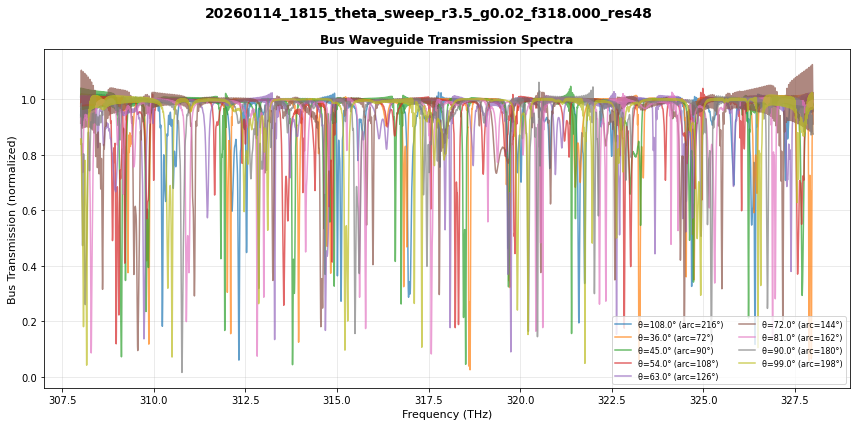

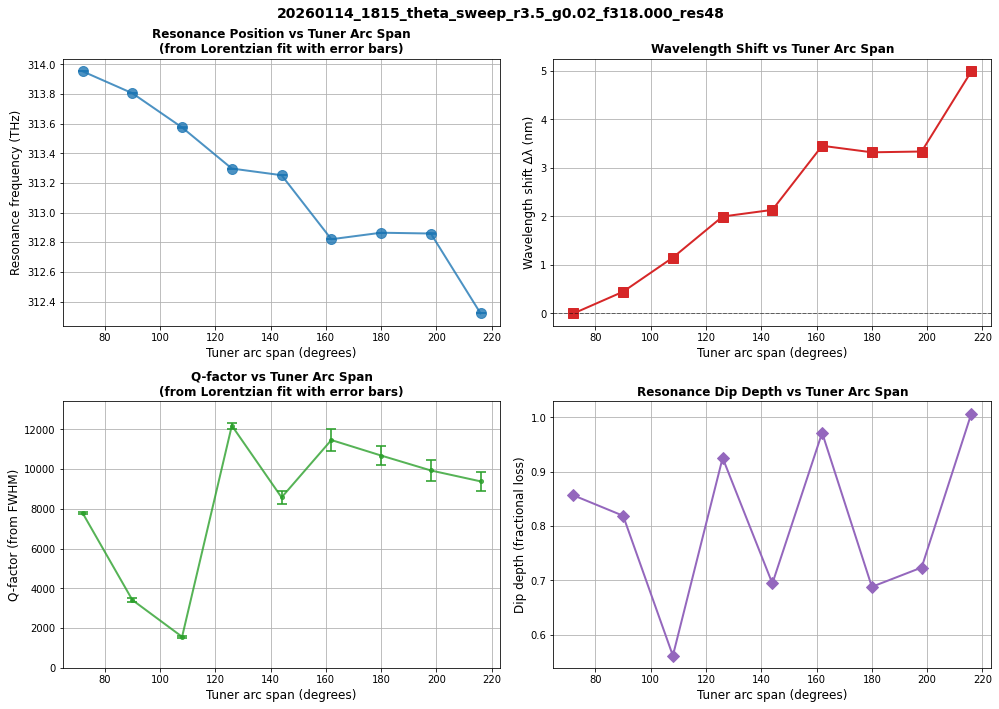


RESONANCE CHARACTERISTICS VS TUNER ARC SPAN (Bus waveguide, Lorentzian fit with uncertainties)
θ (deg)    Arc (deg)    f_res (THz)          λ_shift (nm)   FWHM (GHz)         Q-factor           Dip      R²        
----------------------------------------------------------------------------------------------------------------------------------
36.0       72.0         313.953170 ± 79.4 MHz +0.000         40.287 ± 0.263     7793 ± 51          0.857    0.9945    
45.0       90.0         313.805481 ± 604.4 MHz +0.449         91.920 ± 2.320     3414 ± 86          0.819    0.8944    
54.0       108.0        313.574504 ± 1467.5 MHz +1.153         200.851 ± 7.973    1561 ± 62          0.561    0.7735    
63.0       126.0        313.297309 ± 104.8 MHz +1.999         25.697 ± 0.318     12192 ± 151        0.926    0.9670    
72.0       144.0        313.252369 ± 470.0 MHz +2.136         36.519 ± 1.470     8578 ± 345         0.694    0.7351    
81.0       162.0        312.820501 ± 439.7 MHz +3.458  

In [97]:
def load_bus_theta_sweep(base_folder, fmin, fmax):
    """
    Analyze resonance frequency shift vs tuner arc angle (bus waveguide only).
    
    For a disk with only a bus waveguide, varies the arc angle of the tuner.
    Tracks resonance dips in the bus waveguide transmission.
    
    Folder naming: theta_X.Xdeg (e.g., theta_108.0deg for half-angle in degrees)
    Arc spans from -θ to +θ, so total arc = 2θ.
    
    Metrics:
    - Resonance frequency from Lorentzian fit (inverted for dips)
    - Q-factor = f0 / FWHM from Lorentzian fit
    - Dip depth (transmission loss)
    - Frequency shift relative to reference (no tuner)
    - Wavelength shift in nm
    
    Only includes points with Lorentzian fit R² ≥ 0.9.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    from scipy.signal import find_peaks
    from scipy.optimize import curve_fit

    def lorentzian(f, f0, gamma, A, offset):
        """
        Lorentzian function for fitting resonance peaks.
        f0: center frequency
        gamma: half-width at half-maximum (HWHM)
        A: amplitude (negative for dips)
        offset: baseline offset
        """
        return offset + A * (gamma**2) / ((f - f0)**2 + gamma**2)
    
    def fit_lorentzian_dip(freqs, flux, dip_idx, fit_window=0.3):
        """
        Fit a Lorentzian to a resonance dip (inverted peak).
        
        Returns dict with f0, fwhm, Q, fit_quality, fitted_curve
        """
        f_dip = freqs[dip_idx]
        flux_dip = flux[dip_idx]
        
        # Select data around dip for fitting
        mask = np.abs(freqs - f_dip) < fit_window
        f_fit = freqs[mask]
        flux_fit = flux[mask]
        
        if len(f_fit) < 5:
            return None
        
        # Initial guess (note: A is negative for dips)
        f0_guess = f_dip
        gamma_guess = 0.01  # THz
        A_guess = flux_dip - np.max(flux_fit)  # Negative amplitude
        offset_guess = np.max(flux_fit)  # Baseline at maximum transmission
        
        p0 = [f0_guess, gamma_guess, A_guess, offset_guess]
        
        try:
            # Fit Lorentzian
            popt, pcov = curve_fit(lorentzian, f_fit, flux_fit, p0=p0, maxfev=5000)
            f0_fit, gamma_fit, A_fit, offset_fit = popt
            
            # Calculate FWHM and Q-factor
            fwhm = 2 * abs(gamma_fit)  # FWHM = 2 * HWHM
            Q = abs(f0_fit / fwhm) if fwhm > 0 else np.nan
            
            # Calculate R-squared for fit quality
            flux_fitted = lorentzian(f_fit, *popt)
            ss_res = np.sum((flux_fit - flux_fitted)**2)
            ss_tot = np.sum((flux_fit - np.mean(flux_fit))**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            # Calculate parameter uncertainties from covariance matrix
            perr = np.sqrt(np.diag(pcov))
            f0_err = perr[0]
            gamma_err = perr[1]
            
            # Propagate errors to derived quantities
            fwhm_err = 2 * gamma_err
            
            if fwhm > 0 and f0_fit > 0:
                q_err = Q * np.sqrt((f0_err/f0_fit)**2 + (fwhm_err/fwhm)**2)
            else:
                q_err = np.nan
            
            # Generate full fitted curve for plotting
            fitted_curve = lorentzian(freqs, *popt)
            
            # Dip depth (how much transmission is lost)
            dip_depth = abs(A_fit / offset_fit) if offset_fit != 0 else np.nan
            
            return {
                'f0': f0_fit,
                'f0_err': f0_err,
                'fwhm': fwhm,
                'fwhm_err': fwhm_err,
                'Q': Q,
                'Q_err': q_err,
                'gamma': gamma_fit,
                'amplitude': A_fit,
                'offset': offset_fit,
                'dip_depth': dip_depth,
                'r_squared': r_squared,
                'fitted_curve': fitted_curve,
                'fit_params': popt,
                'fit_errors': perr
            }
        except Exception as e:
            print(f"  Warning: Lorentzian fit failed - {e}")
            return None

    if not os.path.exists(base_folder):
        raise FileNotFoundError(f"Folder '{base_folder}' not found.")

    # Look for theta sweep folders (e.g., "theta_108.0deg", "theta_120.0deg")
    subfolders = sorted([
        f for f in os.listdir(base_folder)
        if os.path.isdir(os.path.join(base_folder, f)) and f.startswith("theta_") and "deg" in f
    ])
    
    if not subfolders:
        raise RuntimeError(f"No theta subfolders found in {base_folder}")

    print(f"Found {len(subfolders)} theta simulations in {base_folder}")

    # Load reference simulation (no tuner)
    ref_folder = os.path.join(base_folder, "ref_notuner")
    ref0_freq = None

    if os.path.exists(ref_folder):
        try:
            ref_freqs = np.load(os.path.join(ref_folder, "freqs_thz.npy"))
            ref_bus = np.load(os.path.join(ref_folder, "flux_bus.npy"))

            # Check for normalization files in reference folder
            ref_norm_flux_path = os.path.join(ref_folder, "norm_flux.npy")
            ref_norm_freqs_path = os.path.join(ref_folder, "norm_freqs.npy")
            if os.path.exists(ref_norm_flux_path) and os.path.exists(ref_norm_freqs_path):
                ref_norm_flux = np.load(ref_norm_flux_path)
                ref_norm_freqs_meep = np.load(ref_norm_freqs_path)
                # Convert normalization frequencies from Meep units to THz
                C0_UM_PER_FS = 299.792458
                ref_norm_freqs = ref_norm_freqs_meep * C0_UM_PER_FS
                # Interpolate and normalize
                ref_norm_flux_interp = np.interp(ref_freqs, ref_norm_freqs, ref_norm_flux)
                ref_bus = ref_bus / ref_norm_flux_interp
                print("Reference data normalized")

            # Find strongest resonance dip in reference
            mask_ref = (ref_freqs >= fmin) & (ref_freqs <= fmax)
            ref_freqs_win = ref_freqs[mask_ref]
            ref_bus_win = ref_bus[mask_ref]

            # Find dips (inverted peaks)
            dips, _ = find_peaks(-np.abs(ref_bus_win), prominence=0.01)

            if len(dips) > 0:
                dip_idx = dips[np.argmin(np.abs(ref_bus_win[dips]))]
                # Fit reference dip with Lorentzian
                fit_ref = fit_lorentzian_dip(ref_freqs_win, np.abs(ref_bus_win), 
                                              dip_idx, fit_window=0.3)
                if fit_ref is not None:
                    ref0_freq = fit_ref['f0']
                    print(f"Reference (ref_notuner) resonance: {ref0_freq:.6f} THz, "
                          f"Q={fit_ref['Q']:.0f}, R²={fit_ref['r_squared']:.4f}")
                else:
                    ref0_freq = ref_freqs_win[dip_idx]
                    print(f"Reference (ref_notuner) resonance: {ref0_freq:.6f} THz (fit failed)")
            else:
                print("Reference sim found but no resonance detected.")
        except Exception as e:
            print(f"Reference simulation error: {e}")
    else:
        print("Reference simulation 'ref_notuner' not found.")

    # Storage for results
    theta_values = []  # Store half-angle in degrees
    arc_span_deg = []  # Store total arc span (2θ) in degrees
    res_frequencies = []
    res_freq_errors = []
    dip_depths = []
    fwhm_values = []
    fwhm_errors = []
    q_factors = []
    q_errors = []
    fit_quality = []
    fit_curves = []

    # Plot 1: Transmission spectra overlay
    fig1, ax1 = plt.subplots(1, 1, figsize=(12, 6))
    fig1.suptitle(f"{os.path.basename(base_folder)}", fontsize=14, fontweight='bold')

    for folder in subfolders:
        folder_path = os.path.join(base_folder, folder)
        try:
            freqs = np.load(os.path.join(folder_path, "freqs_thz.npy"))
            flux_bus = np.load(os.path.join(folder_path, "flux_bus.npy"))
        except FileNotFoundError:
            print(f" Missing data in {folder}, skipping...")
            continue

        # Check for normalization files
        norm_flux_path = os.path.join(folder_path, "norm_flux.npy")
        norm_freqs_path = os.path.join(folder_path, "norm_freqs.npy")
        if os.path.exists(norm_flux_path) and os.path.exists(norm_freqs_path):
            norm_flux = np.load(norm_flux_path)
            norm_freqs = np.load(norm_freqs_path)
            norm_flux_interp = np.interp(freqs, norm_freqs, norm_flux)
            flux_bus = flux_bus / norm_flux_interp

        # Extract theta value (e.g., 'theta_108.0deg' -> θ=108.0°)
        # Arc spans from -θ to +θ, so total arc = 2θ
        try:
            parts = folder.replace("deg", "").split("_")
            theta_half = float(parts[1])  # Half-angle in degrees
            arc_total = 2 * theta_half  # Total arc span
        except Exception as e:
            print(f"Warning: Could not parse theta from {folder}: {e}")
            theta_half = np.nan
            arc_total = np.nan

        # Limit to frequency window
        mask = (freqs >= fmin) & (freqs <= fmax)
        freqs_win = freqs[mask]
        flux_bus_win = flux_bus[mask]

        # Find resonance dips in bus port (inverted peaks)
        dips, properties = find_peaks(-np.abs(flux_bus_win), 
                                      prominence=0.01, 
                                      width=1)
        
        if len(dips) > 0:
            # Pick strongest dip in the frequency window (deepest)
            dip_idx = dips[np.argmin(np.abs(flux_bus_win[dips]))]
            
            dip_depth_raw = 1 - np.abs(flux_bus_win[dip_idx])
            
            # Fit Lorentzian to extract accurate f0, FWHM, and Q
            fit_result = fit_lorentzian_dip(freqs_win, np.abs(flux_bus_win), 
                                           dip_idx, fit_window=0.3)
            
            if fit_result is not None:
                res_freq = fit_result['f0']
                res_freq_err = fit_result['f0_err']
                fwhm = fit_result['fwhm']
                fwhm_err = fit_result['fwhm_err']
                q_factor = fit_result['Q']
                q_err = fit_result['Q_err']
                r_sq = fit_result['r_squared']
                fitted = fit_result['fitted_curve']
                dip_depth = fit_result['dip_depth']
                
                # Store results
                theta_values.append(theta_half)
                arc_span_deg.append(arc_total)
                res_frequencies.append(res_freq)
                res_freq_errors.append(res_freq_err)
                dip_depths.append(dip_depth)
                fwhm_values.append(fwhm)
                fwhm_errors.append(fwhm_err)
                q_factors.append(q_factor)
                q_errors.append(q_err)
                fit_quality.append(r_sq)
                fit_curves.append(fitted)
                
                print(f"{folder}: θ={theta_half:.1f}° (arc={arc_total:.1f}°) | "
                      f"f_res={res_freq:.6f} ± {res_freq_err*1e6:.3f} MHz, "
                      f"FWHM={fwhm*1000:.3f} ± {fwhm_err*1000:.3f} GHz, "
                      f"Q={q_factor:.0f} ± {q_err:.0f}, "
                      f"dip={dip_depth:.3f}, R²={r_sq:.4f}")
            else:
                print(f"{folder}: θ={theta_half:.1f}° | Dip found but fit failed")
                theta_values.append(theta_half)
                arc_span_deg.append(arc_total)
                res_frequencies.append(np.nan)
                res_freq_errors.append(np.nan)
                dip_depths.append(dip_depth_raw)
                fwhm_values.append(np.nan)
                fwhm_errors.append(np.nan)
                q_factors.append(np.nan)
                q_errors.append(np.nan)
                fit_quality.append(np.nan)
                fit_curves.append(None)
        else:
            print(f"{folder}: No resonance found in range [{fmin}, {fmax}] THz")
            theta_values.append(theta_half)
            arc_span_deg.append(arc_total)
            res_frequencies.append(np.nan)
            res_freq_errors.append(np.nan)
            dip_depths.append(np.nan)
            fwhm_values.append(np.nan)
            fwhm_errors.append(np.nan)
            q_factors.append(np.nan)
            q_errors.append(np.nan)
            fit_quality.append(np.nan)
            fit_curves.append(None)

        # Plot spectra
        ax1.plot(freqs, flux_bus, '-', alpha=0.7, linewidth=1.5, 
                label=f"θ={theta_half:.1f}° (arc={arc_total:.0f}°)")

    # Format spectra plot
    ax1.set_xlabel("Frequency (THz)", fontsize=11)
    ax1.set_ylabel("Bus Transmission (normalized)", fontsize=11)
    ax1.set_title("Bus Waveguide Transmission Spectra", fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=8, ncol=2, loc='best')
    
    plt.tight_layout()
    plt.show()

    # Convert to arrays and sort by half-angle
    theta_values = np.array(theta_values)
    arc_span_deg = np.array(arc_span_deg)
    res_frequencies = np.array(res_frequencies)
    res_freq_errors = np.array(res_freq_errors)
    dip_depths = np.array(dip_depths)
    fwhm_values = np.array(fwhm_values)
    fwhm_errors = np.array(fwhm_errors)
    q_factors = np.array(q_factors)
    q_errors = np.array(q_errors)
    fit_quality = np.array(fit_quality)
    
    # Filter out poor fits (R² < 0.9)
    good_fit_mask = fit_quality >= 0.5
    n_filtered = np.sum(~good_fit_mask & ~np.isnan(fit_quality))
    if n_filtered > 0:
        print(f"\n⚠ Warning: Filtered out {n_filtered} points with R² < 0.9")
    
    # Apply mask - set poor fits to NaN
    res_frequencies[~good_fit_mask] = np.nan
    res_freq_errors[~good_fit_mask] = np.nan
    fwhm_values[~good_fit_mask] = np.nan
    fwhm_errors[~good_fit_mask] = np.nan
    q_factors[~good_fit_mask] = np.nan
    q_errors[~good_fit_mask] = np.nan
    
    sort_idx = np.argsort(theta_values)
    theta_values = theta_values[sort_idx]
    arc_span_deg = arc_span_deg[sort_idx]
    res_frequencies = res_frequencies[sort_idx]
    res_freq_errors = res_freq_errors[sort_idx]
    dip_depths = dip_depths[sort_idx]
    fwhm_values = fwhm_values[sort_idx]
    fwhm_errors = fwhm_errors[sort_idx]
    q_factors = q_factors[sort_idx]
    q_errors = q_errors[sort_idx]
    fit_quality = fit_quality[sort_idx]
    fit_curves_sorted = [fit_curves[i] for i in sort_idx]

    # Wavelength shift Δλ (nm)
    c_nm_thz = 299792.458  # speed of light for λ[nm] = c/f[THz]

    valid_mask = ~np.isnan(res_frequencies)

    if np.any(valid_mask):
        wavelength_ref = c_nm_thz / ref0_freq if ref0_freq is not None else c_nm_thz / res_frequencies[valid_mask][0]
        wavelengths_nm = c_nm_thz / res_frequencies[valid_mask]
        lambda_shift_nm = wavelengths_nm - wavelength_ref
    else:
        wavelengths_nm = np.full_like(res_frequencies, np.nan)
        lambda_shift_nm = np.full_like(res_frequencies, np.nan)

    # Create full lambda_shift_nm array (including NaN positions)
    lambda_shift_nm_full = np.full_like(res_frequencies, np.nan)
    lambda_shift_nm_full[valid_mask] = lambda_shift_nm

    # Plot 2: Resonance characteristics vs arc angle
    fig2, ((ax3, ax4), (ax5, ax6)) = plt.subplots(2, 2, figsize=(14, 10))
    fig2.suptitle(f"{os.path.basename(base_folder)}", fontsize=14, fontweight='bold')
    
    # Resonance frequency vs arc span
    valid_freq = ~np.isnan(res_frequencies)
    ax3.errorbar(arc_span_deg[valid_freq], res_frequencies[valid_freq], 
                 yerr=res_freq_errors[valid_freq],
                 fmt='o-', linewidth=2, markersize=10, capsize=5, capthick=2,
                 color='tab:blue', ecolor='tab:blue', alpha=0.8)
    
    if ref0_freq is not None:
        ax3.axhline(ref0_freq, color='black', linestyle='--', linewidth=1.3, alpha=0.8,
                    label=f"Ref no-tuner: {ref0_freq:.6f} THz")
        ax3.legend()

    ax3.set_xlabel("Tuner arc span (degrees)", fontsize=12)
    ax3.set_ylabel("Resonance frequency (THz)", fontsize=12)
    ax3.set_title("Resonance Position vs Tuner Arc Span\n(from Lorentzian fit with error bars)", 
                  fontsize=12, fontweight='bold')
    ax3.grid(True)
    
    # Wavelength shift Δλ (nm)
    ax4.plot(arc_span_deg[valid_mask], lambda_shift_nm, 's-', linewidth=2, markersize=10,
            color='tab:red')
    ax4.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax4.set_xlabel("Tuner arc span (degrees)", fontsize=12)
    ax4.set_ylabel("Wavelength shift Δλ (nm)", fontsize=12)
    ax4.set_title("Wavelength Shift vs Tuner Arc Span", fontsize=12, fontweight='bold')
    ax4.grid(True)
    
    # Q-factor vs arc span
    valid_q = ~np.isnan(q_factors)
    ax5.errorbar(arc_span_deg[valid_q], q_factors[valid_q], 
                 yerr=q_errors[valid_q],
                 fmt='.-', linewidth=2, markersize=8, capsize=5, capthick=2,
                 color='tab:green', ecolor='tab:green', alpha=0.8)
    ax5.set_xlabel("Tuner arc span (degrees)", fontsize=12)
    ax5.set_ylabel("Q-factor (from FWHM)", fontsize=12)
    ax5.set_title("Q-factor vs Tuner Arc Span\n(from Lorentzian fit with error bars)", fontsize=12, fontweight='bold')
    ax5.grid(True)
    if np.any(valid_q):
        ax5.set_ylim([0, np.nanmax(q_factors[valid_q]) * 1.1])
    
    # Dip depth
    valid_dip = ~np.isnan(dip_depths)
    ax6.plot(arc_span_deg[valid_dip], dip_depths[valid_dip], 'D-', 
            linewidth=2, markersize=8, color='tab:purple')
    ax6.set_xlabel("Tuner arc span (degrees)", fontsize=12)
    ax6.set_ylabel("Dip depth (fractional loss)", fontsize=12)
    ax6.set_title("Resonance Dip Depth vs Tuner Arc Span", fontsize=12, fontweight='bold')
    ax6.grid(True)
    
    plt.tight_layout()
    plt.show()

    # Print summary table and save to file
    print("\n" + "="*130)
    print("RESONANCE CHARACTERISTICS VS TUNER ARC SPAN (Bus waveguide, Lorentzian fit with uncertainties)")
    print("="*130)
    print(f"{'θ (deg)':<10} {'Arc (deg)':<12} {'f_res (THz)':<20} {'λ_shift (nm)':<14} "
          f"{'FWHM (GHz)':<18} {'Q-factor':<18} {'Dip':<8} {'R²':<10}")
    print("-"*130)
    
    # Open output file - save as CSV for easy reading
    output_file = os.path.join(base_folder, "theta_sweep_bus_summary.csv")
    with open(output_file, 'w') as f:
        # Write CSV header
        f.write("theta_half_deg,arc_span_deg,f_res_THz,f_res_err_THz,lambda_shift_nm,fwhm_GHz,fwhm_err_GHz,Q_factor,Q_err,dip_depth,R_squared\n")
        
        for i in range(len(theta_values)):
            # Print to console (formatted for humans)
            freq_str = f"{res_frequencies[i]:.6f} ± {res_freq_errors[i]*1e6:.1f} MHz" if not np.isnan(res_frequencies[i]) else "N/A"
            q_str = f"{q_factors[i]:.0f} ± {q_errors[i]:.0f}" if not np.isnan(q_factors[i]) else "N/A"
            shift_str = f"{lambda_shift_nm_full[i]:+.3f}" if not np.isnan(lambda_shift_nm_full[i]) else "N/A"
            fwhm_str = f"{fwhm_values[i]*1000:.3f} ± {fwhm_errors[i]*1000:.3f}" if not np.isnan(fwhm_values[i]) else "N/A"
            dip_str = f"{dip_depths[i]:.3f}" if not np.isnan(dip_depths[i]) else "N/A"
            r2_str = f"{fit_quality[i]:.4f}" if not np.isnan(fit_quality[i]) else "N/A"
            
            line = f"{theta_values[i]:<10.1f} {arc_span_deg[i]:<12.1f} {freq_str:<20} {shift_str:<14} {fwhm_str:<18} {q_str:<18} {dip_str:<8} {r2_str:<10}"
            print(line)
            
            # Write to CSV file (raw numbers for easy reading)
            f.write(f"{theta_values[i]:.2f},{arc_span_deg[i]:.2f},{res_frequencies[i]:.12f},{res_freq_errors[i]:.12f},"
                   f"{lambda_shift_nm_full[i]:.6f},{fwhm_values[i]*1000:.6f},{fwhm_errors[i]*1000:.6f},"
                   f"{q_factors[i]:.2f},{q_errors[i]:.2f},{dip_depths[i]:.6f},{fit_quality[i]:.6f}\n")
        
        # Write summary statistics as comments
        f.write("\n# SUMMARY STATISTICS\n")
        if np.any(valid_mask) and len(res_frequencies[valid_mask]) > 1:
            total_shift_freq = (res_frequencies[valid_mask][-1] - 
                               res_frequencies[valid_mask][0]) * 1000  # GHz
            total_shift_wl = lambda_shift_nm[-1] - lambda_shift_nm[0]  # nm
            arc_range = arc_span_deg[valid_mask][-1] - arc_span_deg[valid_mask][0]
            tuning_rate_freq = total_shift_freq / arc_range if arc_range > 0 else 0
            tuning_rate_wl = total_shift_wl / arc_range if arc_range > 0 else 0
            
            f.write(f"# Total frequency shift: {abs(total_shift_freq):.6f} GHz\n")
            f.write(f"# Total wavelength shift: {abs(total_shift_wl):.6f} nm\n")
            f.write(f"# Arc span range: {arc_range:.2f} degrees\n")
            f.write(f"# Tuning sensitivity (freq): {abs(tuning_rate_freq):.6f} GHz/degree\n")
            f.write(f"# Tuning sensitivity (wavelength): {abs(tuning_rate_wl):.6f} nm/degree\n")
            
            if np.any(valid_q):
                q_mean = np.nanmean(q_factors[valid_q])
                q_std = np.nanstd(q_factors[valid_q])
                q_err_mean = np.nanmean(q_errors[valid_q])
                f.write(f"# Average Q-factor: {q_mean:.2f}\n")
                f.write(f"# Q-factor std dev: {q_std:.2f}\n")
                f.write(f"# Average fit uncertainty: {q_err_mean:.2f}\n")
    
    print(f"\nSummary data saved to: {output_file}")
    
    print("\n" + "="*130)
    print("SUMMARY:")
    if np.any(valid_mask) and len(res_frequencies[valid_mask]) > 1:
        total_shift_freq = (res_frequencies[valid_mask][-1] - 
                           res_frequencies[valid_mask][0]) * 1000  # GHz
        total_shift_wl = lambda_shift_nm[-1] - lambda_shift_nm[0]  # nm
        arc_range = arc_span_deg[valid_mask][-1] - arc_span_deg[valid_mask][0]
        tuning_rate_freq = total_shift_freq / arc_range if arc_range > 0 else 0
        tuning_rate_wl = total_shift_wl / arc_range if arc_range > 0 else 0
        
        print(f"  Total frequency shift: {abs(total_shift_freq):.2f} GHz")
        print(f"  Total wavelength shift: {abs(total_shift_wl):.3f} nm")
        print(f"  Arc span range: {arc_range:.1f} degrees")
        print(f"  Tuning sensitivity: {abs(tuning_rate_freq):.3f} GHz/degree ({abs(tuning_rate_wl):.4f} nm/degree)")
        
        if np.any(valid_q):
            q_mean = np.nanmean(q_factors[valid_q])
            q_std = np.nanstd(q_factors[valid_q])
            q_err_mean = np.nanmean(q_errors[valid_q])
            print(f"  Average Q-factor: {q_mean:.0f} ± {q_std:.0f} (std dev)")
            print(f"  Average fit uncertainty: ±{q_err_mean:.0f}")
    print("="*130)

    return {
        'theta_values': theta_values,
        'arc_span_deg': arc_span_deg,
        'res_frequencies': res_frequencies,
        'res_freq_errors': res_freq_errors,
        'lambda_shift_nm': lambda_shift_nm_full,
        'fwhm_thz': fwhm_values,
        'fwhm_errors': fwhm_errors,
        'q_factors': q_factors,
        'q_errors': q_errors,
        'dip_depths': dip_depths,
        'fit_quality': fit_quality,
        'fit_curves': fit_curves_sorted
    }


# Example usage
if __name__ == "__main__":
    import os
    base_dir = "data"
    base_folder = "20260114_1815_theta_sweep_r3.5_g0.02_f318.000_res48"  # Update with your folder name
    run_dir = os.path.join(base_dir, base_folder)
    
    # Search for resonances in specified range
    results = load_bus_theta_sweep(run_dir, fmin=311.5, fmax=314.0)
    
    # Access results
    print(f"\nHalf-angles tested: {results['theta_values']} degrees")
    print(f"Arc spans tested: {results['arc_span_deg']} degrees")
    print(f"Resonance frequencies: {results['res_frequencies']} THz")
    print(f"Wavelength shifts: {results['lambda_shift_nm']} nm")
    print(f"Q-factors: {results['q_factors']}")

Found 9 theta simulations in data/20260114_1815_theta_sweep_r3.5_g0.02_f318.000_res48
Reference simulation 'ref_notuner' not found.
theta_108.0deg: θ=108.0° (arc=216.0°) | f_res=312.510477 ± 415.410 MHz, FWHM=27.196 ± 1.265 GHz, Q=11491 ± 535, peak_height=8.373, R²=0.6745
theta_36.0deg: θ=36.0° (arc=72.0°) | f_res=313.950842 ± 37.345 MHz, FWHM=37.533 ± 0.122 GHz, Q=8365 ± 27, peak_height=9368.382, R²=0.9986
theta_45.0deg: θ=45.0° (arc=90.0°) | f_res=313.771182 ± 506.591 MHz, FWHM=32.152 ± 1.585 GHz, Q=9759 ± 481, peak_height=8.842, R²=0.6785
theta_54.0deg: θ=54.0° (arc=108.0°) | f_res=313.593210 ± 2317.706 MHz, FWHM=358.080 ± 19.213 GHz, Q=876 ± 47, peak_height=-4.565, R²=0.6851
theta_63.0deg: θ=63.0° (arc=126.0°) | f_res=313.296309 ± 69.762 MHz, FWHM=35.217 ± 0.217 GHz, Q=8896 ± 55, peak_height=-168.143, R²=0.9916
theta_72.0deg: θ=72.0° (arc=144.0°) | f_res=313.271564 ± 508.177 MHz, FWHM=93.969 ± 1.900 GHz, Q=3334 ± 67, peak_height=-32.908, R²=0.9196
theta_81.0deg: θ=81.0° (arc=162.0°

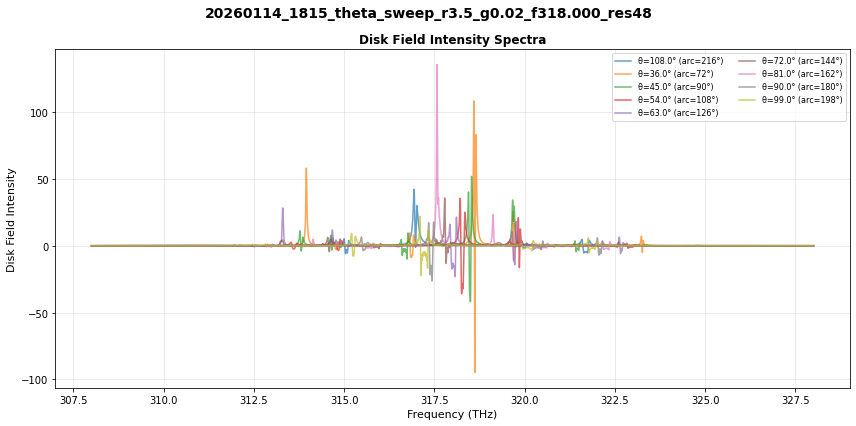

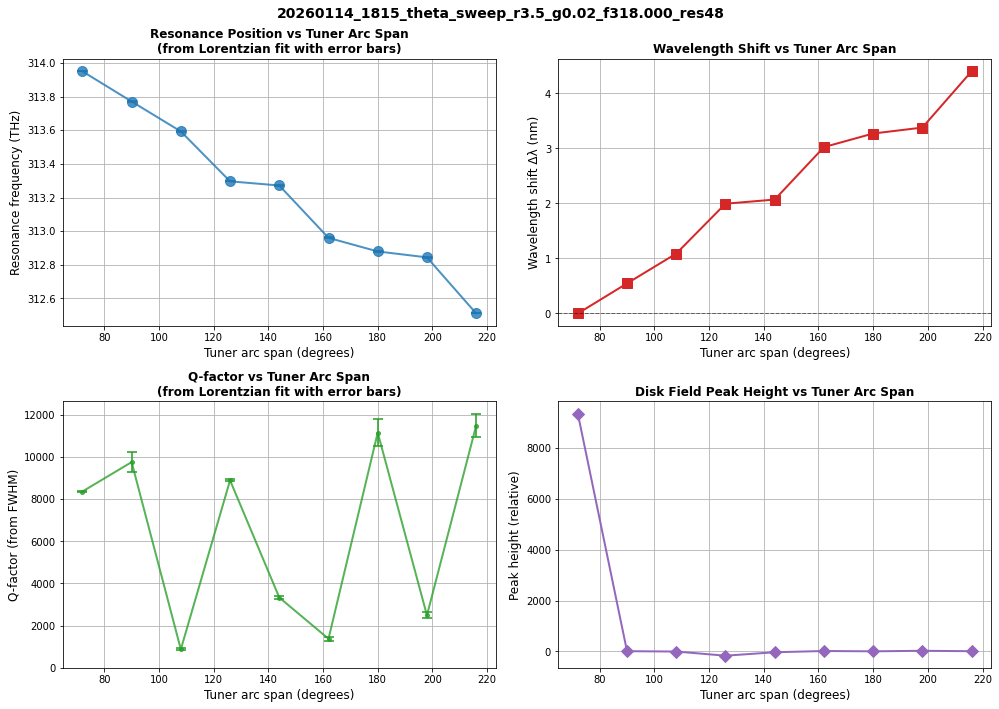


RESONANCE CHARACTERISTICS VS TUNER ARC SPAN (Disk field intensity, Lorentzian fit with uncertainties)
θ (deg)    Arc (deg)    f_res (THz)          λ_shift (nm)   FWHM (GHz)         Q-factor           Peak     R²        
----------------------------------------------------------------------------------------------------------------------------------
36.0       72.0         313.950842 ± 37.3 MHz +0.000         37.533 ± 0.122     8365 ± 27          9368.382 0.9986    
45.0       90.0         313.771182 ± 506.6 MHz +0.547         32.152 ± 1.585     9759 ± 481         8.842    0.6785    
54.0       108.0        313.593210 ± 2317.7 MHz +1.089         358.080 ± 19.213   876 ± 47           -4.565   0.6851    
63.0       126.0        313.296309 ± 69.8 MHz +1.995         35.217 ± 0.217     8896 ± 55          -168.143 0.9916    
72.0       144.0        313.271564 ± 508.2 MHz +2.071         93.969 ± 1.900     3334 ± 67          -32.908  0.9196    
81.0       162.0        312.959935 ± 2493.4 MHz +

In [99]:
def load_disk_theta_sweep(base_folder, fmin, fmax):
    """
    Analyze resonance frequency shift vs tuner arc angle using disk field intensity.
    
    For a disk with bus waveguide, varies the arc angle of the tuner.
    Tracks resonance peaks in the disk field intensity (flux_disk).
    
    Folder naming: theta_X.Xdeg (e.g., theta_108.0deg for half-angle in degrees)
    Arc spans from -θ to +θ, so total arc = 2θ.
    
    Metrics:
    - Resonance frequency from Lorentzian fit (peaks in disk field)
    - Q-factor = f0 / FWHM from Lorentzian fit
    - Peak height (field intensity in disk)
    - Frequency shift relative to reference (no tuner)
    - Wavelength shift in nm
    
    Only includes points with Lorentzian fit R² ≥ 0.9.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    from scipy.signal import find_peaks
    from scipy.optimize import curve_fit

    def lorentzian(f, f0, gamma, A, offset):
        """
        Lorentzian function for fitting resonance peaks.
        f0: center frequency
        gamma: half-width at half-maximum (HWHM)
        A: amplitude (positive for peaks)
        offset: baseline offset
        """
        return offset + A * (gamma**2) / ((f - f0)**2 + gamma**2)
    
    def fit_lorentzian_peak(freqs, flux, peak_idx, fit_window=0.3):
        """
        Fit a Lorentzian to a resonance peak.
        
        Returns dict with f0, fwhm, Q, fit_quality, fitted_curve
        """
        f_peak = freqs[peak_idx]
        flux_peak = flux[peak_idx]
        
        # Select data around peak for fitting
        mask = np.abs(freqs - f_peak) < fit_window
        f_fit = freqs[mask]
        flux_fit = flux[mask]
        
        if len(f_fit) < 5:
            return None
        
        # Initial guess (note: A is positive for peaks)
        f0_guess = f_peak
        gamma_guess = 0.01  # THz
        A_guess = flux_peak - np.min(flux_fit)  # Positive amplitude
        offset_guess = np.min(flux_fit)  # Baseline at minimum
        
        p0 = [f0_guess, gamma_guess, A_guess, offset_guess]
        
        try:
            # Fit Lorentzian
            popt, pcov = curve_fit(lorentzian, f_fit, flux_fit, p0=p0, maxfev=5000)
            f0_fit, gamma_fit, A_fit, offset_fit = popt
            
            # Calculate FWHM and Q-factor
            fwhm = 2 * abs(gamma_fit)  # FWHM = 2 * HWHM
            Q = abs(f0_fit / fwhm) if fwhm > 0 else np.nan
            
            # Calculate R-squared for fit quality
            flux_fitted = lorentzian(f_fit, *popt)
            ss_res = np.sum((flux_fit - flux_fitted)**2)
            ss_tot = np.sum((flux_fit - np.mean(flux_fit))**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            # Calculate parameter uncertainties from covariance matrix
            perr = np.sqrt(np.diag(pcov))
            f0_err = perr[0]
            gamma_err = perr[1]
            
            # Propagate errors to derived quantities
            fwhm_err = 2 * gamma_err
            
            if fwhm > 0 and f0_fit > 0:
                q_err = Q * np.sqrt((f0_err/f0_fit)**2 + (fwhm_err/fwhm)**2)
            else:
                q_err = np.nan
            
            # Generate full fitted curve for plotting
            fitted_curve = lorentzian(freqs, *popt)
            
            # Peak height (relative to baseline)
            peak_height = A_fit / offset_fit if offset_fit != 0 else np.nan
            
            return {
                'f0': f0_fit,
                'f0_err': f0_err,
                'fwhm': fwhm,
                'fwhm_err': fwhm_err,
                'Q': Q,
                'Q_err': q_err,
                'gamma': gamma_fit,
                'amplitude': A_fit,
                'offset': offset_fit,
                'peak_height': peak_height,
                'r_squared': r_squared,
                'fitted_curve': fitted_curve,
                'fit_params': popt,
                'fit_errors': perr
            }
        except Exception as e:
            print(f"  Warning: Lorentzian fit failed - {e}")
            return None

    if not os.path.exists(base_folder):
        raise FileNotFoundError(f"Folder '{base_folder}' not found.")

    # Look for theta sweep folders (e.g., "theta_108.0deg", "theta_120.0deg")
    subfolders = sorted([
        f for f in os.listdir(base_folder)
        if os.path.isdir(os.path.join(base_folder, f)) and f.startswith("theta_") and "deg" in f
    ])
    
    if not subfolders:
        raise RuntimeError(f"No theta subfolders found in {base_folder}")

    print(f"Found {len(subfolders)} theta simulations in {base_folder}")

    # Load reference simulation (no tuner)
    ref_folder = os.path.join(base_folder, "ref_notuner")
    ref0_freq = None

    if os.path.exists(ref_folder):
        try:
            ref_freqs = np.load(os.path.join(ref_folder, "freqs_thz.npy"))
            ref_disk = np.load(os.path.join(ref_folder, "flux_disk.npy"))

            # Find strongest resonance peak in reference
            mask_ref = (ref_freqs >= fmin) & (ref_freqs <= fmax)
            ref_freqs_win = ref_freqs[mask_ref]
            ref_disk_win = ref_disk[mask_ref]

            # Find peaks
            peaks, _ = find_peaks(np.abs(ref_disk_win), prominence=0.01)

            if len(peaks) > 0:
                peak_idx = peaks[np.argmax(np.abs(ref_disk_win[peaks]))]
                # Fit reference peak with Lorentzian
                fit_ref = fit_lorentzian_peak(ref_freqs_win, np.abs(ref_disk_win), 
                                               peak_idx, fit_window=0.3)
                if fit_ref is not None:
                    ref0_freq = fit_ref['f0']
                    print(f"Reference (ref_notuner) resonance: {ref0_freq:.6f} THz, "
                          f"Q={fit_ref['Q']:.0f}, R²={fit_ref['r_squared']:.4f}")
                else:
                    ref0_freq = ref_freqs_win[peak_idx]
                    print(f"Reference (ref_notuner) resonance: {ref0_freq:.6f} THz (fit failed)")
            else:
                print("Reference sim found but no resonance detected.")
        except Exception as e:
            print(f"Reference simulation error: {e}")
    else:
        print("Reference simulation 'ref_notuner' not found.")

    # Storage for results
    theta_values = []  # Store half-angle in degrees
    arc_span_deg = []  # Store total arc span (2θ) in degrees
    res_frequencies = []
    res_freq_errors = []
    peak_heights = []
    fwhm_values = []
    fwhm_errors = []
    q_factors = []
    q_errors = []
    fit_quality = []
    fit_curves = []

    # Plot 1: Disk field intensity spectra overlay
    fig1, ax1 = plt.subplots(1, 1, figsize=(12, 6))
    fig1.suptitle(f"{os.path.basename(base_folder)}", fontsize=14, fontweight='bold')

    for folder in subfolders:
        folder_path = os.path.join(base_folder, folder)
        try:
            freqs = np.load(os.path.join(folder_path, "freqs_thz.npy"))
            flux_disk = np.load(os.path.join(folder_path, "flux_disk.npy"))
        except FileNotFoundError:
            print(f" Missing data in {folder}, skipping...")
            continue

        # Extract theta value (e.g., 'theta_108.0deg' -> θ=108.0°)
        # Arc spans from -θ to +θ, so total arc = 2θ
        try:
            parts = folder.replace("deg", "").split("_")
            theta_half = float(parts[1])  # Half-angle in degrees
            arc_total = 2 * theta_half  # Total arc span
        except Exception as e:
            print(f"Warning: Could not parse theta from {folder}: {e}")
            theta_half = np.nan
            arc_total = np.nan

        # Limit to frequency window
        mask = (freqs >= fmin) & (freqs <= fmax)
        freqs_win = freqs[mask]
        flux_disk_win = flux_disk[mask]

        # Find resonance peaks in disk field intensity
        peaks, properties = find_peaks(np.abs(flux_disk_win), 
                                       prominence=0.01, 
                                       width=1)
        
        if len(peaks) > 0:
            # Pick strongest peak in the frequency window (highest)
            peak_idx = peaks[np.argmax(np.abs(flux_disk_win[peaks]))]
            
            peak_height_raw = np.abs(flux_disk_win[peak_idx])
            
            # Fit Lorentzian to extract accurate f0, FWHM, and Q
            fit_result = fit_lorentzian_peak(freqs_win, np.abs(flux_disk_win), 
                                            peak_idx, fit_window=0.3)
            
            if fit_result is not None:
                res_freq = fit_result['f0']
                res_freq_err = fit_result['f0_err']
                fwhm = fit_result['fwhm']
                fwhm_err = fit_result['fwhm_err']
                q_factor = fit_result['Q']
                q_err = fit_result['Q_err']
                r_sq = fit_result['r_squared']
                fitted = fit_result['fitted_curve']
                peak_height = fit_result['peak_height']
                
                # Store results
                theta_values.append(theta_half)
                arc_span_deg.append(arc_total)
                res_frequencies.append(res_freq)
                res_freq_errors.append(res_freq_err)
                peak_heights.append(peak_height)
                fwhm_values.append(fwhm)
                fwhm_errors.append(fwhm_err)
                q_factors.append(q_factor)
                q_errors.append(q_err)
                fit_quality.append(r_sq)
                fit_curves.append(fitted)
                
                print(f"{folder}: θ={theta_half:.1f}° (arc={arc_total:.1f}°) | "
                      f"f_res={res_freq:.6f} ± {res_freq_err*1e6:.3f} MHz, "
                      f"FWHM={fwhm*1000:.3f} ± {fwhm_err*1000:.3f} GHz, "
                      f"Q={q_factor:.0f} ± {q_err:.0f}, "
                      f"peak_height={peak_height:.3f}, R²={r_sq:.4f}")
            else:
                print(f"{folder}: θ={theta_half:.1f}° | Peak found but fit failed")
                theta_values.append(theta_half)
                arc_span_deg.append(arc_total)
                res_frequencies.append(np.nan)
                res_freq_errors.append(np.nan)
                peak_heights.append(peak_height_raw)
                fwhm_values.append(np.nan)
                fwhm_errors.append(np.nan)
                q_factors.append(np.nan)
                q_errors.append(np.nan)
                fit_quality.append(np.nan)
                fit_curves.append(None)
        else:
            print(f"{folder}: No resonance found in range [{fmin}, {fmax}] THz")
            theta_values.append(theta_half)
            arc_span_deg.append(arc_total)
            res_frequencies.append(np.nan)
            res_freq_errors.append(np.nan)
            peak_heights.append(np.nan)
            fwhm_values.append(np.nan)
            fwhm_errors.append(np.nan)
            q_factors.append(np.nan)
            q_errors.append(np.nan)
            fit_quality.append(np.nan)
            fit_curves.append(None)

        # Plot spectra
        ax1.plot(freqs, flux_disk, '-', alpha=0.7, linewidth=1.5, 
                label=f"θ={theta_half:.1f}° (arc={arc_total:.0f}°)")

    # Format spectra plot
    ax1.set_xlabel("Frequency (THz)", fontsize=11)
    ax1.set_ylabel("Disk Field Intensity", fontsize=11)
    ax1.set_title("Disk Field Intensity Spectra", fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=8, ncol=2, loc='best')
    
    plt.tight_layout()
    plt.show()

    # Convert to arrays and sort by half-angle
    theta_values = np.array(theta_values)
    arc_span_deg = np.array(arc_span_deg)
    res_frequencies = np.array(res_frequencies)
    res_freq_errors = np.array(res_freq_errors)
    peak_heights = np.array(peak_heights)
    fwhm_values = np.array(fwhm_values)
    fwhm_errors = np.array(fwhm_errors)
    q_factors = np.array(q_factors)
    q_errors = np.array(q_errors)
    fit_quality = np.array(fit_quality)
    
    # Filter out poor fits (R² < 0.9)
    good_fit_mask = fit_quality >= 0.5
    n_filtered = np.sum(~good_fit_mask & ~np.isnan(fit_quality))
    if n_filtered > 0:
        print(f"\n⚠ Warning: Filtered out {n_filtered} points with R² < 0.9")
    
    # Apply mask - set poor fits to NaN
    res_frequencies[~good_fit_mask] = np.nan
    res_freq_errors[~good_fit_mask] = np.nan
    fwhm_values[~good_fit_mask] = np.nan
    fwhm_errors[~good_fit_mask] = np.nan
    q_factors[~good_fit_mask] = np.nan
    q_errors[~good_fit_mask] = np.nan
    
    sort_idx = np.argsort(theta_values)
    theta_values = theta_values[sort_idx]
    arc_span_deg = arc_span_deg[sort_idx]
    res_frequencies = res_frequencies[sort_idx]
    res_freq_errors = res_freq_errors[sort_idx]
    peak_heights = peak_heights[sort_idx]
    fwhm_values = fwhm_values[sort_idx]
    fwhm_errors = fwhm_errors[sort_idx]
    q_factors = q_factors[sort_idx]
    q_errors = q_errors[sort_idx]
    fit_quality = fit_quality[sort_idx]
    fit_curves_sorted = [fit_curves[i] for i in sort_idx]

    # Wavelength shift Δλ (nm)
    c_nm_thz = 299792.458  # speed of light for λ[nm] = c/f[THz]

    valid_mask = ~np.isnan(res_frequencies)

    if np.any(valid_mask):
        wavelength_ref = c_nm_thz / ref0_freq if ref0_freq is not None else c_nm_thz / res_frequencies[valid_mask][0]
        wavelengths_nm = c_nm_thz / res_frequencies[valid_mask]
        lambda_shift_nm = wavelengths_nm - wavelength_ref
    else:
        wavelengths_nm = np.full_like(res_frequencies, np.nan)
        lambda_shift_nm = np.full_like(res_frequencies, np.nan)

    # Create full lambda_shift_nm array (including NaN positions)
    lambda_shift_nm_full = np.full_like(res_frequencies, np.nan)
    lambda_shift_nm_full[valid_mask] = lambda_shift_nm

    # Plot 2: Resonance characteristics vs arc angle
    fig2, ((ax3, ax4), (ax5, ax6)) = plt.subplots(2, 2, figsize=(14, 10))
    fig2.suptitle(f"{os.path.basename(base_folder)}", fontsize=14, fontweight='bold')
    
    # Resonance frequency vs arc span
    valid_freq = ~np.isnan(res_frequencies)
    ax3.errorbar(arc_span_deg[valid_freq], res_frequencies[valid_freq], 
                 yerr=res_freq_errors[valid_freq],
                 fmt='o-', linewidth=2, markersize=10, capsize=5, capthick=2,
                 color='tab:blue', ecolor='tab:blue', alpha=0.8)
    
    if ref0_freq is not None:
        ax3.axhline(ref0_freq, color='black', linestyle='--', linewidth=1.3, alpha=0.8,
                    label=f"Ref no-tuner: {ref0_freq:.6f} THz")
        ax3.legend()

    ax3.set_xlabel("Tuner arc span (degrees)", fontsize=12)
    ax3.set_ylabel("Resonance frequency (THz)", fontsize=12)
    ax3.set_title("Resonance Position vs Tuner Arc Span\n(from Lorentzian fit with error bars)", 
                  fontsize=12, fontweight='bold')
    ax3.grid(True)
    
    # Wavelength shift Δλ (nm)
    ax4.plot(arc_span_deg[valid_mask], lambda_shift_nm, 's-', linewidth=2, markersize=10,
            color='tab:red')
    ax4.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax4.set_xlabel("Tuner arc span (degrees)", fontsize=12)
    ax4.set_ylabel("Wavelength shift Δλ (nm)", fontsize=12)
    ax4.set_title("Wavelength Shift vs Tuner Arc Span", fontsize=12, fontweight='bold')
    ax4.grid(True)
    
    # Q-factor vs arc span
    valid_q = ~np.isnan(q_factors)
    ax5.errorbar(arc_span_deg[valid_q], q_factors[valid_q], 
                 yerr=q_errors[valid_q],
                 fmt='.-', linewidth=2, markersize=8, capsize=5, capthick=2,
                 color='tab:green', ecolor='tab:green', alpha=0.8)
    ax5.set_xlabel("Tuner arc span (degrees)", fontsize=12)
    ax5.set_ylabel("Q-factor (from FWHM)", fontsize=12)
    ax5.set_title("Q-factor vs Tuner Arc Span\n(from Lorentzian fit with error bars)", fontsize=12, fontweight='bold')
    ax5.grid(True)
    if np.any(valid_q):
        ax5.set_ylim([0, np.nanmax(q_factors[valid_q]) * 1.1])
    
    # Peak height
    valid_peak = ~np.isnan(peak_heights)
    ax6.plot(arc_span_deg[valid_peak], peak_heights[valid_peak], 'D-', 
            linewidth=2, markersize=8, color='tab:purple')
    ax6.set_xlabel("Tuner arc span (degrees)", fontsize=12)
    ax6.set_ylabel("Peak height (relative)", fontsize=12)
    ax6.set_title("Disk Field Peak Height vs Tuner Arc Span", fontsize=12, fontweight='bold')
    ax6.grid(True)
    
    plt.tight_layout()
    plt.show()

    # Print summary table and save to file
    print("\n" + "="*130)
    print("RESONANCE CHARACTERISTICS VS TUNER ARC SPAN (Disk field intensity, Lorentzian fit with uncertainties)")
    print("="*130)
    print(f"{'θ (deg)':<10} {'Arc (deg)':<12} {'f_res (THz)':<20} {'λ_shift (nm)':<14} "
          f"{'FWHM (GHz)':<18} {'Q-factor':<18} {'Peak':<8} {'R²':<10}")
    print("-"*130)
    
    # Open output file - save as CSV for easy reading
    output_file = os.path.join(base_folder, "theta_sweep_disk_summary.csv")
    with open(output_file, 'w') as f:
        # Write CSV header
        f.write("theta_half_deg,arc_span_deg,f_res_THz,f_res_err_THz,lambda_shift_nm,fwhm_GHz,fwhm_err_GHz,Q_factor,Q_err,peak_height,R_squared\n")
        
        for i in range(len(theta_values)):
            # Print to console (formatted for humans)
            freq_str = f"{res_frequencies[i]:.6f} ± {res_freq_errors[i]*1e6:.1f} MHz" if not np.isnan(res_frequencies[i]) else "N/A"
            q_str = f"{q_factors[i]:.0f} ± {q_errors[i]:.0f}" if not np.isnan(q_factors[i]) else "N/A"
            shift_str = f"{lambda_shift_nm_full[i]:+.3f}" if not np.isnan(lambda_shift_nm_full[i]) else "N/A"
            fwhm_str = f"{fwhm_values[i]*1000:.3f} ± {fwhm_errors[i]*1000:.3f}" if not np.isnan(fwhm_values[i]) else "N/A"
            peak_str = f"{peak_heights[i]:.3f}" if not np.isnan(peak_heights[i]) else "N/A"
            r2_str = f"{fit_quality[i]:.4f}" if not np.isnan(fit_quality[i]) else "N/A"
            
            line = f"{theta_values[i]:<10.1f} {arc_span_deg[i]:<12.1f} {freq_str:<20} {shift_str:<14} {fwhm_str:<18} {q_str:<18} {peak_str:<8} {r2_str:<10}"
            print(line)
            
            # Write to CSV file (raw numbers for easy reading)
            f.write(f"{theta_values[i]:.2f},{arc_span_deg[i]:.2f},{res_frequencies[i]:.12f},{res_freq_errors[i]:.12f},"
                   f"{lambda_shift_nm_full[i]:.6f},{fwhm_values[i]*1000:.6f},{fwhm_errors[i]*1000:.6f},"
                   f"{q_factors[i]:.2f},{q_errors[i]:.2f},{peak_heights[i]:.6f},{fit_quality[i]:.6f}\n")
        
        # Write summary statistics as comments
        f.write("\n# SUMMARY STATISTICS\n")
        if np.any(valid_mask) and len(res_frequencies[valid_mask]) > 1:
            total_shift_freq = (res_frequencies[valid_mask][-1] - 
                               res_frequencies[valid_mask][0]) * 1000  # GHz
            total_shift_wl = lambda_shift_nm[-1] - lambda_shift_nm[0]  # nm
            arc_range = arc_span_deg[valid_mask][-1] - arc_span_deg[valid_mask][0]
            tuning_rate_freq = total_shift_freq / arc_range if arc_range > 0 else 0
            tuning_rate_wl = total_shift_wl / arc_range if arc_range > 0 else 0
            
            f.write(f"# Total frequency shift: {abs(total_shift_freq):.6f} GHz\n")
            f.write(f"# Total wavelength shift: {abs(total_shift_wl):.6f} nm\n")
            f.write(f"# Arc span range: {arc_range:.2f} degrees\n")
            f.write(f"# Tuning sensitivity (freq): {abs(tuning_rate_freq):.6f} GHz/degree\n")
            f.write(f"# Tuning sensitivity (wavelength): {abs(tuning_rate_wl):.6f} nm/degree\n")
            
            if np.any(valid_q):
                q_mean = np.nanmean(q_factors[valid_q])
                q_std = np.nanstd(q_factors[valid_q])
                q_err_mean = np.nanmean(q_errors[valid_q])
                f.write(f"# Average Q-factor: {q_mean:.2f}\n")
                f.write(f"# Q-factor std dev: {q_std:.2f}\n")
                f.write(f"# Average fit uncertainty: {q_err_mean:.2f}\n")
    
    print(f"\nSummary data saved to: {output_file}")
    
    print("\n" + "="*130)
    print("SUMMARY:")
    if np.any(valid_mask) and len(res_frequencies[valid_mask]) > 1:
        total_shift_freq = (res_frequencies[valid_mask][-1] - 
                           res_frequencies[valid_mask][0]) * 1000  # GHz
        total_shift_wl = lambda_shift_nm[-1] - lambda_shift_nm[0]  # nm
        arc_range = arc_span_deg[valid_mask][-1] - arc_span_deg[valid_mask][0]
        tuning_rate_freq = total_shift_freq / arc_range if arc_range > 0 else 0
        tuning_rate_wl = total_shift_wl / arc_range if arc_range > 0 else 0
        
        print(f"  Total frequency shift: {abs(total_shift_freq):.2f} GHz")
        print(f"  Total wavelength shift: {abs(total_shift_wl):.3f} nm")
        print(f"  Arc span range: {arc_range:.1f} degrees")
        print(f"  Tuning sensitivity: {abs(tuning_rate_freq):.3f} GHz/degree ({abs(tuning_rate_wl):.4f} nm/degree)")
        
        if np.any(valid_q):
            q_mean = np.nanmean(q_factors[valid_q])
            q_std = np.nanstd(q_factors[valid_q])
            q_err_mean = np.nanmean(q_errors[valid_q])
            print(f"  Average Q-factor: {q_mean:.0f} ± {q_std:.0f} (std dev)")
            print(f"  Average fit uncertainty: ±{q_err_mean:.0f}")
    print("="*130)

    return {
        'theta_values': theta_values,
        'arc_span_deg': arc_span_deg,
        'res_frequencies': res_frequencies,
        'res_freq_errors': res_freq_errors,
        'lambda_shift_nm': lambda_shift_nm_full,
        'fwhm_thz': fwhm_values,
        'fwhm_errors': fwhm_errors,
        'q_factors': q_factors,
        'q_errors': q_errors,
        'peak_heights': peak_heights,
        'fit_quality': fit_quality,
        'fit_curves': fit_curves_sorted
    }


# Example usage
if __name__ == "__main__":
    import os
    base_dir = "data"
    base_folder = "20260114_1815_theta_sweep_r3.5_g0.02_f318.000_res48"  # Update with your folder name
    run_dir = os.path.join(base_dir, base_folder)
    
    # Search for resonances in specified range
    results = load_disk_theta_sweep(run_dir, fmin=311.5, fmax=314.0)
    
    # Access results
    print(f"\nHalf-angles tested: {results['theta_values']} degrees")
    print(f"Arc spans tested: {results['arc_span_deg']} degrees")
    print(f"Resonance frequencies: {results['res_frequencies']} THz")
    print(f"Wavelength shifts: {results['lambda_shift_nm']} nm")
    print(f"Q-factors: {results['q_factors']}")

# DFT Monitor in Disk

In [112]:
import numpy as np
import os

run_dir = "data/20260115_1226_norm_r3.5_g0.02_f318.000_res48_decay0.001_tw0.08/tunergap_0.005um"

# Check what's actually in the files
freqs = np.load(os.path.join(run_dir, "freqs_thz.npy"))
disk_intensity = np.load(os.path.join(run_dir, "disk_intensity_max.npy"))

print(f"freqs shape: {freqs.shape}")
print(f"freqs: {freqs}")
print(f"\ndisk_intensity shape: {disk_intensity.shape}")
print(f"disk_intensity: {disk_intensity}")
print(f"\nAre they compatible? {len(freqs) if freqs.ndim > 0 else 'freqs is scalar'}")

freqs shape: (30000,)
freqs: [308.         308.00066669 308.00133338 ... 327.99866662 327.99933331
 328.        ]

disk_intensity shape: ()
disk_intensity: 7.529296254247502e-05

Are they compatible? 30000
